In [ ]:
from google.colab import auth
auth.authenticate_user()

print("Авторизація успішна!")

Авторизація успішна!


In [ ]:
from google.cloud import bigquery

project_id = "data-analytics-mate"

client = bigquery.Client(project=project_id)

print("BigQuery підключено!")

BigQuery підключено!


In [ ]:
query = """
SELECT
    table_name
FROM
    `data-analytics-mate.DA.INFORMATION_SCHEMA.TABLES`
ORDER BY
    table_name
"""

tables = client.query(query).to_dataframe(create_bqstorage_client=False)

tables

,table_name
0,ab_test
1,account
2,account_session
3,email_open
4,email_sent
5,email_sent_view
6,email_visit
7,event_params
8,order
9,paid_search_cost


In [ ]:
tables_to_check = [
    "session",
    "session_params",
    "account",
    "account_session",
    "order",
    "product"
]

for table in tables_to_check:
    print(f"\n{'='*60}")
    print(f"TABLE: {table}")
    print(f"{'='*60}")

    query = f"""
    SELECT
        column_name,
        data_type
    FROM
        `data-analytics-mate.DA.INFORMATION_SCHEMA.COLUMNS`
    WHERE
        table_name = '{table}'
    ORDER BY
        ordinal_position
    """

    result = client.query(query).to_dataframe(create_bqstorage_client=False)
    display(result)


TABLE: session


,column_name,data_type
0,date,DATE
1,ga_session_id,INT64



TABLE: session_params


,column_name,data_type
0,ga_session_id,INT64
1,device,STRING
2,mobile_model_name,STRING
3,operating_system,STRING
4,language,STRING
5,browser,STRING
6,continent,STRING
7,country,STRING
8,medium,STRING
9,name,STRING



TABLE: account


...

,column_name,data_type
0,account_id,INT64
1,ga_session_id,INT64



TABLE: order


,column_name,data_type
0,ga_session_id,INT64
1,item_id,INT64



TABLE: product


,column_name,data_type
0,item_id,INT64
1,name,STRING
2,category,STRING
3,price,FLOAT64
4,short_description,STRING


In [ ]:
query = """
SELECT
    s.date AS session_date,
    s.ga_session_id AS session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language AS browser_language,

    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,

    a.id AS registered_user_id,
    a.is_verified AS email_verified,
    a.is_unsubscribed AS newsletter_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description

FROM
    `data-analytics-mate.DA.session` AS s

LEFT JOIN
    `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id

LEFT JOIN
    `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id

LEFT JOIN
    `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id

LEFT JOIN
    `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id

LEFT JOIN
    `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id
"""

df = client.query(query).to_dataframe(
    create_bqstorage_client=False
)

df.head()

,session_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,traffic_channel,registered_user_id,email_verified,newsletter_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
print("Кількість рядків:", len(df))
print("Кількість унікальних сесій:", df["session_id"].nunique())
print("Кількість колонок:", df.shape[1])

Кількість рядків: 349545
Кількість унікальних сесій: 349545
Кількість колонок: 18


In [ ]:
df["session_id"].value_counts().head(10)

,count
session_id,
7058940865,1
5760483956,1
7115337200,1
3978035233,1
9648986282,1
4393441533,1
967742695,1
1115082532,1
6586349543,1


In [ ]:
print("Усього сесій:", df["session_id"].nunique())

print(
    "Сесій із замовленням:",
    df["product_name"].notna().sum()
)

print(
    "Сесій без замовлення:",
    df["product_name"].isna().sum()
)

Усього сесій: 349545
Сесій із замовленням: 33538
Сесій без замовлення: 316007


In [ ]:
df["price"].describe()

,price
count,33538.000000
mean,953.298679
std,1317.001775
min,3.000000
25%,170.000000
50%,445.000000
75%,1195.000000
max,9585.000000


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
newsletter_unsubscribed,321600
email_verified,321600
registered_user_id,321600
short_description,316007
product_name,316007
product_category,316007
price,316007
browser_language,114266
session_id,0
session_date,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   session_date             349545 non-null  dbdate 
 1   session_id               349545 non-null  Int64  
 2   continent                349545 non-null  object 
 3   country                  349545 non-null  object 
 4   device                   349545 non-null  object 
 5   browser                  349545 non-null  object 
 6   mobile_model_name        349545 non-null  object 
 7   operating_system         349545 non-null  object 
 8   browser_language         235279 non-null  object 
 9   traffic_source           349545 non-null  object 
 10  traffic_channel          349545 non-null  object 
 11  registered_user_id       27945 non-null   Int64  
 12  email_verified           27945 non-null   Int64  
 13  newsletter_unsubscribed  27945 non-null   Int64  
 14  prod

In [ ]:
print("Період даних:")
print("від:", df["session_date"].min())
print("до:", df["session_date"].max())

print("\nКількість унікальних значень:")
print(df.nunique().sort_values())

Період даних:
від: 2020-11-01
до: 2021-01-31

Кількість унікальних значень:
email_verified                  2
newsletter_unsubscribed         2
device                          3
traffic_channel                 5
traffic_source                  6
continent                       6
browser                         6
operating_system                6
browser_language                9
mobile_model_name              10
product_category               14
session_date                   92
country                       108
product_name                  550
price                         829
short_description            1476
registered_user_id          27945
session_id                 349545
dtype: int64


In [ ]:
print("Типи даних:")
print(df.dtypes)

Типи даних:
session_date                dbdate
session_id                   Int64
continent                   object
country                     object
device                      object
browser                     object
mobile_model_name           object
operating_system            object
browser_language            object
traffic_source              object
traffic_channel             object
registered_user_id           Int64
email_verified               Int64
newsletter_unsubscribed      Int64
product_category            object
product_name                object
price                      float64
short_description           object
dtype: object


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df["session_date"] = pd.to_datetime(df["session_date"])

In [ ]:
df["session_date"].dtype

dtype('<M8[ns]')

In [ ]:
print("=== DATA QUALITY CHECK ===\n")

print("1. Duplicate rows:", df.duplicated().sum())

print("2. Duplicate session IDs:", df["session_id"].duplicated().sum())

print("3. Registered sessions:",
      df["registered_user_id"].notna().sum())

print("4. Unregistered sessions:",
      df["registered_user_id"].isna().sum())

print("5. Sessions with orders:",
      df["price"].notna().sum())

print("6. Sessions without orders:",
      df["price"].isna().sum())

print("7. Verified registered sessions:",
      df.loc[df["registered_user_id"].notna(), "email_verified"].sum())

print("8. Unsubscribed registered sessions:",
      df.loc[df["registered_user_id"].notna(), "newsletter_unsubscribed"].sum())

=== DATA QUALITY CHECK ===

1. Duplicate rows: 0
2. Duplicate session IDs: 0
3. Registered sessions: 27945
4. Unregistered sessions: 321600
5. Sessions with orders: 33538
6. Sessions without orders: 316007
7. Verified registered sessions: 20036
8. Unsubscribed registered sessions: 4735


In [ ]:
print("email_verified:")
print(df["email_verified"].value_counts(dropna=False))

print("\nnewsletter_unsubscribed:")
print(df["newsletter_unsubscribed"].value_counts(dropna=False))

email_verified:
email_verified
<NA>    321600
1        20036
0         7909
Name: count, dtype: Int64

newsletter_unsubscribed:
newsletter_unsubscribed
<NA>    321600
0        23210
1         4735
Name: count, dtype: Int64


In [ ]:
unique_registered_users = df["registered_user_id"].nunique()

print("Унікальних зареєстрованих користувачів:", unique_registered_users)

Унікальних зареєстрованих користувачів: 27945


In [ ]:
sessions_per_user = (
    df[df["registered_user_id"].notna()]
    .groupby("registered_user_id")["session_id"]
    .nunique()
)

print("Мінімум сесій на користувача:", sessions_per_user.min())
print("Медіана сесій на користувача:", sessions_per_user.median())
print("Середнє сесій на користувача:", sessions_per_user.mean())
print("Максимум сесій на користувача:", sessions_per_user.max())

Мінімум сесій на користувача: 1
Медіана сесій на користувача: 1.0
Середнє сесій на користувача: 1.0
Максимум сесій на користувача: 1


In [ ]:
language_missing_by_device = (
    df.assign(
        language_missing=df["browser_language"].isna()
    )
    .groupby("device")
    .agg(
        sessions=("session_id", "count"),
        missing_language=("language_missing", "sum")
    )
)

language_missing_by_device["missing_pct"] = (
    language_missing_by_device["missing_language"]
    / language_missing_by_device["sessions"]
    * 100
)

language_missing_by_device.sort_values(
    "missing_pct",
    ascending=False
)

,sessions,missing_language,missing_pct
device,,,
tablet,7849,2588,32.972353
mobile,137267,45026,32.801766
desktop,204429,66652,32.603985


In [ ]:
language_missing_by_browser = (
    df.assign(
        language_missing=df["browser_language"].isna()
    )
    .groupby("browser")
    .agg(
        sessions=("session_id", "count"),
        missing_language=("language_missing", "sum")
    )
)

language_missing_by_browser["missing_pct"] = (
    language_missing_by_browser["missing_language"]
    / language_missing_by_browser["sessions"]
    * 100
)

language_missing_by_browser.sort_values(
    "missing_pct",
    ascending=False
)

,sessions,missing_language,missing_pct
browser,,,
Firefox,6433,2172,33.763407
Chrome,238460,78147,32.771534
Safari,83254,27117,32.571408
Edge,8023,2606,32.481615
<Other>,8930,2857,31.993281
Android Webview,4445,1367,30.753656


In [ ]:
# Загальна інформація про датасет

numeric_columns = [
    "session_id",
    "registered_user_id",
    "email_verified",
    "newsletter_unsubscribed",
    "price"
]

categorical_columns = [
    "continent",
    "country",
    "device",
    "browser",
    "mobile_model_name",
    "operating_system",
    "browser_language",
    "traffic_source",
    "traffic_channel",
    "product_category",
    "product_name",
    "short_description"
]

datetime_columns = [
    "session_date"
]

# Основні характеристики
total_rows = len(df)
total_columns = df.shape[1]
unique_sessions = df["session_id"].nunique()

start_date = df["session_date"].min()
end_date = df["session_date"].max()
days_count = df["session_date"].nunique()

# Зареєстровані користувачі
registered_users = df["registered_user_id"].nunique()
registered_sessions = df["registered_user_id"].notna().sum()
unregistered_sessions = df["registered_user_id"].isna().sum()

# Замовлення
sessions_with_orders = df["price"].notna().sum()
sessions_without_orders = df["price"].isna().sum()

conversion_rate = sessions_with_orders / total_rows * 100

# Email / newsletter
verified_users = (
    df.loc[df["registered_user_id"].notna(), "email_verified"]
    .eq(1)
    .sum()
)

unsubscribed_users = (
    df.loc[df["registered_user_id"].notna(), "newsletter_unsubscribed"]
    .eq(1)
    .sum()
)

verified_share = verified_users / registered_users * 100
unsubscribed_share = unsubscribed_users / registered_users * 100

# Пропущені значення
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"] / total_rows * 100
)

missing = missing[missing["missing_count"] > 0] \
    .sort_values("missing_count", ascending=False)

# Перевірка якості
duplicate_rows = df.duplicated().sum()
duplicate_sessions = df["session_id"].duplicated().sum()

# Виведення результатів
print("=== DATASET OVERVIEW ===")
print(f"Кількість рядків: {total_rows:,}")
print(f"Кількість колонок: {total_columns}")
print(f"Числових колонок: {len(numeric_columns)}")
print(f"Категоріальних колонок: {len(categorical_columns)}")
print(f"Datetime колонок: {len(datetime_columns)}")

print("\nЧислові колонки:")
print(", ".join(numeric_columns))

print("\nКатегоріальні колонки:")
print(", ".join(categorical_columns))

print("\nDatetime колонки:")
print(", ".join(datetime_columns))

print("\n=== TIME PERIOD ===")
print(f"Період: {start_date.date()} — {end_date.date()}")
print(f"Кількість календарних днів: {days_count}")

print("\n=== SESSIONS & USERS ===")
print(f"Унікальних сесій: {unique_sessions:,}")
print(f"Зареєстрованих користувачів: {registered_users:,}")
print(f"Зареєстрованих сесій: {registered_sessions:,} ({registered_sessions / total_rows * 100:.2f}%)")
print(f"Незареєстрованих сесій: {unregistered_sessions:,} ({unregistered_sessions / total_rows * 100:.2f}%)")

print("\n=== ORDERS ===")
print(f"Сесій із замовленням: {sessions_with_orders:,}")
print(f"Сесій без замовлення: {sessions_without_orders:,}")
print(f"Session-to-order conversion: {conversion_rate:.2f}%")

print("\n=== REGISTERED USERS ===")
print(f"Підтвердили email: {verified_users:,} ({verified_share:.2f}%)")
print(f"Відписалися від розсилки: {unsubscribed_users:,} ({unsubscribed_share:.2f}%)")

print("\n=== DATA QUALITY ===")
print(f"Дублікати рядків: {duplicate_rows}")
print(f"Дублікати session_id: {duplicate_sessions}")

print("\nПропущені значення:")
display(missing)

=== DATASET OVERVIEW ===
Кількість рядків: 349,545
Кількість колонок: 18
Числових колонок: 5
Категоріальних колонок: 12
Datetime колонок: 1

Числові колонки:
session_id, registered_user_id, email_verified, newsletter_unsubscribed, price

Категоріальні колонки:
continent, country, device, browser, mobile_model_name, operating_system, browser_language, traffic_source, traffic_channel, product_category, product_name, short_description

Datetime колонки:
session_date

=== TIME PERIOD ===
Період: 2020-11-01 — 2021-01-31
Кількість календарних днів: 92

=== SESSIONS & USERS ===
Унікальних сесій: 349,545
Зареєстрованих користувачів: 27,945
Зареєстрованих сесій: 27,945 (7.99%)
Незареєстрованих сесій: 321,600 (92.01%)

=== ORDERS ===
Сесій із замовленням: 33,538
Сесій без замовлення: 316,007
Session-to-order conversion: 9.59%

=== REGISTERED USERS ===
Підтвердили email: 20,036 (71.70%)
Відписалися від розсилки: 4,735 (16.94%)

=== DATA QUALITY ===
Дублікати рядків: 0
Дублікати session_id: 0

Про

,missing_count,missing_pct
registered_user_id,321600,92.005321
email_verified,321600,92.005321
newsletter_unsubscribed,321600,92.005321
product_category,316007,90.405241
price,316007,90.405241
product_name,316007,90.405241
short_description,316007,90.405241
browser_language,114266,32.689925


### Висновок

Отриманий датасет містить 349 545 сесій та 18 колонок і охоплює період з 1 листопада 2020 року до 31 січня 2021 року. Дані представлені на рівні однієї сесії: кожному `session_id` відповідає один рядок, при цьому дублікатів рядків та ідентифікаторів сесій не виявлено.

У датасеті представлено 5 технічно числових, 12 категоріальних та 1 datetime-змінну. `email_verified` і `newsletter_unsubscribed`, хоча зберігаються як числові значення 0/1, аналітично є бінарними категоріальними ознаками.

Переважна більшість сесій (92.01%) належить незареєстрованим користувачам. Усього в датасеті представлено 27 945 унікальних зареєстрованих користувачів, і кожен із них має одну сесію. 33 538 сесій завершилися замовленням, що відповідає session-to-order conversion **9.59%**.

Серед зареєстрованих користувачів 71.70% підтвердили email, а 16.94% відписалися від розсилки.

Пропущені значення переважно мають логічне пояснення. Дані про зареєстрованого користувача, підтвердження email та підписку на розсилку відсутні для незареєстрованих сесій. Дані про товар і ціну відсутні для сесій, у яких не було замовлення. Окремим data quality issue є `browser_language`: 114 266 значень (32.69%) є пропущеними. Перевірка за типом пристрою та браузером не виявила очевидної залежності частки пропусків від цих характеристик, тому їх конкретну причину на основі доступних даних встановити неможливо.

Таким чином, датасет пройшов базову перевірку якості та є придатним для подальшого дослідження продажів, поведінки користувачів, каналів залучення та статистичних взаємозв'язків.


In [ ]:
# ============================================================
# КРОК 1.1 — Перевірка структури замовлень і метрики продажів
# ============================================================

orders_check_query = """
SELECT
    COUNT(*) AS total_order_rows,
    COUNT(DISTINCT ga_session_id) AS unique_order_sessions,
    COUNT(DISTINCT item_id) AS unique_products
FROM
    `data-analytics-mate.DA.order`
"""

orders_check = client.query(orders_check_query).to_dataframe(
    create_bqstorage_client=False
)

print("=== ORDER TABLE ===")
display(orders_check)


# ------------------------------------------------------------
# Перевіряємо, чи може одна сесія мати декілька order records
# ------------------------------------------------------------

multiple_orders_query = """
SELECT
    ga_session_id,
    COUNT(*) AS order_count
FROM
    `data-analytics-mate.DA.order`
GROUP BY
    ga_session_id
HAVING
    COUNT(*) > 1
ORDER BY
    order_count DESC
"""

multiple_orders = client.query(multiple_orders_query).to_dataframe(
    create_bqstorage_client=False
)

print("\n=== SESSIONS WITH MULTIPLE ORDERS ===")
print(f"Кількість сесій із >1 order record: {len(multiple_orders):,}")

if len(multiple_orders) > 0:
    display(multiple_orders.head(10))
else:
    print("Сесій із декількома order records не знайдено.")


# ------------------------------------------------------------
# Порівнюємо кількість замовлень із кількістю сесій
# ------------------------------------------------------------

print("\n=== COMPARISON ===")

total_orders = orders_check.loc[0, "total_order_rows"]
unique_order_sessions = orders_check.loc[0, "unique_order_sessions"]

print(f"Усього order records: {total_orders:,}")
print(f"Унікальних сесій із замовленням: {unique_order_sessions:,}")
print(f"Різниця: {total_orders - unique_order_sessions:,}")

=== ORDER TABLE ===


,total_order_rows,unique_order_sessions,unique_products
0,33538,33538,2528



=== SESSIONS WITH MULTIPLE ORDERS ===
Кількість сесій із >1 order record: 0
Сесій із декількома order records не знайдено.

=== COMPARISON ===
Усього order records: 33,538
Унікальних сесій із замовленням: 33,538
Різниця: 0


Основним ринком магазину є Americas, який формує 55.25% усієї виручки та має найбільшу кількість замовлень — 18 553. Asia забезпечує 23.78% виручки, а Europe — 18.56%. При цьому revenue per order між трьома основними континентами дуже близький і становить приблизно 948–956, тому перевага Americas за виручкою пояснюється насамперед більшою кількістю замовлень, а не суттєво вищою середньою вартістю замовлення.

=== TOP-3 CONTINENTS BY REVENUE ===


,continent,revenue,orders,revenue_share,revenue_per_order
0,Americas,"17,665,280.00","18,553",55.25%,952.15
1,Asia,"7,601,298.30","7,950",23.78%,956.14
2,Europe,"5,934,624.20","6,261",18.56%,947.87


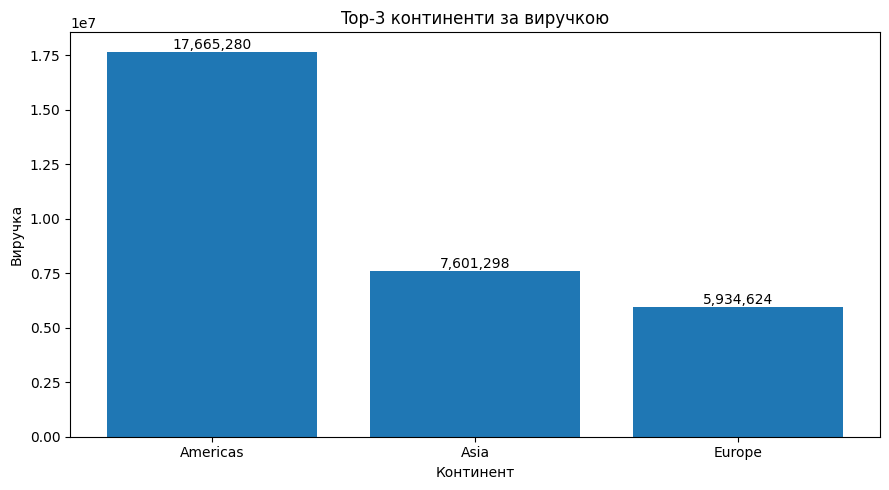


=== TOP-5 COUNTRIES BY REVENUE ===


,country,revenue,orders,revenue_share,revenue_per_order
0,United States,"13,943,553.90","14,673",43.61%,950.29
1,India,"2,809,762.00","3,029",8.79%,927.62
2,Canada,"2,437,921.00","2,560",7.63%,952.31
3,United Kingdom,"938,317.90","1,029",2.93%,911.87
4,France,"710,692.80",678,2.22%,"1,048.22"


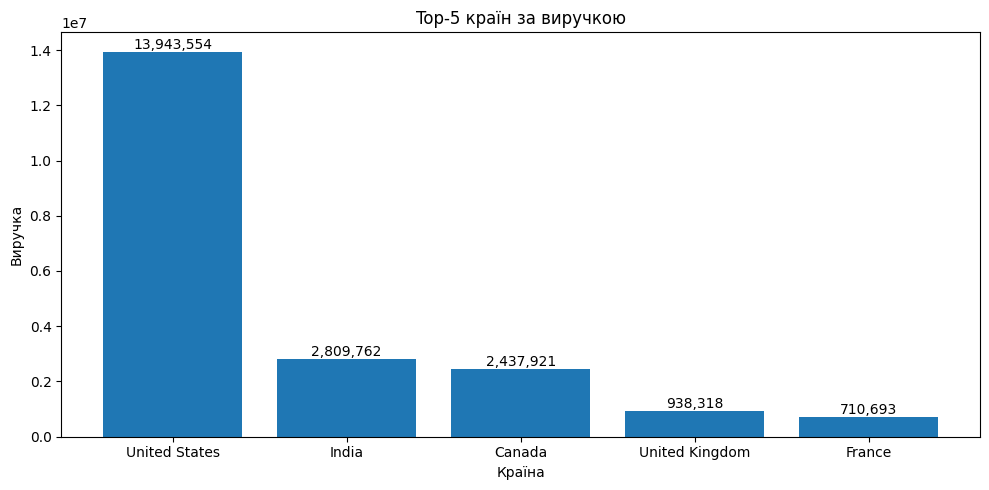

In [ ]:
# ============================================================
# КРОК 1.2 — Аналіз продажів за континентами та країнами
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. ПІДГОТОВКА ДАНИХ
# ------------------------------------------------------------

# Залишаємо тільки сесії, у яких було замовлення
sales_df = df[df["price"].notna()].copy()


# ------------------------------------------------------------
# 1. TOP-3 КОНТИНЕНТИ ЗА REVENUE
# ------------------------------------------------------------

continent_sales = (
    sales_df
    .groupby("continent")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

# Частка континенту в загальній виручці
continent_sales["revenue_share"] = (
    continent_sales["revenue"]
    / continent_sales["revenue"].sum()
    * 100
)

# Середня виручка на одне замовлення
continent_sales["revenue_per_order"] = (
    continent_sales["revenue"]
    / continent_sales["orders"]
)

# TOP-3 континенти
top_3_continents = (
    continent_sales
    .sort_values("revenue", ascending=False)
    .head(3)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. TOP-5 КРАЇН ЗА REVENUE
# ------------------------------------------------------------

country_sales = (
    sales_df
    .groupby("country")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

# Частка країни в загальній виручці
country_sales["revenue_share"] = (
    country_sales["revenue"]
    / country_sales["revenue"].sum()
    * 100
)

# Середня виручка на одне замовлення
country_sales["revenue_per_order"] = (
    country_sales["revenue"]
    / country_sales["orders"]
)

# TOP-5 країн
top_5_countries = (
    country_sales
    .sort_values("revenue", ascending=False)
    .head(5)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. ВИВЕДЕННЯ TOP-3 КОНТИНЕНТІВ
# ------------------------------------------------------------

print("=== TOP-3 CONTINENTS BY REVENUE ===")

display(
    top_3_continents.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 4. ВІЗУАЛІЗАЦІЯ TOP-3 КОНТИНЕНТІВ
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    top_3_continents["continent"],
    top_3_continents["revenue"]
)

plt.title("Top-3 континенти за виручкою")
plt.xlabel("Континент")
plt.ylabel("Виручка")

# Значення над стовпцями
for bar, value in zip(
    bars,
    top_3_continents["revenue"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. ВИВЕДЕННЯ TOP-5 КРАЇН
# ------------------------------------------------------------

print("\n=== TOP-5 COUNTRIES BY REVENUE ===")

display(
    top_5_countries.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 6. ВІЗУАЛІЗАЦІЯ TOP-5 КРАЇН
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_5_countries["country"],
    top_5_countries["revenue"]
)

plt.title("Top-5 країн за виручкою")
plt.xlabel("Країна")
plt.ylabel("Виручка")

# Значення над стовпцями
for bar, value in zip(
    bars,
    top_5_countries["revenue"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Найбільшим ринком магазину є United States, який генерує 43.61% усієї виручки та 14 673 замовлення. Наступні позиції займають India — 8.79%, Canada — 7.63%, UK — 2.93% та France — 2.22%. При цьому revenue per order між TOP-5 країн відрізняється помірно: від 911.87 у UK до 1 048.22 у France. Отже, основна перевага США пов'язана передусім із масштабом продажів, а не з істотно вищою середньою вартістю замовлення.

=== TOP-10 PRODUCT CATEGORIES BY REVENUE ===


,product_category,revenue,orders,revenue_share,revenue_per_order
0,Sofas & armchairs,"8,388,254.50","4,301",26.24%,"1,950.30"
1,Chairs,"6,147,748.80","5,952",19.23%,"1,032.89"
2,Beds,"4,919,725.00","2,926",15.39%,"1,681.38"
3,Bookcases & shelving units,"3,640,818.10","7,630",11.39%,477.17
4,Cabinets & cupboards,"2,336,499.50","2,318",7.31%,"1,007.98"
5,Outdoor furniture,"2,142,222.20","2,229",6.70%,961.07
6,Tables & desks,"1,790,307.50","2,941",5.60%,608.74
7,Chests of drawers & drawer units,"906,562.50","1,452",2.84%,624.35
8,Bar furniture,"735,503.00","1,092",2.30%,673.54
9,Children's furniture,"467,697.00","1,702",1.46%,274.79



TOP-10 категорій формують 98.45% загальної виручки.


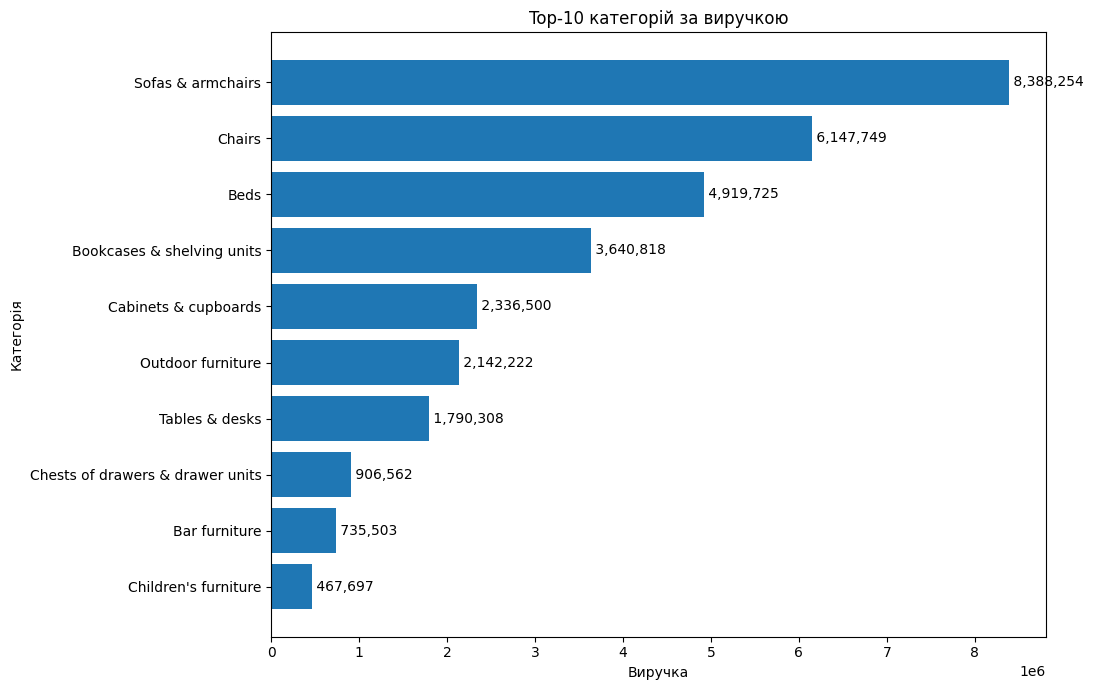

In [ ]:
# ============================================================
# КРОК 1.3 — TOP-10 категорій за виручкою
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. РОЗРАХУНОК ПРОДАЖІВ ЗА КАТЕГОРІЯМИ
# ------------------------------------------------------------

category_sales = (
    sales_df
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

# Частка кожної категорії у загальній виручці
total_revenue = category_sales["revenue"].sum()

category_sales["revenue_share"] = (
    category_sales["revenue"]
    / total_revenue
    * 100
)

# Середня виручка з одного замовлення
category_sales["revenue_per_order"] = (
    category_sales["revenue"]
    / category_sales["orders"]
)

# ------------------------------------------------------------
# 2. TOP-10 КАТЕГОРІЙ
# ------------------------------------------------------------

top_10_categories = (
    category_sales
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. ТАБЛИЦЯ TOP-10
# ------------------------------------------------------------

print("=== TOP-10 PRODUCT CATEGORIES BY REVENUE ===")

display(
    top_10_categories.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# 4. КОНЦЕНТРАЦІЯ ВИРУЧКИ
# ------------------------------------------------------------

top_10_revenue_share = top_10_categories["revenue_share"].sum()

print(
    f"\nTOP-10 категорій формують "
    f"{top_10_revenue_share:.2f}% загальної виручки."
)

# ------------------------------------------------------------
# 5. ВІЗУАЛІЗАЦІЯ — TOP-10 КАТЕГОРІЙ ЗА REVENUE
# ------------------------------------------------------------

# Розвертаємо порядок для горизонтального графіка:
# найбільша категорія буде зверху
plot_data = top_10_categories.sort_values(
    "revenue",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["product_category"],
    plot_data["revenue"]
)

plt.title("Top-10 категорій за виручкою")
plt.xlabel("Виручка")
plt.ylabel("Категорія")

# Значення виручки біля кожного стовпця
for bar, value in zip(
    bars,
    plot_data["revenue"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Продажі магазину мають високу концентрацію за категоріями: TOP-3 категорії — Sofas & armchairs, Chairs та Beds — формують 60.86% усієї виручки, а TOP-10 — 98.45%. Найбільший внесок має Sofas & armchairs — 26.24% виручки та revenue per order 1 950.30. Водночас Bookcases & shelving units мають найбільшу кількість замовлень — 7 630, але формують лише 11.39% виручки. Це демонструє, що популярність категорії за кількістю замовлень не обов'язково означає найбільший фінансовий внесок.

=== TOP-10 PRODUCT CATEGORIES IN THE UNITED STATES ===


,product_category,revenue,orders,us_revenue_share,revenue_per_order,global_revenue_share,share_difference_pp
0,Sofas & armchairs,"3,707,144.50","1,903",26.59%,"1,948.05",26.24%,+0.35
1,Chairs,"2,619,773.80","2,576",18.79%,"1,016.99",19.23%,-0.44
2,Beds,"2,213,058.00","1,298",15.87%,"1,704.98",15.39%,+0.48
3,Bookcases & shelving units,"1,567,606.90","3,374",11.24%,464.61,11.39%,-0.15
4,Cabinets & cupboards,"994,545.50",995,7.13%,999.54,7.31%,-0.18
5,Outdoor furniture,"929,245.20",984,6.66%,944.35,6.70%,-0.04
6,Tables & desks,"777,865.00","1,248",5.58%,623.29,5.60%,-0.02
7,Chests of drawers & drawer units,"382,388.00",616,2.74%,620.76,2.84%,-0.09
8,Bar furniture,"330,805.00",487,2.37%,679.27,2.30%,+0.07
9,Children's furniture,"207,575.00",752,1.49%,276.03,1.46%,+0.03



=== TOP-10 REVENUE SHARE IN THE UNITED STATES ===
TOP-10 категорій формують 98.47% виручки США.


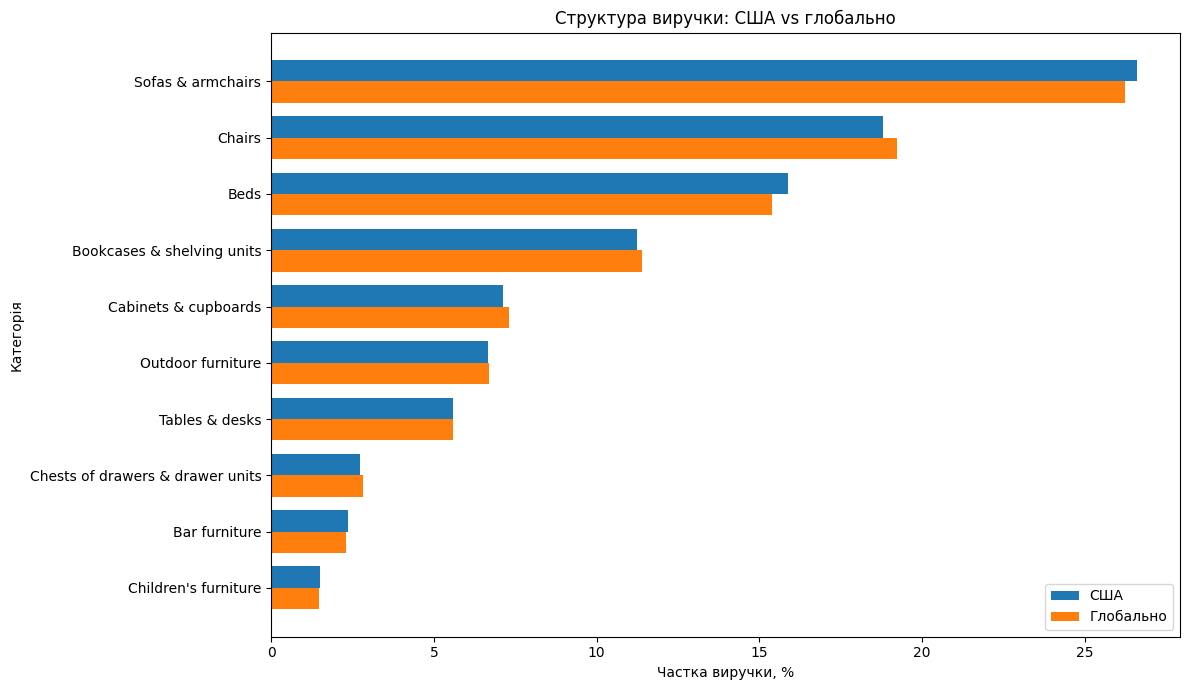

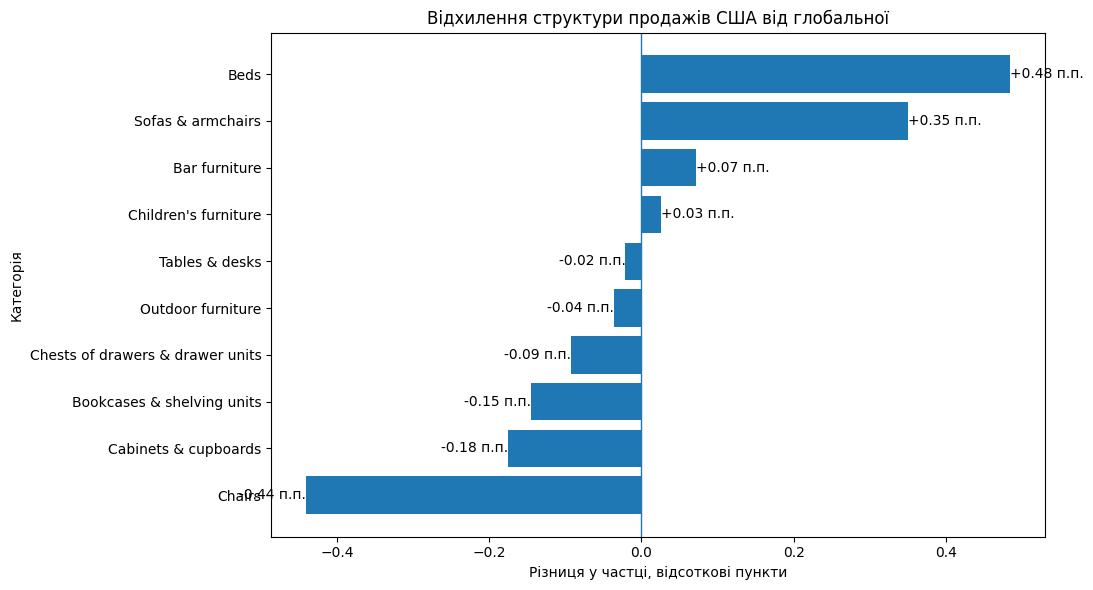

In [ ]:
# ============================================================
# КРОК 1.4 — TOP-10 категорій у країні-лідері: США
# Порівняння з глобальною структурою продажів
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. ПРОДАЖІ КАТЕГОРІЙ У США
# ------------------------------------------------------------

us_category_sales = (
    sales_df[sales_df["country"] == "United States"]
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

us_total_revenue = us_category_sales["revenue"].sum()

us_category_sales["us_revenue_share"] = (
    us_category_sales["revenue"]
    / us_total_revenue
    * 100
)

us_category_sales["revenue_per_order"] = (
    us_category_sales["revenue"]
    / us_category_sales["orders"]
)


# ------------------------------------------------------------
# 2. ГЛОБАЛЬНА ЧАСТКА КАТЕГОРІЙ
# ------------------------------------------------------------

global_category_share = (
    category_sales[
        ["product_category", "revenue_share"]
    ]
    .rename(columns={
        "revenue_share": "global_revenue_share"
    })
)


# ------------------------------------------------------------
# 3. ПОРІВНЯННЯ США ТА ГЛОБАЛЬНИХ ПРОДАЖІВ
# ------------------------------------------------------------

us_category_analysis = (
    us_category_sales
    .merge(
        global_category_share,
        on="product_category",
        how="left"
    )
)

# Різниця у відсоткових пунктах
us_category_analysis["share_difference_pp"] = (
    us_category_analysis["us_revenue_share"]
    - us_category_analysis["global_revenue_share"]
)


# ------------------------------------------------------------
# 4. TOP-10 КАТЕГОРІЙ США
# ------------------------------------------------------------

top_10_us_categories = (
    us_category_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. ТАБЛИЦЯ
# ------------------------------------------------------------

print("=== TOP-10 PRODUCT CATEGORIES IN THE UNITED STATES ===")

display(
    top_10_us_categories.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "us_revenue_share": "{:.2f}%",
        "global_revenue_share": "{:.2f}%",
        "share_difference_pp": "{:+.2f}",
        "revenue_per_order": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 6. КОНЦЕНТРАЦІЯ ВИРУЧКИ США
# ------------------------------------------------------------

top_10_us_revenue_share = (
    top_10_us_categories["us_revenue_share"].sum()
)

print(
    "\n=== TOP-10 REVENUE SHARE IN THE UNITED STATES ==="
)

print(
    f"TOP-10 категорій формують "
    f"{top_10_us_revenue_share:.2f}% "
    f"виручки США."
)


# ------------------------------------------------------------
# 7. ВІЗУАЛІЗАЦІЯ —
#    ЧАСТКА КАТЕГОРІЙ США VS GLOBAL
# ------------------------------------------------------------

plot_data = top_10_us_categories.sort_values(
    "us_revenue_share",
    ascending=True
)

y = np.arange(len(plot_data))
height = 0.38

plt.figure(figsize=(12, 7))

plt.barh(
    y + height / 2,
    plot_data["us_revenue_share"],
    height,
    label="США"
)

plt.barh(
    y - height / 2,
    plot_data["global_revenue_share"],
    height,
    label="Глобально"
)

plt.yticks(
    y,
    plot_data["product_category"]
)

plt.xlabel("Частка виручки, %")
plt.ylabel("Категорія")

plt.title(
    "Структура виручки: США vs глобально"
)

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. ВІЗУАЛІЗАЦІЯ —
#    ВІДХИЛЕННЯ ЧАСТКИ США ВІД ГЛОБАЛЬНОЇ
# ------------------------------------------------------------

difference_data = top_10_us_categories.sort_values(
    "share_difference_pp"
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    difference_data["product_category"],
    difference_data["share_difference_pp"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Різниця у частці, відсоткові пункти")
plt.ylabel("Категорія")

plt.title(
    "Відхилення структури продажів США від глобальної"
)

for bar, value in zip(
    bars,
    difference_data["share_difference_pp"]
):
    if value >= 0:
        x_position = value
        ha = "left"
    else:
        x_position = value
        ha = "right"

    plt.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.2f} п.п.",
        va="center",
        ha=ha
    )

plt.tight_layout()
plt.show()

Структура продажів у United States майже повністю відповідає загальній структурі магазину: найбільше відхилення частки окремої категорії становить лише 0.48 п.п. Це свідчить про те, що США не мають принципово іншої категоріальної структури попиту порівняно з глобальним показником. Тому поточну категоріальну стратегію магазину можна вважати достатньо універсальною для його основного ринку.

=== SALES BY TRAFFIC SOURCE ===


,traffic_source,revenue,orders,revenue_share,revenue_per_order
0,organic,"10,935,239.90","11,430",34.20%,956.71
1,(none),"7,494,923.40","7,800",23.44%,960.89
2,referral,"5,641,855.20","6,001",17.65%,940.15
3,,"4,491,351.10","4,803",14.05%,935.11
4,(data deleted),"2,041,921.00","2,097",6.39%,973.73
5,cpc,"1,366,440.50","1,407",4.27%,971.17


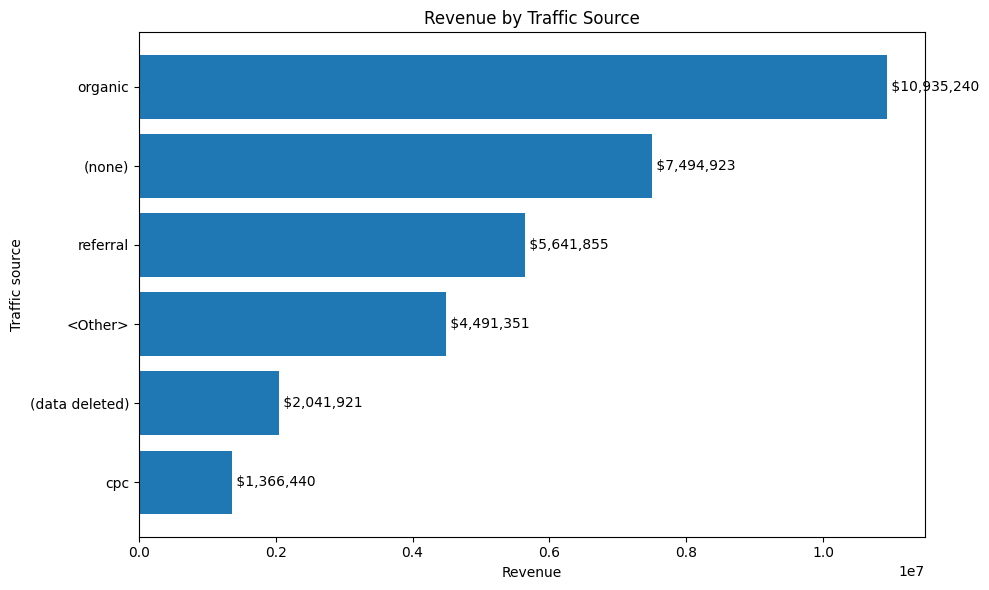

In [ ]:
# ============================================================
# КРОК 1.5 — Продажі за джерелами трафіку
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Розрахунок продажів за джерелом трафіку
# ------------------------------------------------------------

traffic_sales = (
    sales_df
    .groupby("traffic_source")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

# Частка джерела в загальній виручці
traffic_sales["revenue_share"] = (
    traffic_sales["revenue"]
    / traffic_sales["revenue"].sum()
    * 100
)

# Середня виручка з одного замовлення
traffic_sales["revenue_per_order"] = (
    traffic_sales["revenue"]
    / traffic_sales["orders"]
)

# Сортуємо за виручкою
traffic_sales = (
    traffic_sales
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Таблиця
# ------------------------------------------------------------

print("=== SALES BY TRAFFIC SOURCE ===")

display(
    traffic_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# 3. Візуалізація — виручка за джерелами трафіку
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    traffic_sales["traffic_source"],
    traffic_sales["revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Traffic source")
plt.title("Revenue by Traffic Source")

# Найбільше значення зверху
plt.gca().invert_yaxis()

# Підпис значень на графіку
for i, value in enumerate(traffic_sales["revenue"]):
    plt.text(
        value,
        i,
        f" ${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# КРОК 1.5.1 — Перевірка відповідності device та mobile_model_name
# ============================================================

device_model_check = (
    sales_df
    .groupby(["device", "mobile_model_name"], dropna=False)
    .agg(
        orders=("session_id", "count"),
        revenue=("price", "sum")
    )
    .reset_index()
    .sort_values(["device", "revenue"], ascending=[True, False])
)

# Частка кожної моделі всередині типу пристрою
device_totals = (
    device_model_check
    .groupby("device")["revenue"]
    .transform("sum")
)

device_model_check["device_revenue_share"] = (
    device_model_check["revenue"] / device_totals * 100
)

print("=== DEVICE × MOBILE_MODEL_NAME ===")

display(
    device_model_check.style.format({
        "orders": "{:,}",
        "revenue": "{:,.2f}",
        "device_revenue_share": "{:.2f}%"
    })
)

=== DEVICE × MOBILE_MODEL_NAME ===


,device,mobile_model_name,orders,revenue,device_revenue_share
1,desktop,Chrome,"9,359","8,899,523.90",47.18%
5,desktop,Safari,"6,831","6,490,467.10",34.41%
2,desktop,ChromeBook,"1,877","1,830,458.70",9.70%
3,desktop,Edge,740,"696,877.30",3.69%
0,desktop,,465,"525,645.10",2.79%
4,desktop,Firefox,430,"421,066.90",2.23%
11,mobile,iPhone,"6,819","6,420,776.30",51.85%
6,mobile,,"6,069","5,735,073.60",46.31%
9,mobile,Pixel 4 XL,117,"118,287.70",0.96%
8,mobile,Pixel 3,105,"109,148.20",0.88%


Найбільшу частку виручки серед визначених джерел трафіку генерує organic traffic — 34.20%. Водночас значна частина виручки припадає на (none), порожні значення та (data deleted) — разом 43.88%. Це суттєво обмежує можливість точно оцінити ефективність окремих джерел залучення, оскільки майже половина виручки не має достатньо деталізованої атрибуції. Для коректнішої оцінки каналів продажів доцільно покращити якість tracking та attribution data.

Продажі за типами пристроїв:


,device,orders,revenue,revenue_share
0,desktop,19702,18864039.0,59.002245
1,mobile,13113,12384225.8,38.734924
2,tablet,723,723466.3,2.262831


ТОП-10 моделей пристроїв за виручкою:


,mobile_model_name,orders,revenue,revenue_share
1,Chrome,9359,8899523.9,27.835602
0,<Other>,6801,6535330.8,20.440966
7,Safari,6833,6491062.1,20.302504
9,iPhone,6819,6420776.3,20.082667
2,ChromeBook,1877,1830458.7,5.725241
3,Edge,741,697222.3,2.180746
8,iPad,456,448854.2,1.403910
4,Firefox,430,421066.9,1.316998
6,Pixel 4 XL,117,118287.7,0.369976
5,Pixel 3,105,109148.2,0.341390


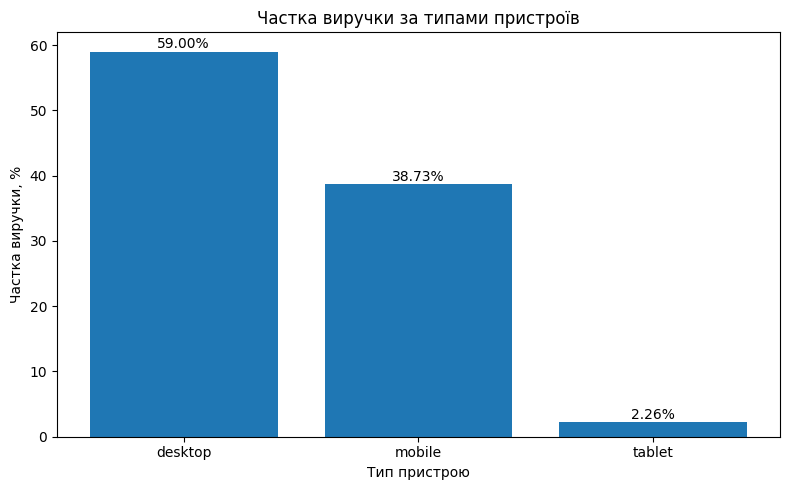

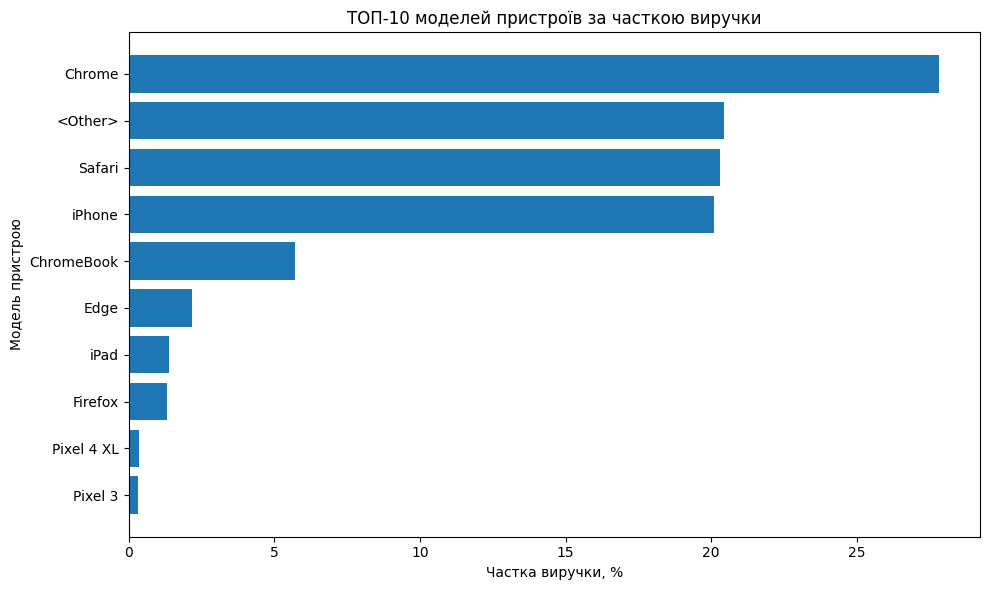

In [ ]:
# ============================================================
# КРОК 1.6 — Продажі за типами пристроїв та моделями
# ============================================================

# Загальна виручка
total_revenue = sales_df["price"].sum()


# ------------------------------------------------------------
# 1. Продажі за типами пристроїв
# ------------------------------------------------------------

device_sales = (
    sales_df
    .groupby("device", dropna=False)
    .agg(
        orders=("session_id", "count"),
        revenue=("price", "sum")
    )
    .reset_index()
)

device_sales["revenue_share"] = (
    device_sales["revenue"] / total_revenue * 100
)

device_sales = device_sales.sort_values(
    "revenue",
    ascending=False
)

print("Продажі за типами пристроїв:")
display(device_sales)


# ------------------------------------------------------------
# 2. Продажі за моделями пристроїв
# ------------------------------------------------------------

model_sales = (
    sales_df
    .dropna(subset=["mobile_model_name"])
    .groupby("mobile_model_name")
    .agg(
        orders=("session_id", "count"),
        revenue=("price", "sum")
    )
    .reset_index()
)

model_sales["revenue_share"] = (
    model_sales["revenue"] / total_revenue * 100
)

model_sales = model_sales.sort_values(
    "revenue",
    ascending=False
)

print("ТОП-10 моделей пристроїв за виручкою:")
display(model_sales.head(10))


# ------------------------------------------------------------
# 3. Візуалізація: частка виручки за типами пристроїв
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    device_sales["device"].astype(str),
    device_sales["revenue_share"]
)

plt.title("Частка виручки за типами пристроїв")
plt.xlabel("Тип пристрою")
plt.ylabel("Частка виручки, %")

for i, value in enumerate(device_sales["revenue_share"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Візуалізація: ТОП-10 моделей за часткою виручки
# ------------------------------------------------------------

top_models = model_sales.head(10).sort_values(
    "revenue_share"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_models["mobile_model_name"].astype(str),
    top_models["revenue_share"]
)

plt.title("ТОП-10 моделей пристроїв за часткою виручки")
plt.xlabel("Частка виручки, %")
plt.ylabel("Модель пристрою")

plt.tight_layout()
plt.show()

За типом пристрою домінує desktop — 59.00% усієї виручки, mobile генерує 38.73%, а tablet — 2.26%. Desktop і mobile разом формують 97.74% виручки, тому саме ці два типи пристроїв є основними для продажів. При цьому revenue per order між основними типами пристроїв близький, тому різниця в загальній виручці переважно пояснюється кількістю замовлень. Аналіз mobile_model_name показав, що поле містить змішані значення: поряд із назвами моделей присутні назви браузерів, зокрема Chrome, Safari, Edge та Firefox. Тому результати за цим полем варто трактувати як exploratory analysis і не використовувати для точних висновків про ефективність окремих моделей пристроїв.

In [ ]:
# ============================================================
# КРОК 1.7 — Зареєстровані користувачі та newsletter status
# ============================================================

# Беремо тільки зареєстровані сесії
registered_df = df[df["registered_user_id"].notna()].copy()


# ------------------------------------------------------------
# 1. Email verification
# ------------------------------------------------------------

email_status = (
    registered_df
    .groupby("email_verified")
    .agg(
        users=("registered_user_id", "nunique"),
        orders=("price", lambda x: x.notna().sum()),
        revenue=("price", "sum")
    )
    .reset_index()
)

total_registered_users = registered_df["registered_user_id"].nunique()

email_status["user_share"] = (
    email_status["users"]
    / total_registered_users
    * 100
)


# ------------------------------------------------------------
# 2. Newsletter status
# ------------------------------------------------------------

newsletter_status = (
    registered_df
    .groupby("newsletter_unsubscribed")
    .agg(
        users=("registered_user_id", "nunique"),
        orders=("price", lambda x: x.notna().sum()),
        revenue=("price", "sum")
    )
    .reset_index()
)

newsletter_status["user_share"] = (
    newsletter_status["users"]
    / total_registered_users
    * 100
)

newsletter_status["revenue_share"] = (
    newsletter_status["revenue"]
    / newsletter_status["revenue"].sum()
    * 100
)

newsletter_status["revenue_per_order"] = (
    newsletter_status["revenue"]
    / newsletter_status["orders"]
)


# ------------------------------------------------------------
# 3. Робимо зрозумілі підписи
# ------------------------------------------------------------

email_status["email_status"] = email_status["email_verified"].map({
    0: "Not verified",
    1: "Verified"
})

newsletter_status["newsletter_status"] = (
    newsletter_status["newsletter_unsubscribed"].map({
        0: "Subscribed",
        1: "Unsubscribed"
    })
)


# ------------------------------------------------------------
# 4. Виведення
# ------------------------------------------------------------

print("=== EMAIL VERIFICATION ===")

display(
    email_status[
        ["email_status", "users", "user_share", "orders", "revenue"]
    ].style.format({
        "users": "{:,}",
        "user_share": "{:.2f}%",
        "orders": "{:,}",
        "revenue": "{:,.2f}"
    })
)


print("\n=== NEWSLETTER STATUS ===")

display(
    newsletter_status[
        [
            "newsletter_status",
            "users",
            "user_share",
            "orders",
            "revenue",
            "revenue_share",
            "revenue_per_order"
        ]
    ].style.format({
        "users": "{:,}",
        "user_share": "{:.2f}%",
        "orders": "{:,}",
        "revenue": "{:,.2f}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)

=== EMAIL VERIFICATION ===


,email_status,users,user_share,orders,revenue
0,Not verified,"7,909",28.30%,792,"716,501.10"
1,Verified,"20,036",71.70%,"1,989","1,866,017.40"



=== NEWSLETTER STATUS ===


,newsletter_status,users,user_share,orders,revenue,revenue_share,revenue_per_order
0,Subscribed,"23,210",83.06%,"2,334","2,150,796.90",83.28%,921.51
1,Unsubscribed,"4,735",16.94%,447,"431,721.60",16.72%,965.82


Серед зареєстрованих користувачів 71.70% мають підтверджений email, тоді як 28.30% залишаються непідтвердженими. Це означає, що більшість зареєстрованої аудиторії пройшла email verification, однак понад чверть користувачів потенційно залишається недоступною для повноцінної email-комунікації.

In [ ]:
# ============================================================
# КРОК 1.8 — Порівняння поведінки Subscribed vs Unsubscribed
# ============================================================

newsletter_behavior = (
    registered_df
    .groupby("newsletter_unsubscribed")
    .agg(
        users=("registered_user_id", "nunique"),
        orders=("price", lambda x: x.notna().sum()),
        revenue=("price", "sum")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Основні метрики
# ------------------------------------------------------------

newsletter_behavior["conversion_rate"] = (
    newsletter_behavior["orders"]
    / newsletter_behavior["users"]
    * 100
)

newsletter_behavior["revenue_per_user"] = (
    newsletter_behavior["revenue"]
    / newsletter_behavior["users"]
)

newsletter_behavior["revenue_per_order"] = (
    newsletter_behavior["revenue"]
    / newsletter_behavior["orders"]
)

# Зрозумілі назви
newsletter_behavior["newsletter_status"] = (
    newsletter_behavior["newsletter_unsubscribed"].map({
        0: "Subscribed",
        1: "Unsubscribed"
    })
)

# ------------------------------------------------------------
# Різниця між групами
# ------------------------------------------------------------

subscribed = newsletter_behavior[
    newsletter_behavior["newsletter_status"] == "Subscribed"
].iloc[0]

unsubscribed = newsletter_behavior[
    newsletter_behavior["newsletter_status"] == "Unsubscribed"
].iloc[0]

conversion_difference = (
    unsubscribed["conversion_rate"]
    - subscribed["conversion_rate"]
)

revenue_per_order_difference_pct = (
    unsubscribed["revenue_per_order"]
    / subscribed["revenue_per_order"]
    - 1
) * 100

revenue_per_user_difference_pct = (
    unsubscribed["revenue_per_user"]
    / subscribed["revenue_per_user"]
    - 1
) * 100


# ------------------------------------------------------------
# Результат
# ------------------------------------------------------------

print("=== NEWSLETTER BEHAVIOR ===")

display(
    newsletter_behavior[
        [
            "newsletter_status",
            "users",
            "orders",
            "conversion_rate",
            "revenue",
            "revenue_per_user",
            "revenue_per_order"
        ]
    ].style.format({
        "users": "{:,}",
        "orders": "{:,}",
        "conversion_rate": "{:.2f}%",
        "revenue": "{:,.2f}",
        "revenue_per_user": "{:,.2f}",
        "revenue_per_order": "{:,.2f}"
    })
)

print("\n=== GROUP DIFFERENCES ===")
print(
    f"Різниця conversion rate (Unsubscribed − Subscribed): "
    f"{conversion_difference:+.2f} п.п."
)

print(
    f"Різниця revenue per order: "
    f"{revenue_per_order_difference_pct:+.2f}%"
)

print(
    f"Різниця revenue per user: "
    f"{revenue_per_user_difference_pct:+.2f}%"
)

=== NEWSLETTER BEHAVIOR ===


,newsletter_status,users,orders,conversion_rate,revenue,revenue_per_user,revenue_per_order
0,Subscribed,"23,210","2,334",10.06%,"2,150,796.90",92.67,921.51
1,Unsubscribed,"4,735",447,9.44%,"431,721.60",91.18,965.82



=== GROUP DIFFERENCES ===
Різниця conversion rate (Unsubscribed − Subscribed): -0.62 п.п.
Різниця revenue per order: +4.81%
Різниця revenue per user: -1.61%


Серед зареєстрованих користувачів 83.06% залишаються підписаними на newsletter, тоді як 16.94% відписалися. Subscribed users мають дещо вищий conversion rate — 10.06% проти 9.44% у unsubscribed, проте різниця статистично незначуща (p = 0.197). Водночас середня виручка з одного замовлення у unsubscribed вища на 4.81%. Отже, наявні дані не дають підстав стверджувати, що статус newsletter суттєво пов'язаний із conversion rate або що підписка сама по собі підвищує продажі.

=== TOP-10 COUNTRIES BY REGISTERED USERS ===


,country,registered_users,orders,revenue,conversion_rate,revenue_per_user,user_share
0,United States,"12,384","1,207","1,100,367.80",9.75%,88.85,44.32%
1,India,"2,687",246,"207,605.50",9.16%,77.26,9.62%
2,Canada,"2,067",207,"192,894.40",10.01%,93.32,7.40%
3,United Kingdom,859,88,"65,141.50",10.24%,75.83,3.07%
4,France,553,56,"58,508.00",10.13%,105.80,1.98%
5,Spain,536,48,"51,409.30",8.96%,95.91,1.92%
6,Taiwan,500,51,"55,984.00",10.20%,111.97,1.79%
7,China,490,48,"38,174.10",9.80%,77.91,1.75%
8,Germany,490,56,"50,546.50",11.43%,103.16,1.75%
9,Italy,386,38,"44,987.00",9.84%,116.55,1.38%


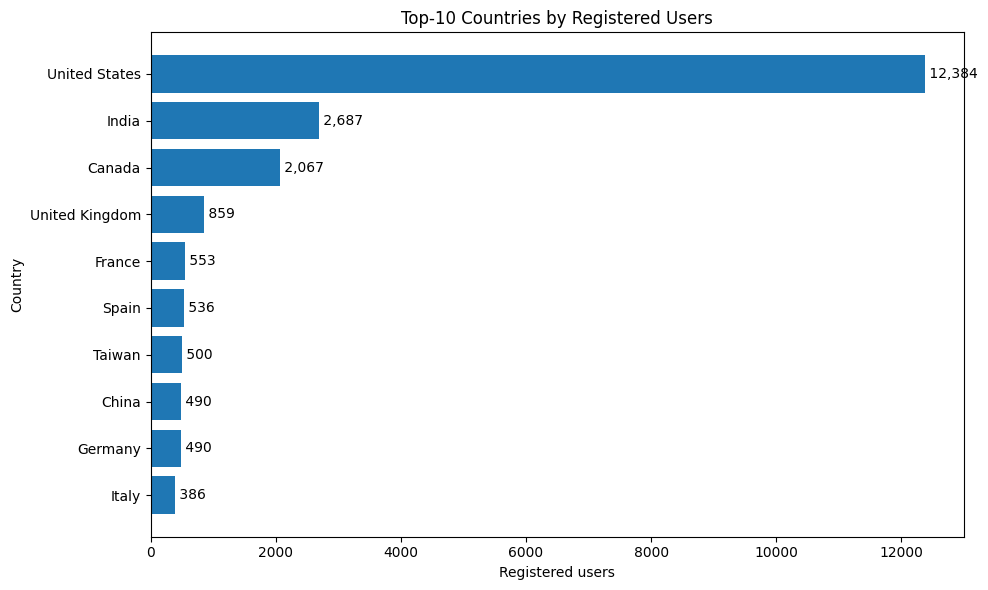

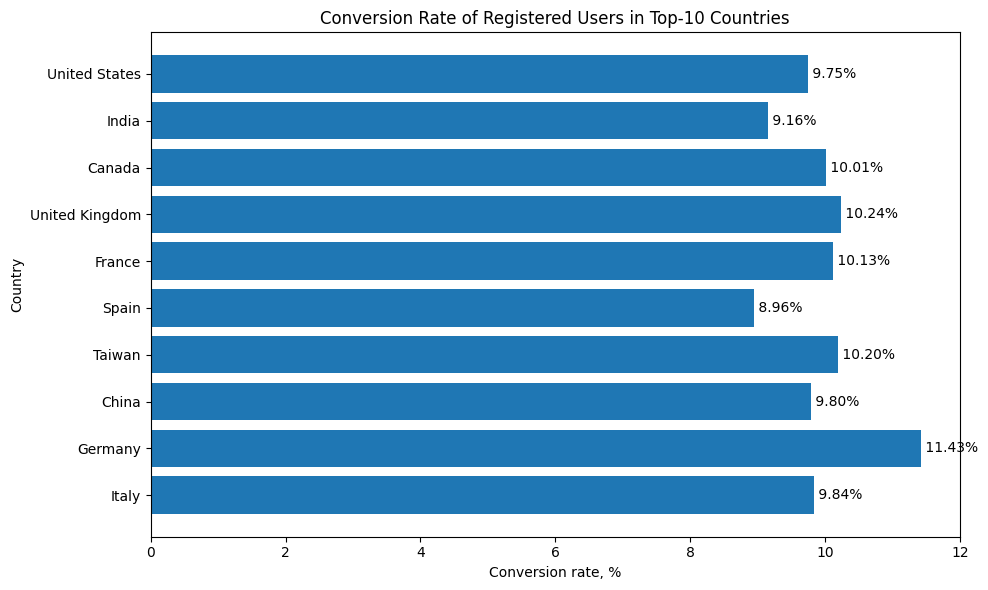

In [ ]:
# ============================================================
# КРОК 1.9 — Країни з найбільшою кількістю зареєстрованих
# користувачів
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Розрахунок показників за країнами
# ------------------------------------------------------------

registered_country_analysis = (
    registered_df
    .groupby("country")
    .agg(
        registered_users=("registered_user_id", "nunique"),
        orders=("price", lambda x: x.notna().sum()),
        revenue=("price", "sum")
    )
    .reset_index()
)

# Conversion зареєстрованих користувачів у замовлення
registered_country_analysis["conversion_rate"] = (
    registered_country_analysis["orders"]
    / registered_country_analysis["registered_users"]
    * 100
)

# Revenue на одного зареєстрованого користувача
registered_country_analysis["revenue_per_user"] = (
    registered_country_analysis["revenue"]
    / registered_country_analysis["registered_users"]
)

# Частка кожної країни серед усіх зареєстрованих користувачів
registered_country_analysis["user_share"] = (
    registered_country_analysis["registered_users"]
    / registered_country_analysis["registered_users"].sum()
    * 100
)

# TOP-10 країн за кількістю зареєстрованих користувачів
top_10_registered_countries = (
    registered_country_analysis
    .sort_values("registered_users", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Таблиця TOP-10
# ------------------------------------------------------------

print("=== TOP-10 COUNTRIES BY REGISTERED USERS ===")

display(
    top_10_registered_countries.style.format({
        "registered_users": "{:,}",
        "user_share": "{:.2f}%",
        "orders": "{:,}",
        "conversion_rate": "{:.2f}%",
        "revenue": "{:,.2f}",
        "revenue_per_user": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# 3. Візуалізація — кількість зареєстрованих користувачів
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_registered_countries["country"],
    top_10_registered_countries["registered_users"]
)

plt.xlabel("Registered users")
plt.ylabel("Country")
plt.title("Top-10 Countries by Registered Users")

# Найбільша країна зверху
plt.gca().invert_yaxis()

# Підписи значень
for i, value in enumerate(top_10_registered_countries["registered_users"]):
    plt.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Візуалізація — conversion rate у TOP-10 країнах
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_registered_countries["country"],
    top_10_registered_countries["conversion_rate"]
)

plt.xlabel("Conversion rate, %")
plt.ylabel("Country")
plt.title("Conversion Rate of Registered Users in Top-10 Countries")

plt.gca().invert_yaxis()

# Підписи значень
for i, value in enumerate(top_10_registered_countries["conversion_rate"]):
    plt.text(
        value,
        i,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

За кількістю зареєстрованих користувачів домінують США — 12 384 користувачі, або 44.32% усієї зареєстрованої бази. Водночас масштаб аудиторії не завжди відповідає її ефективності: серед TOP-10 країн Germany має найвищий conversion rate — 11.43%, а Italy — найвищий revenue per user — 116.55. Це показує, що для оцінки ринків важливо враховувати не лише кількість користувачів, а й показники конверсії та монетизації.

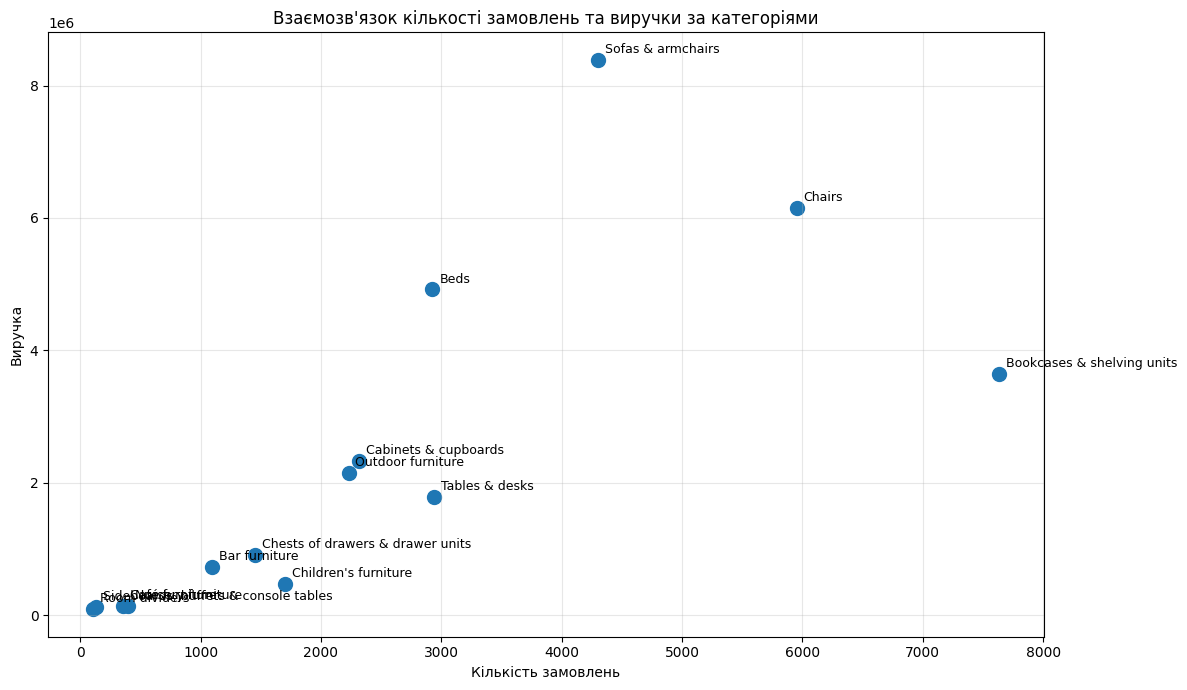

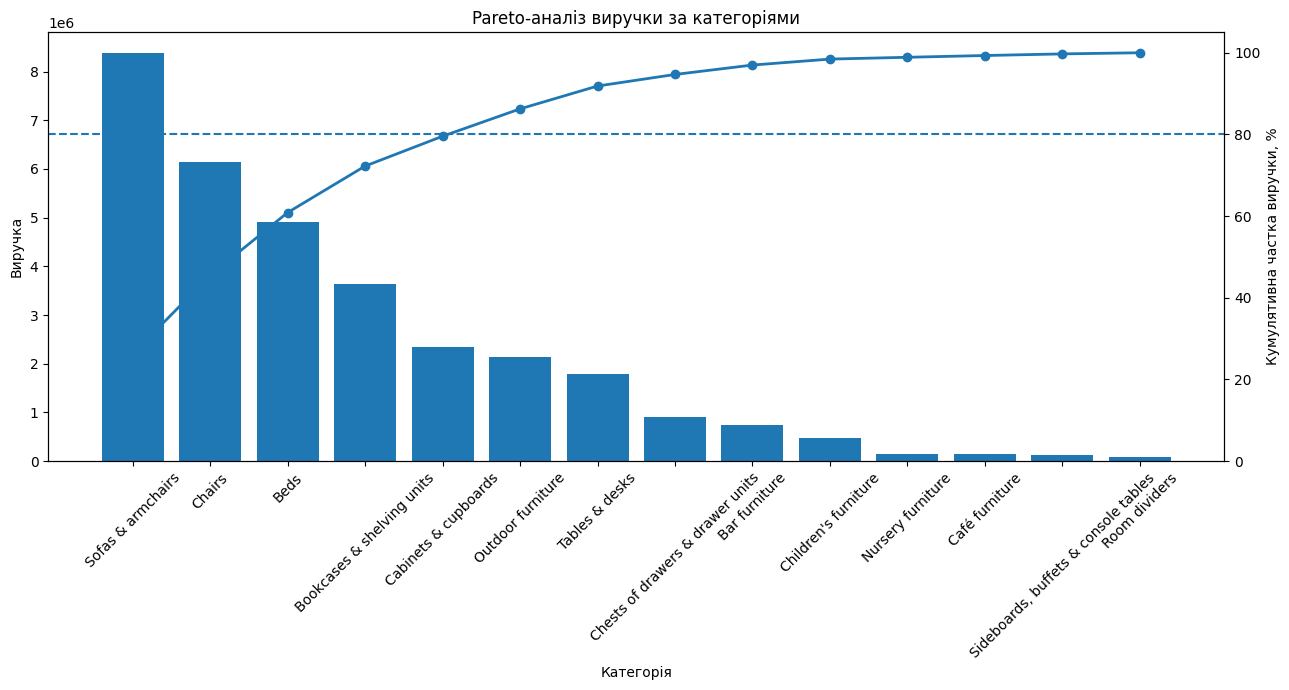

=== REGISTERED VS UNREGISTERED USERS ===


,user_status,sessions,orders,revenue,conversion,revenue_per_session
0,Registered,"27,945","2,781","2,582,518.50",9.95%,92.41
1,Unregistered,"321,600","30,757","29,389,212.60",9.56%,91.38


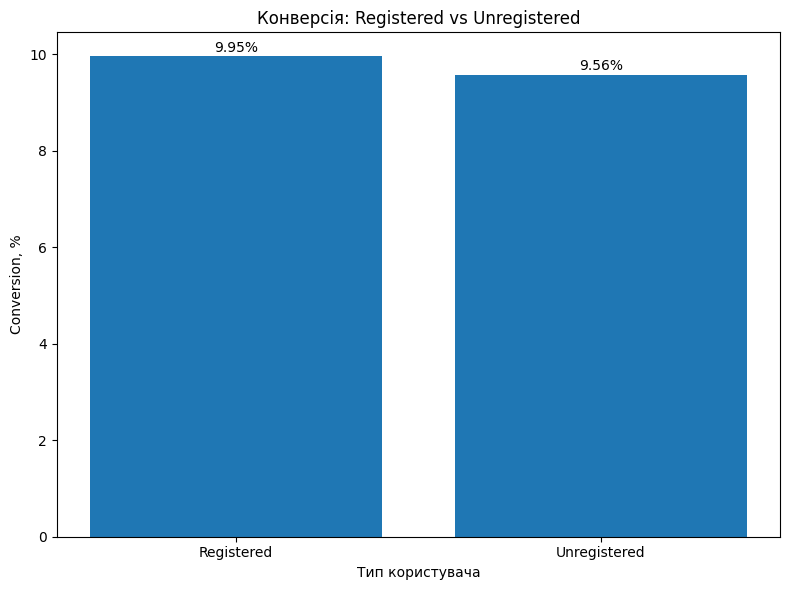

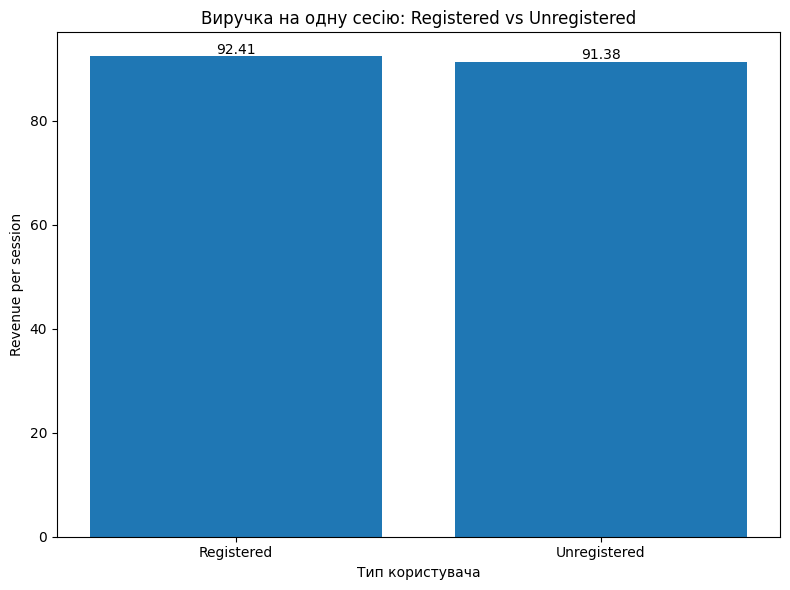

In [ ]:
# ============================================================
# ДОДАТКОВІ ІНСАЙТИ + ВІЗУАЛІЗАЦІЇ
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1.10 — Revenue vs Orders за категоріями
# ============================================================

category_analysis = (
    sales_df
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(12, 7))

plt.scatter(
    category_analysis["orders"],
    category_analysis["revenue"],
    s=100
)

for _, row in category_analysis.iterrows():
    plt.annotate(
        row["product_category"],
        (row["orders"], row["revenue"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Взаємозв'язок кількості замовлень та виручки за категоріями")
plt.xlabel("Кількість замовлень")
plt.ylabel("Виручка")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 1.11 — Pareto: концентрація виручки за категоріями
# ============================================================

pareto = (
    category_analysis[
        ["product_category", "revenue"]
    ]
    .copy()
)

pareto["revenue_share"] = (
    pareto["revenue"]
    / pareto["revenue"].sum()
    * 100
)

pareto["cumulative_share"] = (
    pareto["revenue_share"].cumsum()
)

fig, ax1 = plt.subplots(figsize=(13, 7))

ax1.bar(
    pareto["product_category"],
    pareto["revenue"]
)

ax1.set_xlabel("Категорія")
ax1.set_ylabel("Виручка")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    pareto["product_category"],
    pareto["cumulative_share"],
    marker="o",
    linewidth=2
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1.5
)

ax2.set_ylabel("Кумулятивна частка виручки, %")
ax2.set_ylim(0, 105)

plt.title("Pareto-аналіз виручки за категоріями")
plt.tight_layout()
plt.show()


# ============================================================
# 1.12 — Registered vs Unregistered users
# ============================================================

user_status_analysis = (
    df
    .assign(
        user_status=np.where(
            df["registered_user_id"].notna(),
            "Registered",
            "Unregistered"
        )
    )
    .groupby("user_status")
    .agg(
        sessions=("session_id", "nunique"),
        orders=("price", lambda x: x.notna().sum()),
        revenue=("price", "sum")
    )
    .reset_index()
)

# Конверсія в замовлення
user_status_analysis["conversion"] = (
    user_status_analysis["orders"]
    / user_status_analysis["sessions"]
    * 100
)

# Виручка на одну сесію
user_status_analysis["revenue_per_session"] = (
    user_status_analysis["revenue"]
    / user_status_analysis["sessions"]
)

print("=== REGISTERED VS UNREGISTERED USERS ===")

display(
    user_status_analysis.style.format({
        "sessions": "{:,}",
        "orders": "{:,}",
        "revenue": "{:,.2f}",
        "conversion": "{:.2f}%",
        "revenue_per_session": "{:.2f}"
    })
)


# ------------------------------------------------------------
# Графік 1 — Conversion
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.bar(
    user_status_analysis["user_status"],
    user_status_analysis["conversion"]
)

plt.title("Конверсія: Registered vs Unregistered")
plt.xlabel("Тип користувача")
plt.ylabel("Conversion, %")

for i, value in enumerate(user_status_analysis["conversion"]):
    plt.text(
        i,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Графік 2 — Revenue per session
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.bar(
    user_status_analysis["user_status"],
    user_status_analysis["revenue_per_session"]
)

plt.title("Виручка на одну сесію: Registered vs Unregistered")
plt.xlabel("Тип користувача")
plt.ylabel("Revenue per session")

for i, value in enumerate(
    user_status_analysis["revenue_per_session"]
):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Порівняння Registered та Unregistered users показує, що зареєстровані користувачі мають дещо вищі показники ефективності: conversion rate становить 9.95% проти 9.56% у незареєстрованих, а revenue per session — 92.41 проти 91.38. Водночас Unregistered users формують основний обсяг виручки — 29.39 млн проти 2.58 млн у Registered, що пояснюється значно більшою кількістю сесій. Отже, зареєстровані користувачі демонструють дещо вищу монетизацію на одну сесію, але основний внесок у загальну виручку забезпечує незареєстрована аудиторія.


# **# Загальний висновок по пункту 1:**
Аналіз продажів показав, що основним ринком магазину є Americas, на який припадає 55.25% усієї виручки, а United States самостійно формує 43.61%. При цьому середня виручка з одного замовлення між провідними континентами майже не відрізняється (≈948–956), тому перевага Americas пояснюється передусім більшою кількістю замовлень.

Продажі мають високу категоріальну концентрацію: три найбільші категорії — Sofas & armchairs, Chairs та Beds — формують 60.86% виручки, а TOP-10 категорій — 98.45%. Найбільшу виручку генерують Sofas & armchairs (26.24%), причому їхній середній revenue per order становить 1 950.30. Водночас Bookcases & shelving units мають найбільшу кількість замовлень (7 630), але формують лише 11.39% виручки, що демонструє різницю між популярністю категорії та її фінансовим внеском. Структура категорій у США майже повністю відповідає глобальній: найбільше відхилення становить лише 0.48 п.п.

За типом пристрою домінує desktop — 59.00% виручки, mobile генерує 38.73%, а tablet — 2.26%. Desktop і mobile разом формують 97.74% виручки, тому саме ці два типи пристроїв є основними для продажів. Водночас аналіз поля `mobile_model_name` виявив неконсистентні значення: поряд із назвами моделей присутні назви браузерів, тому результати за цим полем слід трактувати обережно.

Основним визначеним джерелом продажів є organic traffic — 34.20% виручки. Водночас `(none)`, порожні значення та `(data deleted)` разом формують 43.88% виручки. Це обмежує можливість точно оцінити ефективність окремих джерел залучення та вказує на необхідність покращення якості attribution data.

Серед зареєстрованих користувачів 71.70% підтвердили email, а 16.94% відписалися від newsletter. Subscribed users мають дещо вищий conversion rate (10.06% проти 9.44%), проте ця різниця статистично незначуща. Водночас Unsubscribed мають вищий середній revenue per order на 4.81%, тому наявні дані не дають підстав стверджувати про причинний вплив статусу newsletter на поведінку користувачів.

Зареєстровані користувачі мають дещо вищі показники ефективності за сесію: conversion rate становить 9.95% проти 9.56% у незареєстрованих, а revenue per session — 92.41 проти 91.38. Водночас основний обсяг виручки формують Unregistered users через значно більшу кількість сесій.

За кількістю зареєстрованих користувачів також домінують США — 44.32% усієї зареєстрованої бази. Водночас країни з меншою кількістю користувачів можуть демонструвати вищу ефективність: Germany має найвищий conversion rate серед TOP-10 (11.43%), а Italy — найвищий revenue per user (116.55). Отже, для оцінки ринків важливо враховувати не лише масштаб аудиторії, а й ефективність її монетизації.

Загалом продажі магазину характеризуються сильною концентрацією за географією та категоріями, тоді як ефективність окремих сегментів значною мірою залежить від кількості замовлень і масштабу аудиторії. Основний потенціал для подальшого аналізу полягає у вивченні ефективності окремих ринків і джерел трафіку, покращенні якості attribution data та пошуку сегментів із високою конверсією або монетизацією, але меншим поточним масштабом.


=== DAILY SALES DYNAMICS ===
Кількість календарних днів: 92
Середня виручка за день: 347,518.82
Середня кількість замовлень за день: 365

Найкращий день: 2020-12-08 — 680,509.50 revenue, 689 orders
Найгірший день: 2021-01-28 — 0.00 revenue, 0 orders

=== MONTHLY SALES DYNAMICS ===


,month,revenue,orders,revenue_per_order,revenue_change_pct
0,2020-11,"9,897,515.00","10,540",939.04,+nan%
1,2020-12,"12,423,439.30","12,903",962.83,+25.52%
2,2021-01,"9,650,776.80","10,095",956.00,-22.32%


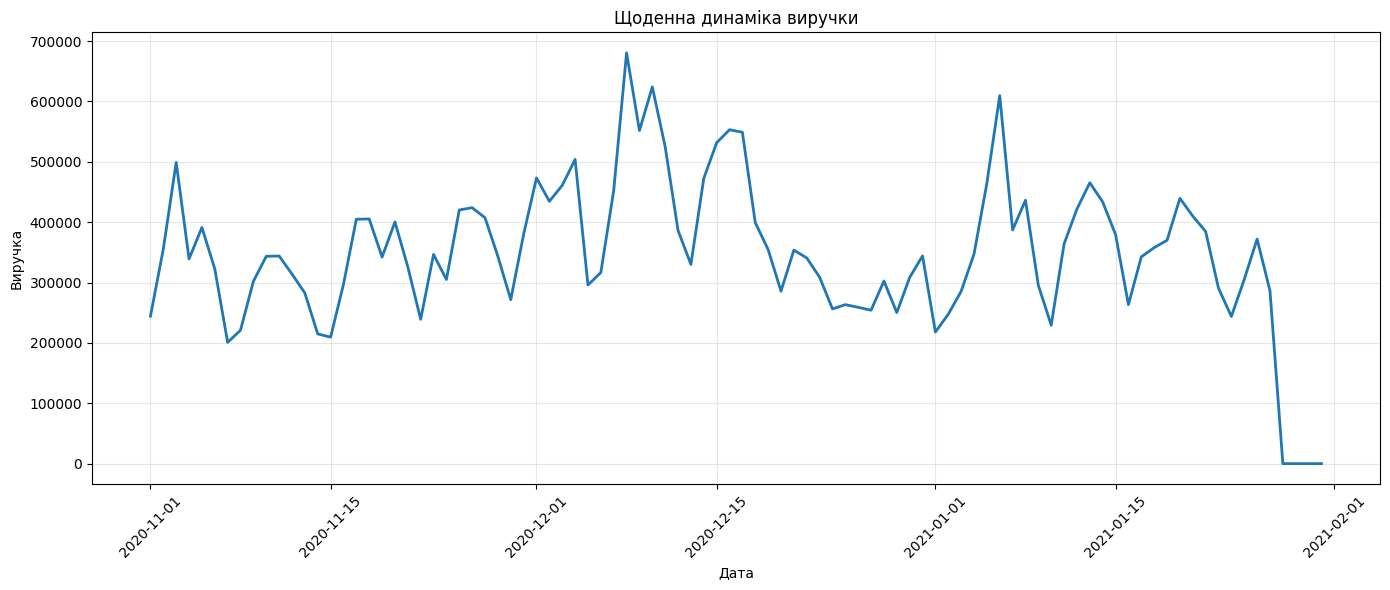

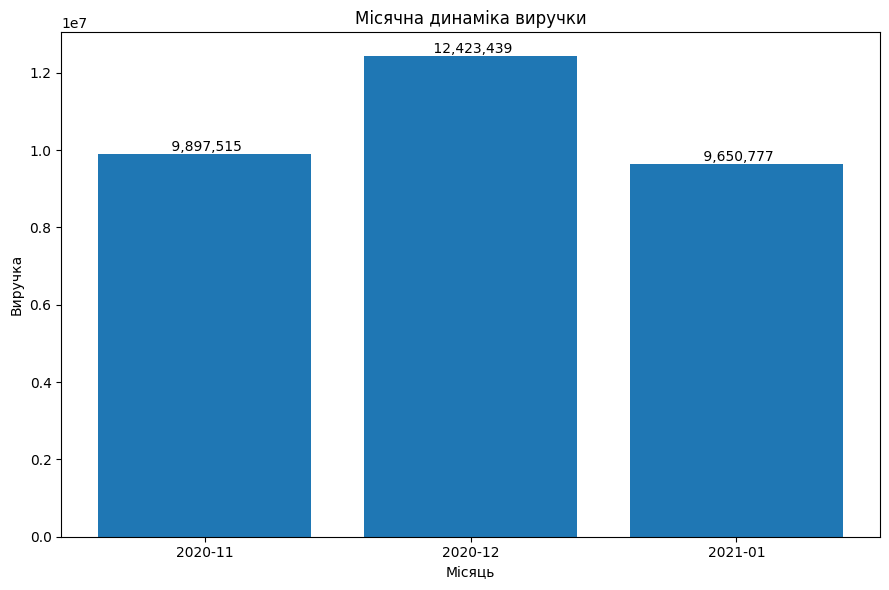

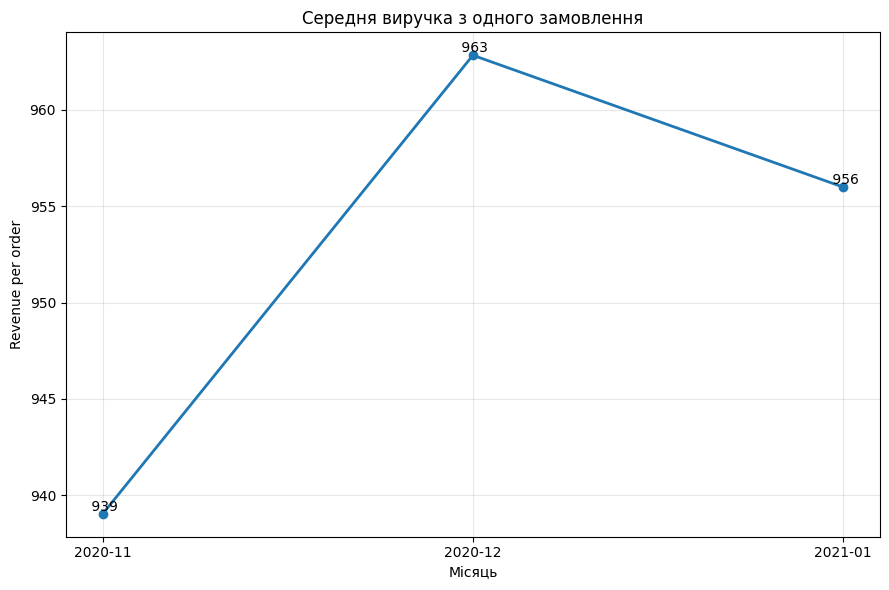

In [ ]:
# ============================================================
# ПУНКТ 2.1 — Динаміка продажів у часі
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Щоденна динаміка
# ============================================================

# Створюємо повний календар від першої до останньої дати
# Щоб у аналізі були присутні також дні без продажів
full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

daily_sales = (
    df
    .groupby("session_date")
    .agg(
        revenue=("price", "sum"),
        orders=("price", "count")
    )
    .reindex(full_dates, fill_value=0)
    .rename_axis("session_date")
    .reset_index()
    .sort_values("session_date")
)

# Revenue per order розраховуємо тільки для днів,
# коли було хоча б одне замовлення
daily_sales["revenue_per_order"] = np.where(
    daily_sales["orders"] > 0,
    daily_sales["revenue"] / daily_sales["orders"],
    np.nan
)


# ============================================================
# 2. Основні статистики
# ============================================================

average_daily_revenue = daily_sales["revenue"].mean()
average_daily_orders = daily_sales["orders"].mean()

best_day = daily_sales.loc[
    daily_sales["revenue"].idxmax()
]

worst_day = daily_sales.loc[
    daily_sales["revenue"].idxmin()
]


# ============================================================
# 3. Місячна динаміка
# ============================================================

monthly_sales = (
    sales_df
    .assign(
        month=sales_df["session_date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("month")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

monthly_sales["revenue_per_order"] = (
    monthly_sales["revenue"] / monthly_sales["orders"]
)

monthly_sales["revenue_change_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)


# ============================================================
# 4. Виведення результатів
# ============================================================

print("=== DAILY SALES DYNAMICS ===")

print(
    f"Кількість календарних днів: "
    f"{len(daily_sales)}"
)

print(
    f"Середня виручка за день: "
    f"{average_daily_revenue:,.2f}"
)

print(
    f"Середня кількість замовлень за день: "
    f"{average_daily_orders:,.0f}"
)

print(
    f"\nНайкращий день: "
    f"{best_day['session_date'].date()} — "
    f"{best_day['revenue']:,.2f} revenue, "
    f"{int(best_day['orders']):,} orders"
)

print(
    f"Найгірший день: "
    f"{worst_day['session_date'].date()} — "
    f"{worst_day['revenue']:,.2f} revenue, "
    f"{int(worst_day['orders']):,} orders"
)


print("\n=== MONTHLY SALES DYNAMICS ===")

display(
    monthly_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_per_order": "{:,.2f}",
        "revenue_change_pct": "{:+.2f}%"
    })
)


# ============================================================
# 5. Графік — щоденна виручка
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["session_date"],
    daily_sales["revenue"],
    linewidth=2
)

plt.title("Щоденна динаміка виручки")
plt.xlabel("Дата")
plt.ylabel("Виручка")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Графік — місячна виручка
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    monthly_sales["month"],
    monthly_sales["revenue"]
)

plt.title("Місячна динаміка виручки")
plt.xlabel("Місяць")
plt.ylabel("Виручка")

for i, value in enumerate(monthly_sales["revenue"]):
    plt.text(
        i,
        value,
        f" {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 7. Графік — середня виручка з одного замовлення
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue_per_order"],
    marker="o",
    linewidth=2
)

plt.title("Середня виручка з одного замовлення")
plt.xlabel("Місяць")
plt.ylabel("Revenue per order")

for i, value in enumerate(monthly_sales["revenue_per_order"]):
    plt.text(
        i,
        value,
        f" {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Аналіз часової динаміки показує, що за 92 календарні дні середня денна виручка магазину становить **347 518.82**, а середня кількість замовлень — близько **365 на день**. Найвищий результат зафіксовано **8 грудня 2020 року** — **680 509.50** виручки та **689 замовлень**. Найнижчі значення припадають на **28–31 січня 2021 року**, коли продажів не було.

На місячному рівні найвищу виручку отримано у **грудні — 12.42 млн**, що на **25.52% більше**, ніж у листопаді. У січні виручка знизилася до **9.65 млн**, тобто на **22.32%** порівняно з груднем. При цьому середня виручка з одного замовлення змінювалася значно менше, тому основні коливання загальної виручки пов'язані переважно зі зміною кількості замовлень.

За доступний тримісячний період можна спостерігати **місячну та календарну динаміку продажів**, однак цього недостатньо для підтвердження **стійкої сезонності**. Для надійного аналізу сезонності потрібні дані щонайменше за один повний рік, а бажано — за декілька років.


=== REGIONAL MONTHLY SALES DYNAMICS ===


,month,continent,revenue,orders,revenue_per_order,revenue_change_pct
0,2020-11,Americas,"5,439,027.90","5,835",932.14,+nan%
1,2020-11,Asia,"2,393,234.60","2,483",963.85,+nan%
2,2020-11,Europe,"1,825,299.10","1,963",929.85,+nan%
3,2020-12,Americas,"6,854,446.40","7,124",962.16,+26.02%
4,2020-12,Asia,"2,905,399.60","3,100",937.23,+21.40%
5,2020-12,Europe,"2,349,627.60","2,390",983.11,+28.73%
6,2021-01,Americas,"5,371,805.70","5,594",960.28,-21.63%
7,2021-01,Asia,"2,302,664.10","2,367",972.82,-20.75%
8,2021-01,Europe,"1,759,697.50","1,908",922.27,-25.11%



=== BEST SALES DAY BY REGION ===


,session_date,continent,revenue,orders
0,2021-01-06 00:00:00,Americas,"374,614.90",315
1,2020-12-08 00:00:00,Asia,"164,164.80",170
2,2020-12-08 00:00:00,Europe,"150,175.10",120


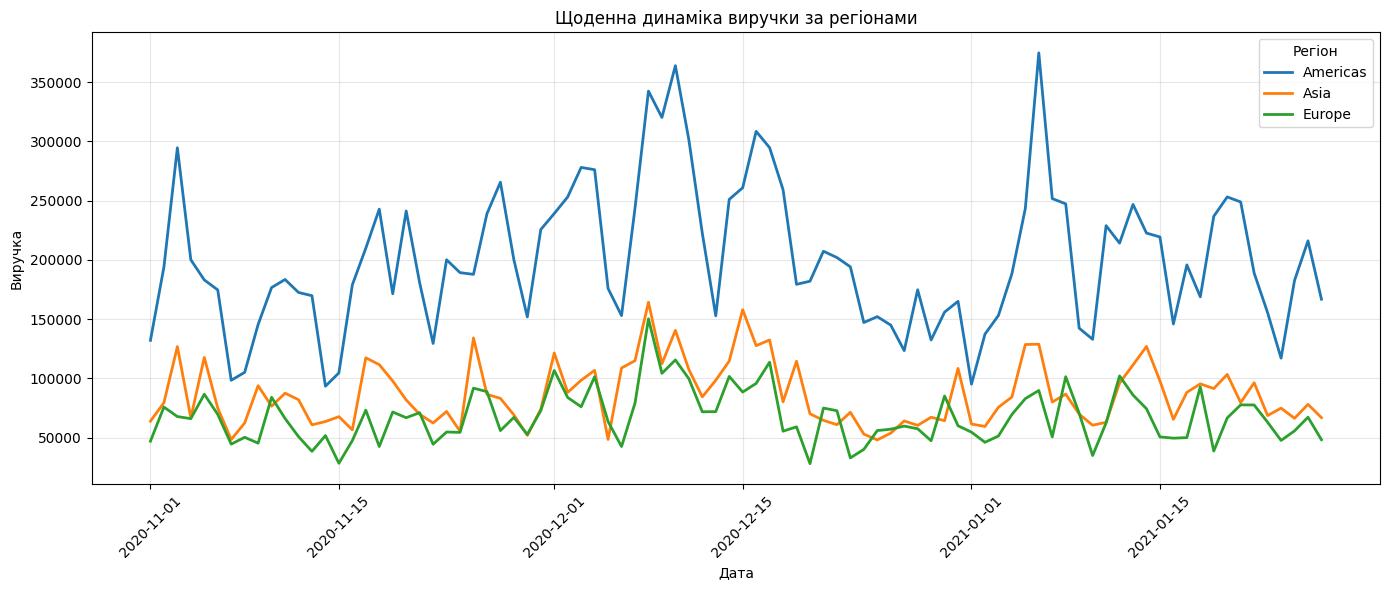

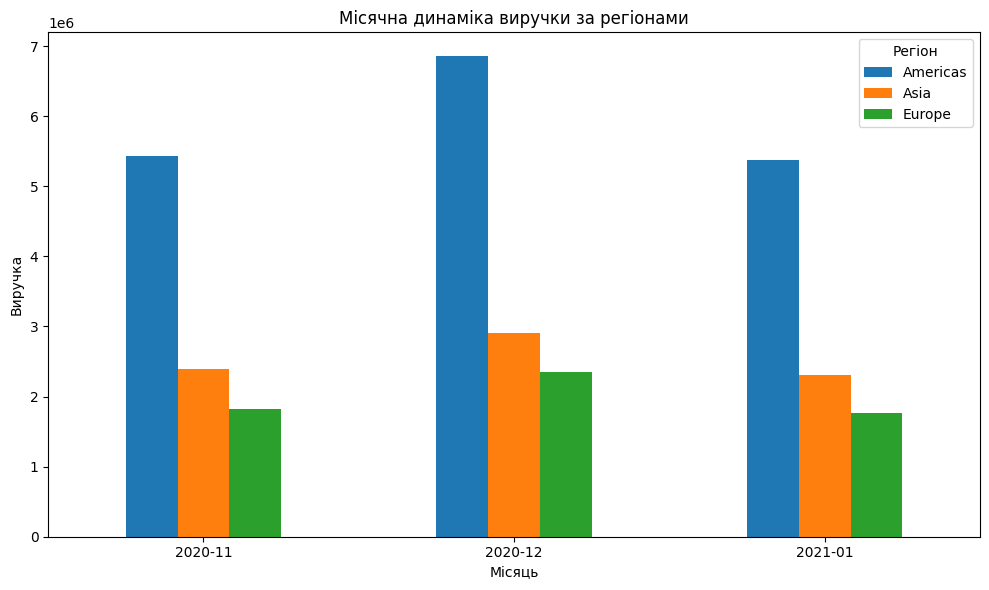

In [ ]:
# ============================================================
# ПУНКТ 2.2 — Динаміка продажів Americas / Asia / Europe
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. Залишаємо тільки три основні континенти
# ============================================================

regions = ["Americas", "Asia", "Europe"]

regional_daily_sales = (
    sales_df[
        sales_df["continent"].isin(regions)
    ]
    .groupby(["session_date", "continent"])
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
    .sort_values(["session_date", "continent"])
)


# ============================================================
# 2. Місячна динаміка за регіонами
# ============================================================

regional_monthly_sales = (
    sales_df[
        sales_df["continent"].isin(regions)
    ]
    .assign(
        month=lambda x: (
            x["session_date"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(["month", "continent"])
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

regional_monthly_sales["revenue_per_order"] = (
    regional_monthly_sales["revenue"]
    / regional_monthly_sales["orders"]
)


# ============================================================
# 3. Зміна revenue month-over-month всередині кожного регіону
# ============================================================

regional_monthly_sales["revenue_change_pct"] = (
    regional_monthly_sales
    .groupby("continent")["revenue"]
    .pct_change()
    * 100
)


# ============================================================
# 4. Виведення результатів
# ============================================================

print("=== REGIONAL MONTHLY SALES DYNAMICS ===")

display(
    regional_monthly_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_per_order": "{:,.2f}",
        "revenue_change_pct": "{:+.2f}%"
    })
)


# ============================================================
# 5. Найкращий день для кожного регіону
# ============================================================

regional_best_days = (
    regional_daily_sales
    .loc[
        regional_daily_sales
        .groupby("continent")["revenue"]
        .idxmax()
    ]
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

print("\n=== BEST SALES DAY BY REGION ===")

display(
    regional_best_days.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}"
    })
)


# ============================================================
# 6. Візуалізація — щоденна динаміка виручки за регіонами
# ============================================================

regional_daily_pivot = (
    regional_daily_sales
    .pivot(
        index="session_date",
        columns="continent",
        values="revenue"
    )
    .reindex(columns=regions)
)

plt.figure(figsize=(14, 6))

for region in regions:
    plt.plot(
        regional_daily_pivot.index,
        regional_daily_pivot[region],
        label=region,
        linewidth=2
    )

plt.title("Щоденна динаміка виручки за регіонами")
plt.xlabel("Дата")
plt.ylabel("Виручка")
plt.legend(title="Регіон")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 7. Візуалізація — місячна виручка за регіонами
# ============================================================

regional_monthly_pivot = (
    regional_monthly_sales
    .pivot(
        index="month",
        columns="continent",
        values="revenue"
    )
    .reindex(columns=regions)
)

ax = regional_monthly_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Місячна динаміка виручки за регіонами")
ax.set_xlabel("Місяць")
ax.set_ylabel("Виручка")

plt.xticks(rotation=0)
plt.legend(title="Регіон")

plt.tight_layout()
plt.show()


Аналіз динаміки продажів за регіонами показує, що **Americas** протягом усього досліджуваного періоду залишається основним регіоном за обсягом виручки. У грудні продажі зросли в усіх трьох регіонах: виручка **Americas** збільшилася на **26.02%**, **Asia** — на **21.40%**, а **Europe** — на **28.73%** порівняно з листопадом.

У січні спостерігалося зниження виручки в усіх регіонах. Найбільше падіння відбулося в **Europe — на 25.11%**, тоді як у **Americas** виручка зменшилася на **21.63%**, а в **Asia** — на **20.75%**.

Найкращі дні продажів відрізняються залежно від регіону. Для **Americas** максимальна денна виручка була зафіксована **6 січня 2021 року**, тоді як для **Asia** та **Europe** найкращим днем став **8 грудня 2020 року**. Це показує, що пікові продажі в різних регіонах не обов'язково припадають на одну й ту саму дату.

Таким чином, загальна динаміка продажів у регіонах є схожою: **зростання у грудні та зниження у січні**. При цьому Americas має найбільший абсолютний внесок у виручку, а Europe демонструє найбільші відносні коливання між місяцями. Водночас відмінності у найкращих днях можуть свідчити про різну поведінку покупців у регіонах і є напрямом для подальшого аналізу.


=== SALES BY DAY OF WEEK ===


,weekday,total_revenue,total_orders,average_daily_revenue,average_daily_orders,days,revenue_per_order,revenue_share,vs_average_day_pct
0,Monday,"4,636,290.40","4,962","356,637.72",382,13,934.36,14.50%,+2.62%
1,Tuesday,"5,457,515.90","5,763","419,808.92",443,13,946.99,17.07%,+20.80%
2,Wednesday,"5,466,542.90","5,614","420,503.30",432,13,973.73,17.10%,+21.00%
3,Thursday,"4,936,935.60","5,015","379,764.28",386,13,984.43,15.44%,+9.28%
4,Friday,"4,523,067.20","4,586","347,928.25",353,13,986.28,14.15%,+0.12%
5,Saturday,"3,477,990.90","3,724","267,537.76",286,13,933.94,10.88%,-23.01%
6,Sunday,"3,473,388.20","3,874","248,099.16",277,14,896.59,10.86%,-28.61%


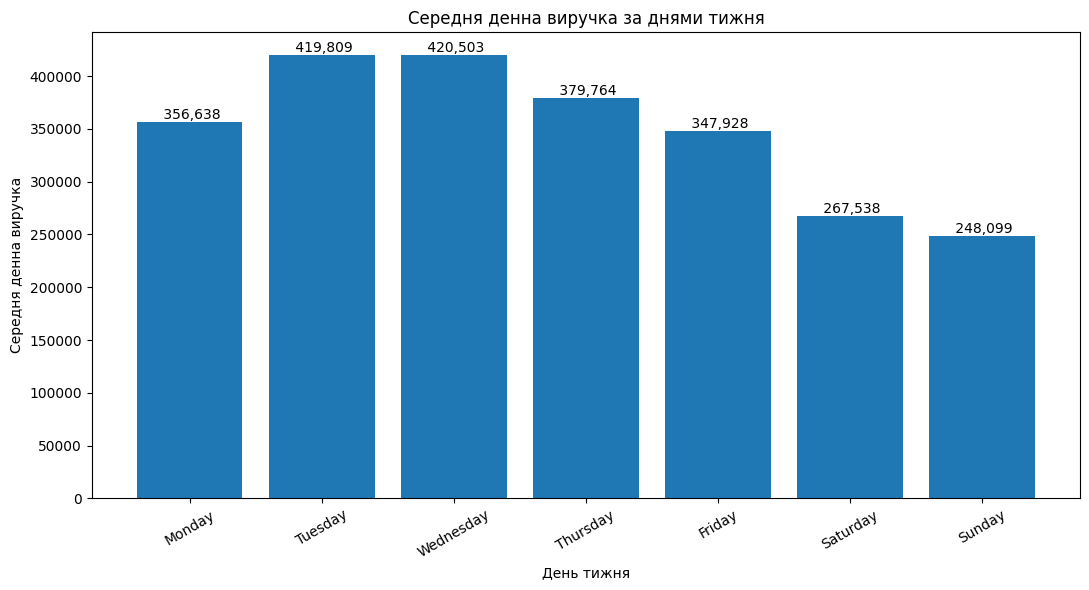

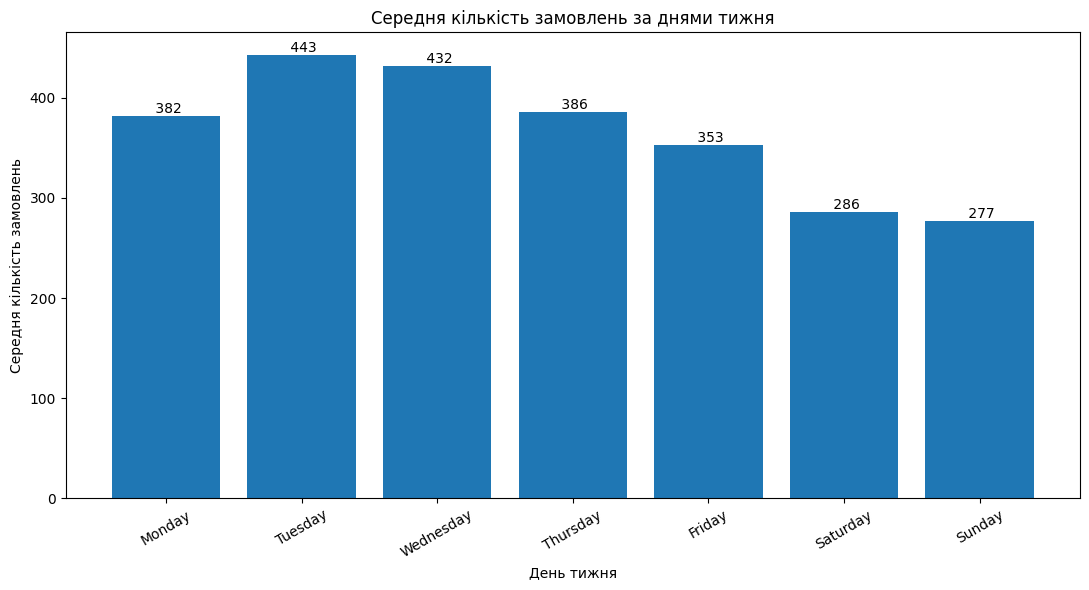

In [ ]:
# ============================================================
# ПУНКТ 2.3 — Аналіз продажів за днями тижня
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. Додаємо день тижня
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_sales_weekday = daily_sales.copy()

daily_sales_weekday["weekday"] = (
    daily_sales_weekday["session_date"]
    .dt.day_name()
)

daily_sales_weekday["weekday"] = pd.Categorical(
    daily_sales_weekday["weekday"],
    categories=weekday_order,
    ordered=True
)


# ============================================================
# 2. Агрегація
# ============================================================

weekday_sales = (
    daily_sales_weekday
    .groupby("weekday", observed=True)
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("orders", "sum"),
        average_daily_revenue=("revenue", "mean"),
        average_daily_orders=("orders", "mean"),
        days=("session_date", "count")
    )
    .reset_index()
)

weekday_sales["revenue_per_order"] = (
    weekday_sales["total_revenue"]
    / weekday_sales["total_orders"]
)


# ============================================================
# 3. Додаткові показники
# ============================================================

weekday_sales["revenue_share"] = (
    weekday_sales["total_revenue"]
    / weekday_sales["total_revenue"].sum()
    * 100
)

weekday_sales["vs_average_day_pct"] = (
    weekday_sales["average_daily_revenue"]
    / daily_sales["revenue"].mean()
    - 1
) * 100


# ============================================================
# 4. Результат
# ============================================================

print("=== SALES BY DAY OF WEEK ===")

display(
    weekday_sales.style.format({
        "total_revenue": "{:,.2f}",
        "total_orders": "{:,}",
        "average_daily_revenue": "{:,.2f}",
        "average_daily_orders": "{:,.0f}",
        "revenue_per_order": "{:,.2f}",
        "revenue_share": "{:.2f}%",
        "vs_average_day_pct": "{:+.2f}%"
    })
)


# ============================================================
# 5. Візуалізація — середня денна виручка
# ============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    weekday_sales["weekday"],
    weekday_sales["average_daily_revenue"]
)

plt.title("Середня денна виручка за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Середня денна виручка")

for i, value in enumerate(
    weekday_sales["average_daily_revenue"]
):
    plt.text(
        i,
        value,
        f" {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Візуалізація — середня кількість замовлень
# ============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    weekday_sales["weekday"],
    weekday_sales["average_daily_orders"]
)

plt.title("Середня кількість замовлень за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Середня кількість замовлень")

for i, value in enumerate(
    weekday_sales["average_daily_orders"]
):
    plt.text(
        i,
        value,
        f" {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Аналіз продажів за днями тижня показує, що найвищі середні показники спостерігаються **у вівторок та середу** — близько **420 тис. виручки на день**, що приблизно на **21% вище** за загальний середній денний рівень. У четвер середня виручка також перевищує загальний середній показник і становить близько **380 тис.**

Аналогічна тенденція спостерігається за кількістю замовлень: **вівторок–четвер** мають найбільшу середню кількість покупок, тоді як вихідні характеризуються значно нижчою активністю.

Найнижчі результати припадають на **суботу та неділю**: середня денна виручка становить близько **268 тис.** та **248 тис.** відповідно, що приблизно на **23% та 29% нижче** за загальний середній денний рівень.

Отже, продажі мають виражену **календарну залежність**: середина робочого тижня є найактивнішим періодом як за виручкою, так і за кількістю замовлень, тоді як вихідні характеризуються найнижчою активністю. Цю закономірність можна враховувати під час планування рекламних активностей, промоакцій та розподілу маркетингового бюджету.


=== MONTHLY SALES DYNAMICS BY TRAFFIC CHANNEL ===


,month,traffic_channel,revenue,orders,revenue_per_order,revenue_change_pct
0,2020-11,Direct,"2,329,210.40","2,459",947.22,+nan%
1,2020-11,Organic Search,"3,418,081.10","3,577",955.57,+nan%
2,2020-11,Paid Search,"2,550,497.80","2,786",915.47,+nan%
3,2020-11,Social Search,"805,664.20",905,890.24,+nan%
4,2020-11,Undefined,"794,061.50",813,976.71,+nan%
5,2020-12,Direct,"2,802,138.40","2,962",946.03,+20.30%
6,2020-12,Organic Search,"4,539,423.70","4,654",975.38,+32.81%
7,2020-12,Paid Search,"3,271,694.70","3,488",937.99,+28.28%
8,2020-12,Social Search,"1,040,559.00","1,066",976.13,+29.16%
9,2020-12,Undefined,"769,623.50",733,"1,049.96",-3.08%



=== TOTAL SALES BY TRAFFIC CHANNEL ===


,traffic_channel,revenue,orders,revenue_share,revenue_per_order
1,Organic Search,"11,433,151.60","11,921",35.76%,959.08
2,Paid Search,"8,511,049.40","9,042",26.62%,941.28
0,Direct,"7,494,923.40","7,800",23.44%,960.89
3,Social Search,"2,532,105.70","2,716",7.92%,932.29
4,Undefined,"2,000,501.00","2,059",6.26%,971.59


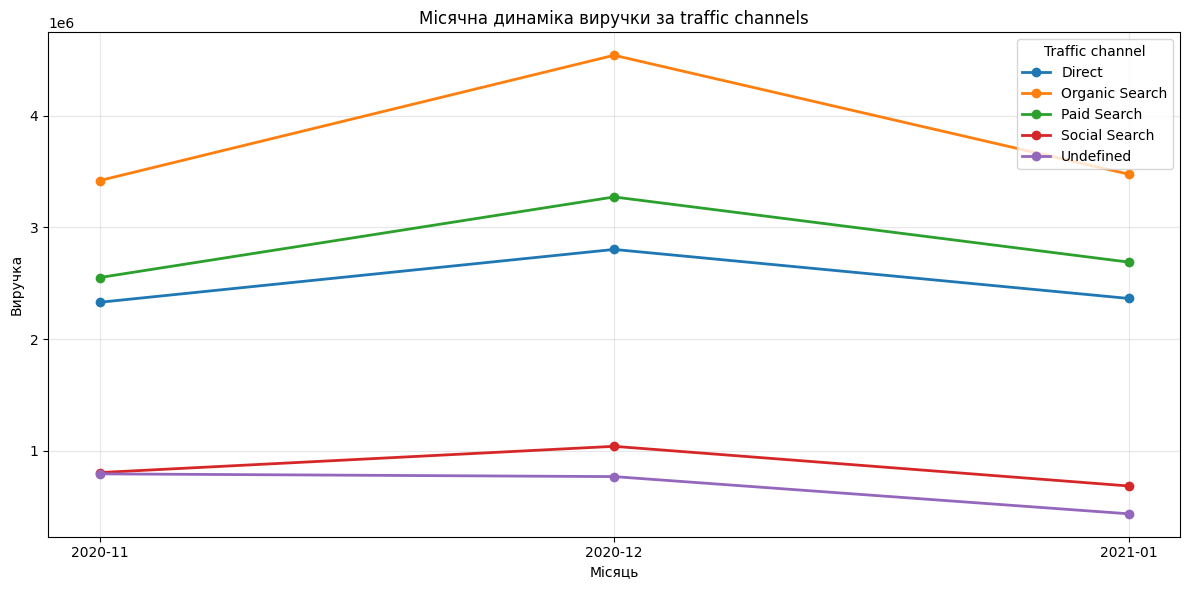

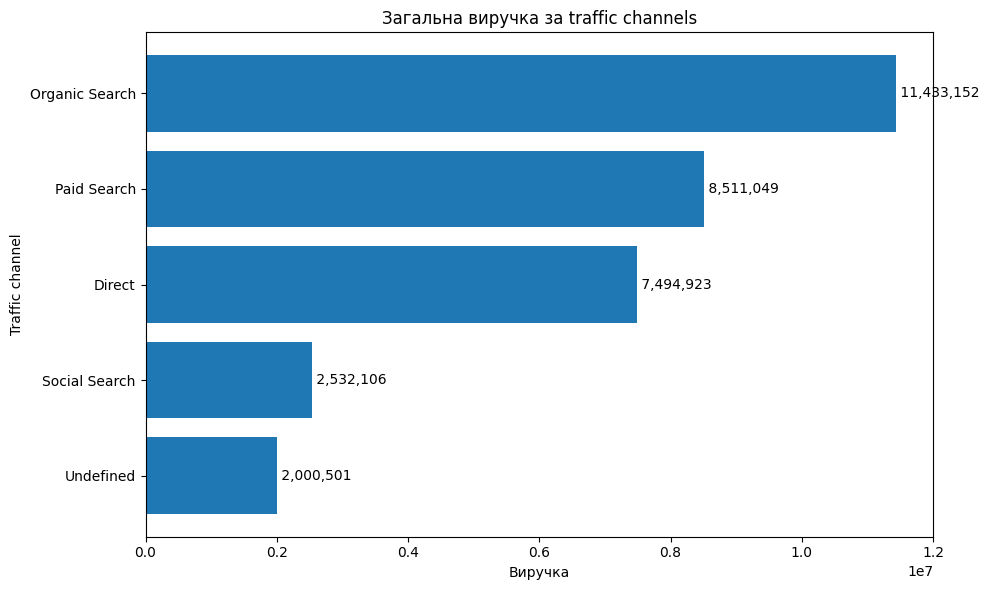

In [ ]:
# ============================================================
# ПУНКТ 2.4 — Динаміка продажів за traffic channels
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. Місяць для кожної покупки
# ============================================================

channel_monthly_sales = (
    sales_df
    .assign(
        month=lambda x: (
            x["session_date"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(["month", "traffic_channel"])
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

channel_monthly_sales["revenue_per_order"] = (
    channel_monthly_sales["revenue"]
    / channel_monthly_sales["orders"]
)


# ============================================================
# 2. MoM-зміна revenue всередині кожного каналу
# ============================================================

channel_monthly_sales["revenue_change_pct"] = (
    channel_monthly_sales
    .groupby("traffic_channel")["revenue"]
    .pct_change()
    * 100
)


# ============================================================
# 3. Загальна виручка за каналами
# ============================================================

channel_total_sales = (
    sales_df
    .groupby("traffic_channel")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

channel_total_sales["revenue_share"] = (
    channel_total_sales["revenue"]
    / channel_total_sales["revenue"].sum()
    * 100
)

channel_total_sales["revenue_per_order"] = (
    channel_total_sales["revenue"]
    / channel_total_sales["orders"]
)


# ============================================================
# 4. Результати
# ============================================================

print("=== MONTHLY SALES DYNAMICS BY TRAFFIC CHANNEL ===")

display(
    channel_monthly_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_per_order": "{:,.2f}",
        "revenue_change_pct": "{:+.2f}%"
    })
)


print("\n=== TOTAL SALES BY TRAFFIC CHANNEL ===")

display(
    channel_total_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)


# ============================================================
# 5. Візуалізація — місячна динаміка виручки каналів
# ============================================================

channel_monthly_pivot = (
    channel_monthly_sales
    .pivot(
        index="month",
        columns="traffic_channel",
        values="revenue"
    )
)

plt.figure(figsize=(12, 6))

for channel in channel_monthly_pivot.columns:
    plt.plot(
        channel_monthly_pivot.index,
        channel_monthly_pivot[channel],
        marker="o",
        linewidth=2,
        label=channel
    )

plt.title("Місячна динаміка виручки за traffic channels")
plt.xlabel("Місяць")
plt.ylabel("Виручка")
plt.legend(title="Traffic channel")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Візуалізація — загальна виручка за каналами
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    channel_total_sales["traffic_channel"],
    channel_total_sales["revenue"]
)

plt.title("Загальна виручка за traffic channels")
plt.xlabel("Виручка")
plt.ylabel("Traffic channel")

plt.gca().invert_yaxis()

for i, value in enumerate(channel_total_sales["revenue"]):
    plt.text(
        value,
        i,
        f" {value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()



Аналіз продажів за traffic channels показує, що найбільшу виручку за весь досліджуваний період **листопад 2020 — січень 2021** генерує **Organic — 11.43 млн**, або **35.76%** загальної виручки. Друге місце займає **Paid — 8.51 млн (26.62%)**, а третє — **Direct — 7.50 млн (23.44%)**. Разом ці три канали формують **85.82%** усієї виручки.

У **грудні 2020 року порівняно з листопадом 2020 року** виручка зросла майже за всіма каналами. Найбільший приріст продемонстрував **Organic — +32.81%**, далі **Social — +29.16%** та **Paid — +28.28%**. Водночас у **Undefined** виручка зменшилася на **3.08%** порівняно з листопадом.

У **січні 2021 року порівняно з груднем 2020 року** виручка знизилася за всіма каналами. Найбільше падіння відбулося в **Undefined — −43.24%** та **Social — −34.09%**, тоді як найменше зниження було в **Direct — −15.65%**.

Отже, **Organic є основним каналом за внеском у виручку** та має найбільший абсолютний результат за весь період. Основні канали — Organic, Paid та Direct — формують переважну частину продажів, тому саме їхня динаміка найбільше впливає на загальний результат магазину. Водночас різке зниження Social та Undefined у січні 2021 року порівняно з груднем 2020 року може бути сигналом для додаткової перевірки стабільності цих каналів.

=== MONTHLY SALES DYNAMICS BY DEVICE ===


,month,device,revenue,orders,revenue_per_order,revenue_change_pct
0,2020-11,desktop,"5,850,944.80","6,240",937.65,+nan%
1,2020-11,mobile,"3,838,041.60","4,092",937.94,+nan%
2,2020-11,tablet,"208,528.60",208,"1,002.54",+nan%
3,2020-12,desktop,"7,320,168.10","7,557",968.66,+25.11%
4,2020-12,mobile,"4,776,983.70","5,041",947.63,+24.46%
5,2020-12,tablet,"326,287.50",305,"1,069.80",+56.47%
6,2021-01,desktop,"5,692,926.10","5,905",964.09,-22.23%
7,2021-01,mobile,"3,769,200.50","3,980",947.04,-21.10%
8,2021-01,tablet,"188,650.20",210,898.33,-42.18%



=== TOTAL SALES BY DEVICE ===


,device,revenue,orders,revenue_share,revenue_per_order
0,desktop,"18,864,039.00","19,702",59.00%,957.47
1,mobile,"12,384,225.80","13,113",38.73%,944.42
2,tablet,"723,466.30",723,2.26%,"1,000.64"


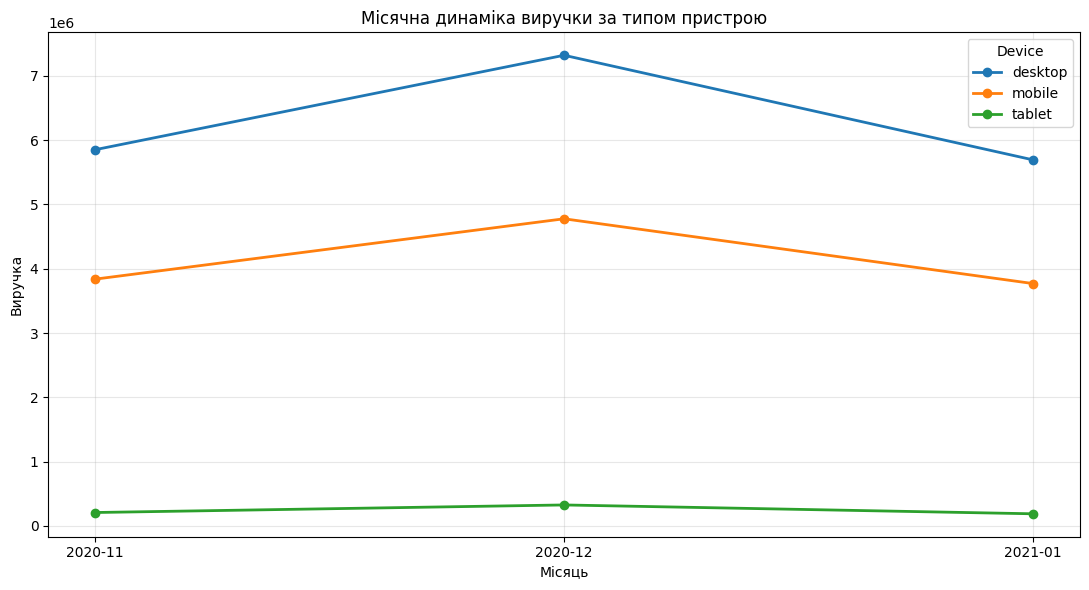

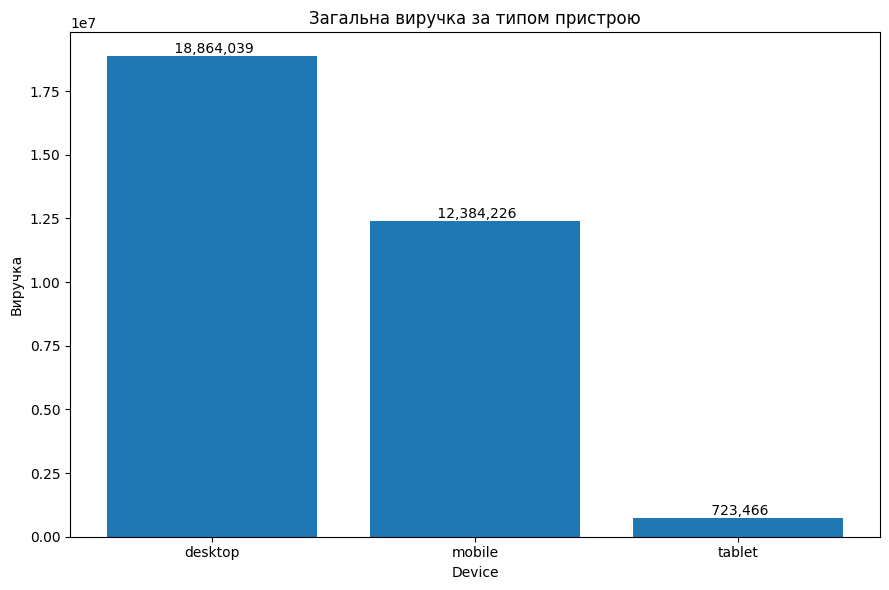

In [ ]:
# ============================================================
# ПУНКТ 2.5 — Динаміка продажів за типом пристрою
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. Місячна динаміка за device
# ============================================================

device_monthly_sales = (
    sales_df
    .assign(
        month=lambda x: (
            x["session_date"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(["month", "device"])
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
)

device_monthly_sales["revenue_per_order"] = (
    device_monthly_sales["revenue"]
    / device_monthly_sales["orders"]
)


# ============================================================
# 2. MoM-зміна revenue всередині кожного device
# ============================================================

device_monthly_sales["revenue_change_pct"] = (
    device_monthly_sales
    .groupby("device")["revenue"]
    .pct_change()
    * 100
)


# ============================================================
# 3. Загальна динаміка за device
# ============================================================

device_total_sales = (
    sales_df
    .groupby("device")
    .agg(
        revenue=("price", "sum"),
        orders=("session_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

device_total_sales["revenue_share"] = (
    device_total_sales["revenue"]
    / device_total_sales["revenue"].sum()
    * 100
)

device_total_sales["revenue_per_order"] = (
    device_total_sales["revenue"]
    / device_total_sales["orders"]
)


# ============================================================
# 4. Результати
# ============================================================

print("=== MONTHLY SALES DYNAMICS BY DEVICE ===")

display(
    device_monthly_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_per_order": "{:,.2f}",
        "revenue_change_pct": "{:+.2f}%"
    })
)


print("\n=== TOTAL SALES BY DEVICE ===")

display(
    device_total_sales.style.format({
        "revenue": "{:,.2f}",
        "orders": "{:,}",
        "revenue_share": "{:.2f}%",
        "revenue_per_order": "{:,.2f}"
    })
)


# ============================================================
# 5. Візуалізація — місячна динаміка виручки за device
# ============================================================

device_monthly_pivot = (
    device_monthly_sales
    .pivot(
        index="month",
        columns="device",
        values="revenue"
    )
)

plt.figure(figsize=(11, 6))

for device in device_monthly_pivot.columns:
    plt.plot(
        device_monthly_pivot.index,
        device_monthly_pivot[device],
        marker="o",
        linewidth=2,
        label=device
    )

plt.title("Місячна динаміка виручки за типом пристрою")
plt.xlabel("Місяць")
plt.ylabel("Виручка")
plt.legend(title="Device")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Візуалізація — загальна виручка за device
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    device_total_sales["device"],
    device_total_sales["revenue"]
)

plt.title("Загальна виручка за типом пристрою")
plt.xlabel("Device")
plt.ylabel("Виручка")

for i, value in enumerate(device_total_sales["revenue"]):
    plt.text(
        i,
        value,
        f" {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


Аналіз динаміки продажів за типами пристроїв показує, що протягом усього періоду **desktop** є основним джерелом виручки — **18.86 млн (59.00%)**, тоді як **mobile** генерує **12.38 млн (38.73%)**, а **tablet** — лише **0.72 млн (2.26%)**. Таким чином, desktop та mobile разом формують **97.73%** загальної виручки.

У **грудні 2020 року порівняно з листопадом 2020 року** виручка зросла на всіх типах пристроїв. Найбільший приріст продемонстрував **tablet — +56.47%**, тоді як **desktop** зріс на **25.11%**, а **mobile** — на **24.46%**. Водночас високий темп зростання tablet варто трактувати обережно через його невелику частку в загальній виручці.

У **січні 2021 року порівняно з груднем 2020 року** виручка знизилася на всіх пристроях. Найбільше падіння спостерігалося у **tablet — −42.18%**, тоді як **desktop** знизився на **22.23%**, а **mobile** — на **21.10%**.

Отже, основний обсяг продажів магазину забезпечують **desktop та mobile**, причому їхня динаміка протягом періоду є досить схожою. **Tablet** має найменший внесок у загальну виручку та найбільшу відносну волатильність. Тому основний фокус бізнесу доцільно зберігати на desktop та mobile, а tablet розглядати як невеликий сегмент із потенціалом для окремого дослідження.


In [ ]:
# ============================================================
# ФІНАЛЬНА ПЕРЕВІРКА ПУНКТУ 2
# Перевіряємо, що всі основні розрізи revenue сходяться
# із загальною виручкою
# ============================================================

# ------------------------------------------------------------
# 1. Еталонна загальна виручка
# ------------------------------------------------------------

total_revenue = sales_df["price"].sum()

print(f"Загальна виручка: {total_revenue:,.2f}")


# ------------------------------------------------------------
# 2. Перевірка за місяцями
# ------------------------------------------------------------

revenue_by_month = (
    sales_df
    .groupby(sales_df["session_date"].dt.to_period("M"))
    ["price"]
    .sum()
)

month_total = revenue_by_month.sum()

print("\n=== ПЕРЕВІРКА ЗА МІСЯЦЯМИ ===")
print(f"Revenue за місяцями: {month_total:,.2f}")
print(f"Різниця: {month_total - total_revenue:,.2f}")


# ------------------------------------------------------------
# 3. Перевірка за континентами
# ------------------------------------------------------------

revenue_by_continent = (
    sales_df
    .groupby("continent")["price"]
    .sum()
)

continent_total = revenue_by_continent.sum()

print("\n=== ПЕРЕВІРКА ЗА КОНТИНЕНТАМИ ===")
print(f"Revenue за континентами: {continent_total:,.2f}")
print(f"Різниця: {continent_total - total_revenue:,.2f}")


# ------------------------------------------------------------
# 4. Перевірка за traffic channels
# ------------------------------------------------------------

revenue_by_channel = (
    sales_df
    .groupby("traffic_channel")["price"]
    .sum()
)

channel_total = revenue_by_channel.sum()

print("\n=== ПЕРЕВІРКА ЗА TRAFFIC CHANNELS ===")
print(f"Revenue за traffic channels: {channel_total:,.2f}")
print(f"Різниця: {channel_total - total_revenue:,.2f}")


# ------------------------------------------------------------
# 5. Перевірка за device
# ------------------------------------------------------------

revenue_by_device = (
    sales_df
    .groupby("device")["price"]
    .sum()
)

device_total = revenue_by_device.sum()

print("\n=== ПЕРЕВІРКА ЗА DEVICE ===")
print(f"Revenue за device: {device_total:,.2f}")
print(f"Різниця: {device_total - total_revenue:,.2f}")


# ------------------------------------------------------------
# 6. Автоматичний контроль
# ------------------------------------------------------------

checks = {
    "Місяці": month_total,
    "Континенти": continent_total,
    "Traffic channels": channel_total,
    "Device": device_total
}

print("\n=== ФІНАЛЬНИЙ РЕЗУЛЬТАТ ===")

for dimension, value in checks.items():
    difference = value - total_revenue

    if abs(difference) < 0.01:
        print(f"✅ {dimension}: OK")
    else:
        print(
            f"❌ {dimension}: РОЗБІЖНІСТЬ "
            f"{difference:,.2f}"
        )

Загальна виручка: 31,971,731.10

=== ПЕРЕВІРКА ЗА МІСЯЦЯМИ ===
Revenue за місяцями: 31,971,731.10
Різниця: 0.00

=== ПЕРЕВІРКА ЗА КОНТИНЕНТАМИ ===
Revenue за континентами: 31,971,731.10
Різниця: -0.00

=== ПЕРЕВІРКА ЗА TRAFFIC CHANNELS ===
Revenue за traffic channels: 31,971,731.10
Різниця: -0.00

=== ПЕРЕВІРКА ЗА DEVICE ===
Revenue за device: 31,971,731.10
Різниця: 0.00

=== ФІНАЛЬНИЙ РЕЗУЛЬТАТ ===
✅ Місяці: OK
✅ Континенти: OK
✅ Traffic channels: OK
✅ Device: OK


In [ ]:
# ============================================================
# ПУНКТ 3.1 — Sessions за Traffic Channel × Device
# ============================================================

# ------------------------------------------------------------
# 1. Перевіряємо значення перед побудовою pivot
# ------------------------------------------------------------

print("=== TRAFFIC CHANNELS ===")
print(df["traffic_channel"].value_counts(dropna=False))

print("\n=== DEVICES ===")
print(df["device"].value_counts(dropna=False))


# ------------------------------------------------------------
# 2. Виключаємо Unknown / невизначені значення
# ------------------------------------------------------------

sessions_pivot_data = df[
    df["traffic_channel"].notna()
    & df["device"].notna()
    & ~df["traffic_channel"].isin(["Unknown", "Undefined"])
    & ~df["device"].isin(["Unknown", "Undefined"])
].copy()


# ------------------------------------------------------------
# 3. Будуємо pivot table
# ------------------------------------------------------------

sessions_pivot = pd.pivot_table(
    sessions_pivot_data,
    index="traffic_channel",
    columns="device",
    values="session_id",
    aggfunc="nunique",
    fill_value=0
)


# ------------------------------------------------------------
# 4. Додаємо Total
# ------------------------------------------------------------

sessions_pivot["Total"] = sessions_pivot.sum(axis=1)

sessions_pivot.loc["Total"] = sessions_pivot.sum(axis=0)


# ------------------------------------------------------------
# 5. Виводимо результат
# ------------------------------------------------------------

print("\n=== SESSIONS BY TRAFFIC CHANNEL × DEVICE ===")

display(sessions_pivot)

=== TRAFFIC CHANNELS ===
traffic_channel
Organic Search    124425
Paid Search        94341
Direct             81382
Social Search      27914
Undefined          21483
Name: count, dtype: int64

=== DEVICES ===
device
desktop    204429
mobile     137267
tablet       7849
Name: count, dtype: int64

=== SESSIONS BY TRAFFIC CHANNEL × DEVICE ===


device,desktop,mobile,tablet,Total
traffic_channel,,,,
Direct,47825,31745,1812,81382
Organic Search,72622,49014,2789,124425
Paid Search,55167,37034,2140,94341
Social Search,16288,10988,638,27914
Total,191902,128781,7379,328062


Після виключення сесій із невизначеним traffic channel у аналізі залишилося 328,062 сесії. Desktop є домінуючим типом пристрою — 58.50% сесій, mobile формує 39.25%, а tablet лише 2.25%. Organic Search є найбільшим traffic channel із 124,425 сесіями, причому найбільша окрема комбінація — Organic Search × Desktop (72,622 сесії). Загалом структура показує, що основний обсяг трафіку формується через Organic Search та припадає на desktop і mobile.

In [ ]:
# ============================================================
# ПУНКТ 3.2 — Top-10 категорій × Top-5 країн
# ============================================================

# ------------------------------------------------------------
# 1. Знаходимо Top-5 країн за revenue
# ------------------------------------------------------------

top_5_countries = (
    sales_df
    .groupby("country")["price"]
    .sum()
    .nlargest(5)
    .index
    .tolist()
)


# ------------------------------------------------------------
# 2. Знаходимо Top-10 категорій за revenue
# ------------------------------------------------------------

top_10_categories = (
    sales_df
    .groupby("product_category")["price"]
    .sum()
    .nlargest(10)
    .index
    .tolist()
)


# ------------------------------------------------------------
# 3. Фільтруємо тільки потрібні країни та категорії
# ------------------------------------------------------------

pivot_data = sales_df[
    sales_df["country"].isin(top_5_countries)
    & sales_df["product_category"].isin(top_10_categories)
].copy()


# ------------------------------------------------------------
# 4. Створюємо Pivot Table
# ------------------------------------------------------------

category_country_pivot = pd.pivot_table(
    pivot_data,
    index="product_category",
    columns="country",
    values="price",
    aggfunc="sum",
    fill_value=0
)


# ------------------------------------------------------------
# 5. Сортуємо категорії за загальним revenue
# ------------------------------------------------------------

category_country_pivot["Total"] = category_country_pivot.sum(axis=1)

category_country_pivot = (
    category_country_pivot
    .sort_values("Total", ascending=False)
)


# ------------------------------------------------------------
# 6. Додаємо Total по країнах
# ------------------------------------------------------------

category_country_pivot.loc["Total"] = (
    category_country_pivot.sum(axis=0)
)


# ------------------------------------------------------------
# 7. Виводимо результати
# ------------------------------------------------------------

print("=== TOP-5 COUNTRIES BY REVENUE ===")
print(top_5_countries)

print("\n=== TOP-10 CATEGORIES BY REVENUE ===")
print(top_10_categories)

print("\n=== REVENUE: TOP-10 CATEGORIES × TOP-5 COUNTRIES ===")

display(
    category_country_pivot.style.format("{:,.2f}")
)

=== TOP-5 COUNTRIES BY REVENUE ===
['United States', 'India', 'Canada', 'United Kingdom', 'France']

=== TOP-10 CATEGORIES BY REVENUE ===
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]

=== REVENUE: TOP-10 CATEGORIES × TOP-5 COUNTRIES ===


country,Canada,France,India,United Kingdom,United States,Total
product_category,,,,,,
Sofas & armchairs,"692,427.50","187,735.00","788,430.00","234,812.00","3,707,144.50","5,610,549.00"
Chairs,"417,740.80","134,029.40","544,309.20","188,519.40","2,619,773.80","3,904,372.60"
Beds,"354,772.00","116,414.00","358,319.50","133,816.00","2,213,058.00","3,176,379.50"
Bookcases & shelving units,"278,981.90","73,830.00","364,507.40","113,987.60","1,567,606.90","2,398,913.80"
Cabinets & cupboards,"181,802.00","59,101.50","191,888.00","71,684.50","994,545.50","1,499,021.50"
Outdoor furniture,"185,322.80","40,486.40","162,289.40","57,002.40","929,245.20","1,374,346.20"
Tables & desks,"132,678.00","42,299.00","186,157.50","49,374.00","777,865.00","1,188,373.50"
Chests of drawers & drawer units,"71,952.00","21,544.50","73,111.00","36,784.00","382,388.00","585,779.50"
Bar furniture,"51,724.00","11,199.00","57,657.00","22,103.00","330,805.00","473,488.00"


In [ ]:
# ============================================================
# ПЕРЕВІРКА PIVOT 3.2
# ============================================================

# Revenue, який має бути представлений у pivot:
expected_pivot_revenue = pivot_data["price"].sum()

# Revenue із Total у pivot
pivot_total_revenue = category_country_pivot.loc["Total", "Total"]

print("=== ПЕРЕВІРКА REVENUE ===")
print(f"Revenue у відфільтрованих даних: {expected_pivot_revenue:,.2f}")
print(f"Revenue у Pivot Total:        {pivot_total_revenue:,.2f}")
print(f"Різниця:                      {pivot_total_revenue - expected_pivot_revenue:,.2f}")

# Частка цього перетину від загальної revenue
share_of_total = (
    expected_pivot_revenue
    / total_revenue
    * 100
)

print(f"\nЧастка від загальної revenue: {share_of_total:.2f}%")

# Перевірка рядків
row_check = (
    category_country_pivot.drop(index="Total")["Total"].sum()
)

print("\n=== ПЕРЕВІРКА РЯДКІВ ===")
print(f"Сума Total по категоріях: {row_check:,.2f}")
print(f"Різниця: {row_check - expected_pivot_revenue:,.2f}")

# Перевірка колонок
column_check = (
    category_country_pivot.loc["Total"].drop("Total").sum()
)

print("\n=== ПЕРЕВІРКА КОЛОНОК ===")
print(f"Сума Total по країнах: {column_check:,.2f}")
print(f"Різниця: {column_check - expected_pivot_revenue:,.2f}")

=== ПЕРЕВІРКА REVENUE ===
Revenue у відфільтрованих даних: 20,515,845.60
Revenue у Pivot Total:        20,515,845.60
Різниця:                      -0.00

Частка від загальної revenue: 64.17%

=== ПЕРЕВІРКА РЯДКІВ ===
Сума Total по категоріях: 20,515,845.60
Різниця: -0.00

=== ПЕРЕВІРКА КОЛОНОК ===
Сума Total по країнах: 20,515,845.60
Різниця: -0.00


Аналіз Top-10 категорій у Top-5 країнах показав високу концентрацію продажів: ці категорії та ринки разом формують 20.52 млн, або 64.17% загальної виручки. США є беззаперечним лідером за revenue в усіх Top-10 категоріях, а найбільший внесок забезпечує категорія Sofas & armchairs. Це свідчить про значну концентрацію виручки навколо ключового ринку та найбільш прибуткових товарних категорій.

In [ ]:
# ============================================================
# ПУНКТ 3.3 — Registered / Unregistered × Traffic Channel
# ============================================================

# ------------------------------------------------------------
# 1. Створюємо зрозумілий статус користувача
# ------------------------------------------------------------

registered_channel_data = df.copy()

registered_channel_data["user_status"] = np.where(
    registered_channel_data["registered_user_id"].notna(),
    "Registered",
    "Unregistered"
)


# ------------------------------------------------------------
# 2. Створюємо ознаку замовлення
# ------------------------------------------------------------

registered_channel_data["has_order"] = (
    registered_channel_data["price"].notna()
)


# ------------------------------------------------------------
# 3. Pivot: sessions за статусом та traffic channel
# ------------------------------------------------------------

sessions_pivot_registered = pd.pivot_table(
    registered_channel_data,
    index="traffic_channel",
    columns="user_status",
    values="session_id",
    aggfunc="nunique",
    fill_value=0
)


# ------------------------------------------------------------
# 4. Pivot: orders за статусом та traffic channel
# ------------------------------------------------------------

orders_pivot_registered = pd.pivot_table(
    registered_channel_data[
        registered_channel_data["has_order"]
    ],
    index="traffic_channel",
    columns="user_status",
    values="session_id",
    aggfunc="nunique",
    fill_value=0
)


# ------------------------------------------------------------
# 5. Pivot: revenue за статусом та traffic channel
# ------------------------------------------------------------

revenue_pivot_registered = pd.pivot_table(
    registered_channel_data[
        registered_channel_data["has_order"]
    ],
    index="traffic_channel",
    columns="user_status",
    values="price",
    aggfunc="sum",
    fill_value=0
)


# ------------------------------------------------------------
# 6. Conversion rate
#    Orders / Sessions × 100
# ------------------------------------------------------------

conversion_pivot_registered = (
    orders_pivot_registered
    / sessions_pivot_registered
    * 100
)


# ------------------------------------------------------------
# 7. Виводимо всі результати
# ------------------------------------------------------------

print("=== SESSIONS: REGISTERED × TRAFFIC CHANNEL ===")

display(
    sessions_pivot_registered.style.format("{:,.0f}")
)


print("\n=== ORDERS: REGISTERED × TRAFFIC CHANNEL ===")

display(
    orders_pivot_registered.style.format("{:,.0f}")
)


print("\n=== REVENUE: REGISTERED × TRAFFIC CHANNEL ===")

display(
    revenue_pivot_registered.style.format("{:,.2f}")
)


print("\n=== CONVERSION RATE: REGISTERED × TRAFFIC CHANNEL ===")

display(
    conversion_pivot_registered.style.format("{:.2f}%")
)

=== SESSIONS: REGISTERED × TRAFFIC CHANNEL ===


user_status,Registered,Unregistered
traffic_channel,,
Direct,"6,514","74,868"
Organic Search,"10,035","114,390"
Paid Search,"7,467","86,874"
Social Search,"2,212","25,702"
Undefined,"1,717","19,766"



=== ORDERS: REGISTERED × TRAFFIC CHANNEL ===


user_status,Registered,Unregistered
traffic_channel,,
Direct,636,"7,164"
Organic Search,"1,016","10,905"
Paid Search,706,"8,336"
Social Search,238,"2,478"
Undefined,185,"1,874"



=== REVENUE: REGISTERED × TRAFFIC CHANNEL ===


user_status,Registered,Unregistered
traffic_channel,,
Direct,"608,937.20","6,885,986.20"
Organic Search,"934,329.50","10,498,822.10"
Paid Search,"640,799.60","7,870,249.80"
Social Search,"205,139.90","2,326,965.80"
Undefined,"193,312.30","1,807,188.70"



=== CONVERSION RATE: REGISTERED × TRAFFIC CHANNEL ===


user_status,Registered,Unregistered
traffic_channel,,
Direct,9.76%,9.57%
Organic Search,10.12%,9.53%
Paid Search,9.45%,9.60%
Social Search,10.76%,9.64%
Undefined,10.77%,9.48%


Розподіл сесій за статусом користувача та traffic channel показав, що зареєстровані користувачі становлять 27,945 сесій (7.99%), тоді як незареєстровані — 321,600 (92.01%). Registered users мають вищу conversion rate у 4 із 5 traffic channels, найбільша різниця спостерігається у Social Search (+1.12 п.п.) та Undefined (+1.29 п.п.). Винятком є Paid Search, де conversion rate незареєстрованих користувачів трохи вища (+0.15 п.п.). Водночас revenue розподілена майже пропорційно частці сесій: зареєстровані користувачі генерують 8.08% revenue, а незареєстровані — 91.92%. Отже, реєстрація може бути пов'язана з дещо вищою конверсією в більшості каналів, але на основі цього описового аналізу не можна стверджувати про статистично значущий або причинний ефект.

In [ ]:
# ============================================================
# ПУНКТ 3.4 — Top-10 категорій × User Status
# ============================================================

# ------------------------------------------------------------
# 1. Додаємо статус користувача
# ------------------------------------------------------------

category_user_data = sales_df.copy()

category_user_data["user_status"] = np.where(
    category_user_data["registered_user_id"].notna(),
    "Registered",
    "Unregistered"
)


# ------------------------------------------------------------
# 2. Визначаємо Top-10 категорій за загальним revenue
# ------------------------------------------------------------

top_10_categories = (
    category_user_data
    .groupby("product_category")["price"]
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

category_user_data = category_user_data[
    category_user_data["product_category"].isin(top_10_categories)
].copy()


# ------------------------------------------------------------
# 3. Revenue: Category × User Status
# ------------------------------------------------------------

category_user_revenue = pd.pivot_table(
    category_user_data,
    index="product_category",
    columns="user_status",
    values="price",
    aggfunc="sum",
    fill_value=0
)


# ------------------------------------------------------------
# 4. Orders: Category × User Status
# ------------------------------------------------------------

category_user_orders = pd.pivot_table(
    category_user_data,
    index="product_category",
    columns="user_status",
    values="session_id",
    aggfunc="nunique",
    fill_value=0
)


# ------------------------------------------------------------
# 5. Average Order Value
# ------------------------------------------------------------

category_user_aov = (
    category_user_revenue
    / category_user_orders
)


# ------------------------------------------------------------
# 6. Revenue share всередині кожного user status
# ------------------------------------------------------------

category_user_share = (
    category_user_revenue
    / category_user_revenue.sum(axis=0)
    * 100
)


# ------------------------------------------------------------
# 7. Додаємо Total та сортуємо категорії
# ------------------------------------------------------------

category_user_revenue["Total"] = category_user_revenue.sum(axis=1)

category_user_revenue = (
    category_user_revenue
    .sort_values("Total", ascending=False)
)

category_user_orders["Total"] = category_user_orders.sum(axis=1)

category_user_aov["Total"] = (
    category_user_revenue["Total"]
    / category_user_orders["Total"]
)

category_user_share["Total"] = (
    category_user_revenue["Total"]
    / category_user_revenue["Total"].sum()
    * 100
)


# ------------------------------------------------------------
# 8. Результати
# ------------------------------------------------------------

print("=== TOP-10 CATEGORIES ===")
print(top_10_categories)


print("\n=== REVENUE: CATEGORY × USER STATUS ===")

display(
    category_user_revenue.style.format("{:,.2f}")
)


print("\n=== ORDERS: CATEGORY × USER STATUS ===")

display(
    category_user_orders.style.format("{:,.0f}")
)


print("\n=== AVERAGE ORDER VALUE: CATEGORY × USER STATUS ===")

display(
    category_user_aov.style.format("{:,.2f}")
)


print("\n=== REVENUE SHARE WITHIN USER STATUS ===")

display(
    category_user_share.style.format("{:.2f}%")
)

=== TOP-10 CATEGORIES ===
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]

=== REVENUE: CATEGORY × USER STATUS ===


user_status,Registered,Unregistered,Total
product_category,,,
Sofas & armchairs,"660,456.00","7,727,798.50","8,388,254.50"
Chairs,"539,956.20","5,607,792.60","6,147,748.80"
Beds,"394,705.00","4,525,020.00","4,919,725.00"
Bookcases & shelving units,"275,509.60","3,365,308.50","3,640,818.10"
Cabinets & cupboards,"215,869.50","2,120,630.00","2,336,499.50"
Outdoor furniture,"143,694.20","1,998,528.00","2,142,222.20"
Tables & desks,"153,533.00","1,636,774.50","1,790,307.50"
Chests of drawers & drawer units,"57,988.00","848,574.50","906,562.50"
Bar furniture,"51,014.00","684,489.00","735,503.00"



=== ORDERS: CATEGORY × USER STATUS ===


user_status,Registered,Unregistered,Total
product_category,,,
Bar furniture,91,"1,001","1,092"
Beds,254,"2,672","2,926"
Bookcases & shelving units,631,"6,999","7,630"
Cabinets & cupboards,214,"2,104","2,318"
Chairs,499,"5,453","5,952"
Chests of drawers & drawer units,100,"1,352","1,452"
Children's furniture,155,"1,547","1,702"
Outdoor furniture,185,"2,044","2,229"
Sofas & armchairs,340,"3,961","4,301"



=== AVERAGE ORDER VALUE: CATEGORY × USER STATUS ===


user_status,Registered,Unregistered,Total
product_category,,,
Bar furniture,560.59,683.81,673.54
Beds,"1,553.96","1,693.50","1,681.38"
Bookcases & shelving units,436.62,480.83,477.17
Cabinets & cupboards,"1,008.74","1,007.90","1,007.98"
Chairs,"1,082.08","1,028.39","1,032.89"
Chests of drawers & drawer units,579.88,627.64,624.35
Children's furniture,324.10,269.85,274.79
Outdoor furniture,776.73,977.75,961.07
Sofas & armchairs,"1,942.52","1,950.97","1,950.30"



=== REVENUE SHARE WITHIN USER STATUS ===


user_status,Registered,Unregistered,Total
product_category,,,
Bar furniture,2.01%,2.37%,2.34%
Beds,15.52%,15.64%,15.63%
Bookcases & shelving units,10.83%,11.63%,11.57%
Cabinets & cupboards,8.49%,7.33%,7.42%
Chairs,21.23%,19.38%,19.53%
Chests of drawers & drawer units,2.28%,2.93%,2.88%
Children's furniture,1.98%,1.44%,1.49%
Outdoor furniture,5.65%,6.91%,6.81%
Sofas & armchairs,25.97%,26.71%,26.65%


Порівняння товарної структури Registered та Unregistered користувачів показало, що їхня поведінка загалом схожа, але в окремих категоріях спостерігаються помітні відмінності. Найбільша частка revenue серед Registered припадає на Sofas & armchairs (25.97%) та Chairs (21.23%), причому частка Chairs у Registered на 1.85 п.п. вища, ніж у Unregistered. Також Registered мають більшу частку revenue у Cabinets & cupboards (+1.16 п.п.) та Children's furniture (+0.54 п.п.). Водночас Unregistered мають вищу частку у Sofas & armchairs, Outdoor furniture та Bookcases & shelving units. Середній чек також відрізняється залежно від категорії: для Children's furniture AOV Registered вищий приблизно на 20%, а для Outdoor furniture — приблизно на 21% нижчий. Отже, відмінності між Registered та Unregistered проявляються не стільки на рівні загальної revenue, скільки у структурі категорій та середній вартості замовлення.

# **Загальний висновок для пункту 3:**
Побудовані зведені таблиці дозволили детальніше дослідити структуру сесій, виручки та замовлень за ключовими сегментами. Аналіз Traffic Channel × Device показав, як розподіляються сесії між основними каналами та типами пристроїв, при цьому невизначені значення були виключені з цього аналізу для коректнішої інтерпретації. Зведена таблиця TOP-10 категорій × TOP-5 країн дозволила порівняти внесок ключових категорій у виручку провідних ринків та виявити відмінності у структурі продажів між країнами.

Додаткові pivot tables розширили аналіз поведінки користувачів. Порівняння Registered та Unregistered users за Traffic Channel дозволило одночасно оцінити кількість сесій, замовлень, виручку та conversion rate, а аналіз TOP-10 категорій за статусом користувача — порівняти виручку, кількість замовлень, середню виручку на замовлення та частку виручки.

Загалом зведені таблиці показали, що структура продажів залежить від поєднання географії, категорії товару, джерела трафіку, типу пристрою та статусу користувача. Використання кількох вимірів одночасно дозволяє отримати більш детальне розуміння бізнес-показників, ніж аналіз кожного параметра окремо, та створює основу для подальшого пошуку найбільш ефективних сегментів.


In [ ]:
# ============================================================
# ПУНКТ 4.1 — Кореляція між кількістю сесій та продажами
# ============================================================

from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 1. Агрегуємо дані на рівні дня
# ------------------------------------------------------------

daily_correlation = (
    df
    .groupby("session_date")
    .agg(
        sessions=("session_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
    .sort_values("session_date")
)


# ------------------------------------------------------------
# 2. Перевіряємо кількість спостережень
# ------------------------------------------------------------

print("=== DAILY CORRELATION DATA ===")

print(f"Кількість днів: {len(daily_correlation)}")
print(
    f"Період: "
    f"{daily_correlation['session_date'].min().date()} — "
    f"{daily_correlation['session_date'].max().date()}"
)

display(daily_correlation.head())


# ------------------------------------------------------------
# 3. Pearson correlation
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    daily_correlation["sessions"],
    daily_correlation["revenue"]
)


# ------------------------------------------------------------
# 4. Spearman correlation
# ------------------------------------------------------------

spearman_r, spearman_p = spearmanr(
    daily_correlation["sessions"],
    daily_correlation["revenue"]
)


# ------------------------------------------------------------
# 5. Результати
# ------------------------------------------------------------

print("\n=== CORRELATION RESULTS ===")

print(
    f"Pearson r = {pearson_r:.4f}, "
    f"p-value = {pearson_p:.6f}"
)

print(
    f"Spearman ρ = {spearman_r:.4f}, "
    f"p-value = {spearman_p:.6f}"
)

=== DAILY CORRELATION DATA ===
Кількість днів: 92
Період: 2020-11-01 — 2021-01-31


,session_date,sessions,revenue
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6



=== CORRELATION RESULTS ===
Pearson r = 0.7911, p-value = 0.000000
Spearman ρ = 0.8653, p-value = 0.000000


Між кількістю сесій та щоденною виручкою спостерігається сильний позитивний статистично значущий зв'язок: Pearson r = 0.7911 (p < 0.001), Spearman ρ = 0.8653 (p < 0.001). Це означає, що дні з більшою кількістю сесій загалом характеризуються вищою виручкою. Вищий коефіцієнт Spearman порівняно з Pearson свідчить про сильний монотонний зв'язок, який не повністю описується простою лінійною залежністю. Водночас кореляція не доводить причинно-наслідкового зв'язку.

TOP-3 continents by revenue:
['Americas', 'Asia', 'Europe']

Кількість календарних днів для аналізу: 92

Correlation results:


,Continent 1,Continent 2,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Americas,Asia,0.792025,5.409189e-21,0.709902,2.323380e-15
1,Americas,Europe,0.770586,2.671449e-19,0.672570,2.103559e-13
2,Asia,Europe,0.768427,3.864946e-19,0.657110,1.129095e-12


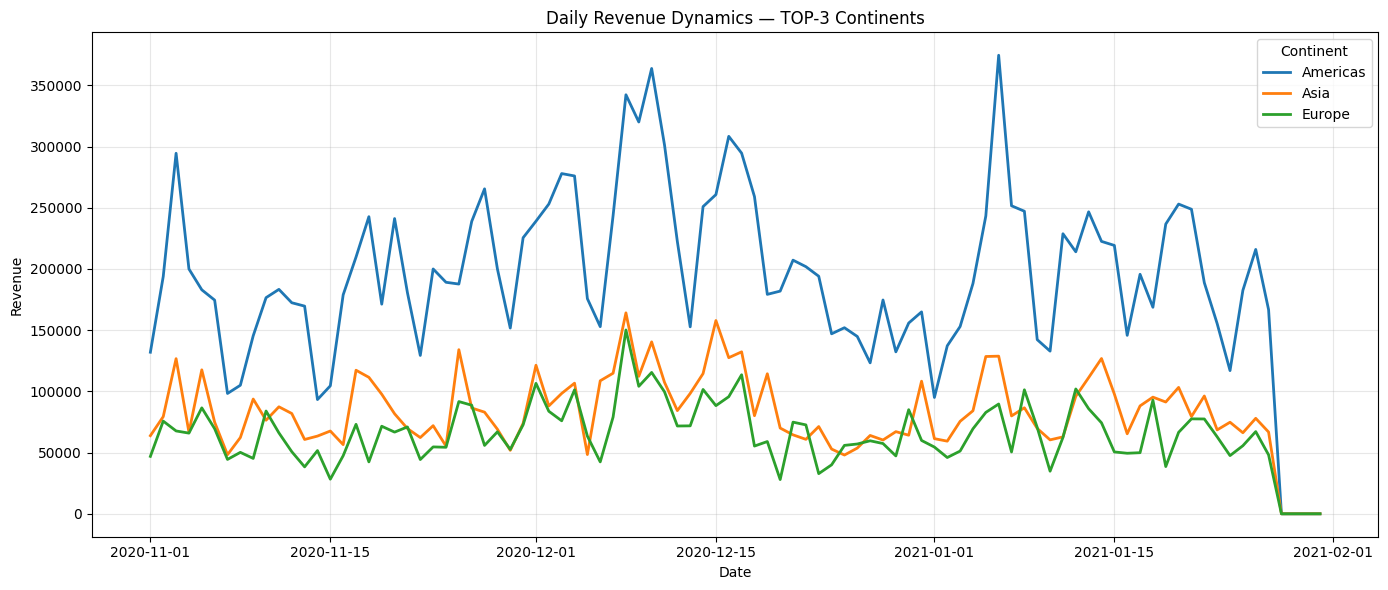

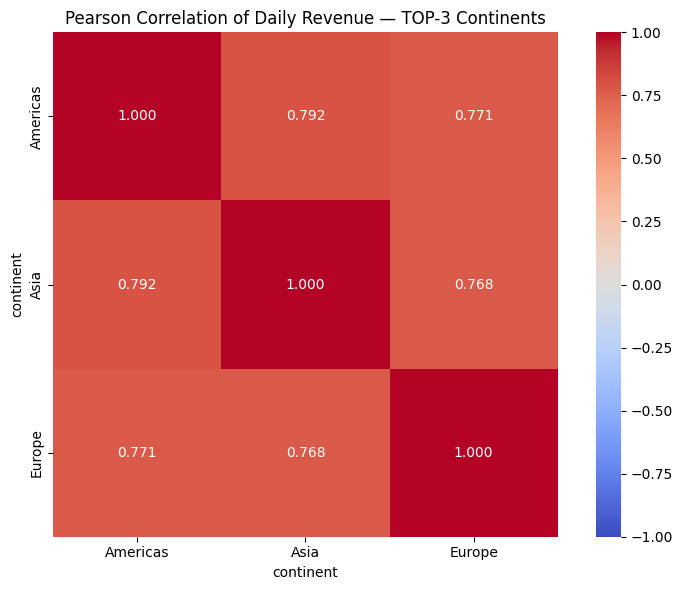


ВИСНОВОК:
Americas ↔ Asia: Pearson r = 0.7920, p = 0.000000; зв'язок статистично значущий.
Americas ↔ Europe: Pearson r = 0.7706, p = 0.000000; зв'язок статистично значущий.
Asia ↔ Europe: Pearson r = 0.7684, p = 0.000000; зв'язок статистично значущий.


In [ ]:
# ============================================================
# КРОК 4.2 — Кореляція виручки між TOP-3 континентами
# + візуалізація за всі 92 календарні дні
# ============================================================

from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

# ------------------------------------------------------------
# 2. TOP-3 континенти за загальною виручкою
# ------------------------------------------------------------

top_3_continents = (
    df.groupby("continent")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .index
      .tolist()
)

print("TOP-3 continents by revenue:")
print(top_3_continents)

# ------------------------------------------------------------
# 3. Щоденна виручка по TOP-3 континентах
# ------------------------------------------------------------

daily_continent_revenue = (
    df[df["continent"].isin(top_3_continents)]
    .groupby(["session_date", "continent"])["price"]
    .sum()
    .unstack(fill_value=0)
    .reindex(full_dates, fill_value=0)
)

daily_continent_revenue.index.name = "session_date"

# Переконуємося, що порядок колонок відповідає TOP-3
daily_continent_revenue = daily_continent_revenue[top_3_continents]

print(
    f"\nКількість календарних днів для аналізу: "
    f"{len(daily_continent_revenue)}"
)

# ------------------------------------------------------------
# 4. Pearson + Spearman correlation
# ------------------------------------------------------------

correlation_results = []

for i in range(len(top_3_continents)):
    for j in range(i + 1, len(top_3_continents)):

        continent_1 = top_3_continents[i]
        continent_2 = top_3_continents[j]

        x = daily_continent_revenue[continent_1]
        y = daily_continent_revenue[continent_2]

        # Pearson
        pearson_r, pearson_p = pearsonr(x, y)

        # Spearman
        spearman_rho, spearman_p = spearmanr(x, y)

        correlation_results.append({
            "Continent 1": continent_1,
            "Continent 2": continent_2,
            "Pearson r": pearson_r,
            "Pearson p-value": pearson_p,
            "Spearman rho": spearman_rho,
            "Spearman p-value": spearman_p
        })

correlation_results_df = pd.DataFrame(correlation_results)

print("\nCorrelation results:")
display(correlation_results_df)

# ------------------------------------------------------------
# 5. Візуалізація 1 — динаміка щоденної виручки
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

for continent in top_3_continents:
    plt.plot(
        daily_continent_revenue.index,
        daily_continent_revenue[continent],
        label=continent,
        linewidth=2
    )

plt.title("Daily Revenue Dynamics — TOP-3 Continents")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(title="Continent")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Візуалізація 2 — Pearson correlation heatmap
# ------------------------------------------------------------

import seaborn as sns

pearson_matrix = daily_continent_revenue.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Pearson Correlation of Daily Revenue — TOP-3 Continents")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Висновок
# ------------------------------------------------------------

print("\nВИСНОВОК:")

for _, row in correlation_results_df.iterrows():

    significance = (
        "статистично значущий"
        if row["Pearson p-value"] < 0.05
        else "статистично незначущий"
    )

    print(
        f"{row['Continent 1']} ↔ {row['Continent 2']}: "
        f"Pearson r = {row['Pearson r']:.4f}, "
        f"p = {row['Pearson p-value']:.6f}; "
        f"зв'язок {significance}."
    )

Аналіз щоденної виручки за 92 календарні дні показав сильний позитивний та статистично значущий взаємозв'язок між усіма TOP-3 континентами. Найсильніша кореляція спостерігається між Americas та Asia (Pearson r = 0.792), дещо слабша — між Americas та Europe (r = 0.771) та Asia та Europe (r = 0.768). Усі p-value значно менші за 0.05, тому нульову гіпотезу про відсутність лінійного зв'язку відхиляємо. Spearman correlation також підтверджує позитивний взаємозв'язок між регіонами. Це означає, що щоденні зміни виручки в основних регіонах мають тенденцію відбуватися синхронно. Водночас кореляція не означає причинно-наслідкового зв'язку: спільна динаміка може бути пов'язана із загальними факторами, такими як сезонні зміни попиту, маркетингові активності або загальна динаміка магазину.

In [ ]:
# ============================================================
# ПЕРЕВІРКА — Чому sales_df містить 88 днів замість 92?
# ============================================================

# Усі календарні дні в dataset
all_days = set(df["session_date"].dt.date)

# Дні, на яких були продажі в TOP-3 континентах
continent_days = set(
    sales_df[
        sales_df["continent"].isin(top_3_continents)
    ]["session_date"].dt.date
)

# Дні, яких не вистачає
missing_days = sorted(all_days - continent_days)

print("=== ПЕРЕВІРКА КІЛЬКОСТІ ДНІВ ===")
print(f"Усього днів у dataset: {len(all_days)}")
print(f"Днів із продажами TOP-3 континентів: {len(continent_days)}")
print(f"Відсутні дні: {len(missing_days)}")

print("\nДні без продажів у TOP-3 континентах:")
print(missing_days)

# ------------------------------------------------------------
# Перевіряємо, чи це дні без продажів взагалі
# ------------------------------------------------------------

sales_days = set(
    sales_df["session_date"].dt.date
)

missing_sales_days = sorted(all_days - sales_days)

print("\n=== ДНІ БЕЗ ЖОДНОГО ПРОДАЖУ ===")
print(f"Кількість: {len(missing_sales_days)}")
print(missing_sales_days)

=== ПЕРЕВІРКА КІЛЬКОСТІ ДНІВ ===
Усього днів у dataset: 92
Днів із продажами TOP-3 континентів: 88
Відсутні дні: 4

Дні без продажів у TOP-3 континентах:
[datetime.date(2021, 1, 28), datetime.date(2021, 1, 29), datetime.date(2021, 1, 30), datetime.date(2021, 1, 31)]

=== ДНІ БЕЗ ЖОДНОГО ПРОДАЖУ ===
Кількість: 4
[datetime.date(2021, 1, 28), datetime.date(2021, 1, 29), datetime.date(2021, 1, 30), datetime.date(2021, 1, 31)]


Traffic channels:
['Paid Search', 'Organic Search', 'Direct', 'Undefined', 'Social Search']

Кількість календарних днів для аналізу: 92


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
session_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4



Correlation results:


,Channel 1,Channel 2,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Paid Search,Organic Search,0.870086,2.142003e-29,0.793381,4.161837e-21
1,Paid Search,Direct,0.814072,5.896435e-23,0.729369,1.654022e-16
2,Paid Search,Undefined,0.521961,9.509609e-08,0.556491,8.421903e-09
3,Paid Search,Social Search,0.596428,3.532284e-10,0.492725,6.058888e-07
4,Organic Search,Direct,0.837833,2.190420e-25,0.779663,5.405254e-20
5,Organic Search,Undefined,0.526068,7.228214e-08,0.524677,7.935218e-08
6,Organic Search,Social Search,0.583117,1.066192e-09,0.461543,3.645214e-06
7,Direct,Undefined,0.517505,1.275436e-07,0.556922,8.156167e-09
8,Direct,Social Search,0.604060,1.831889e-10,0.469342,2.365556e-06
9,Undefined,Social Search,0.455126,5.161928e-06,0.462530,3.453229e-06


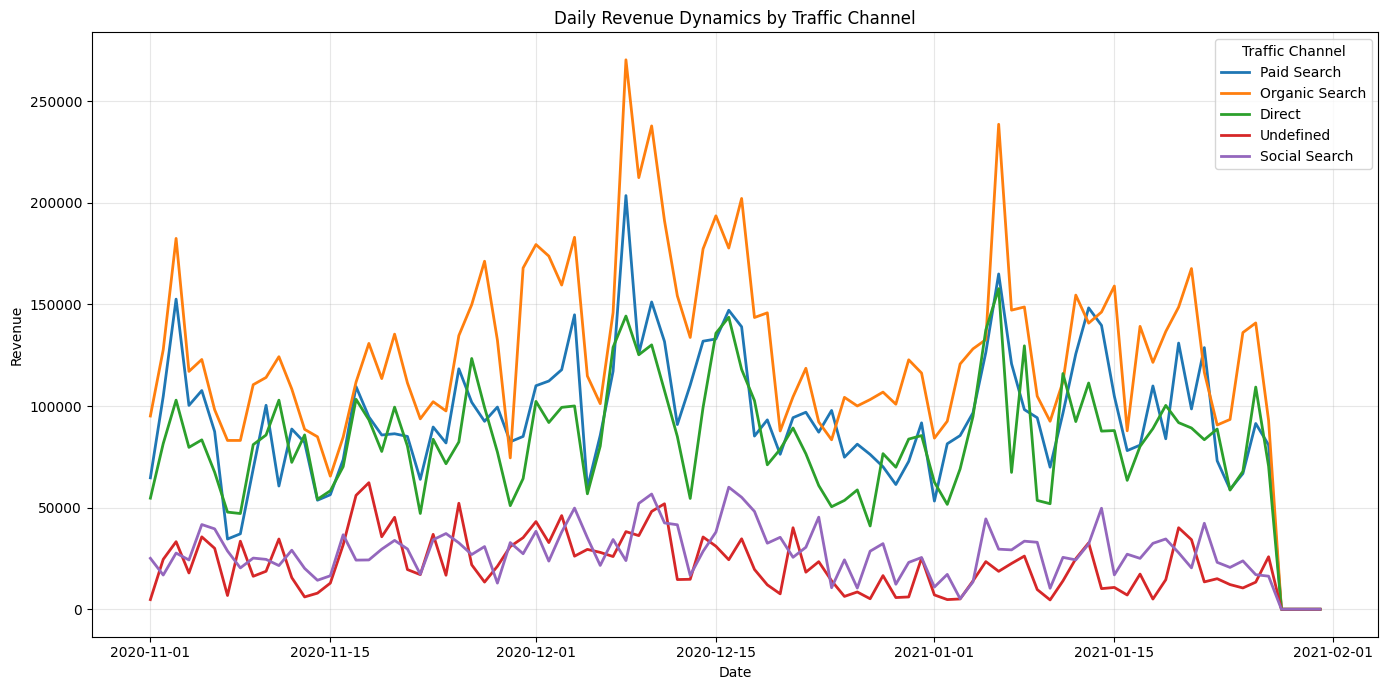

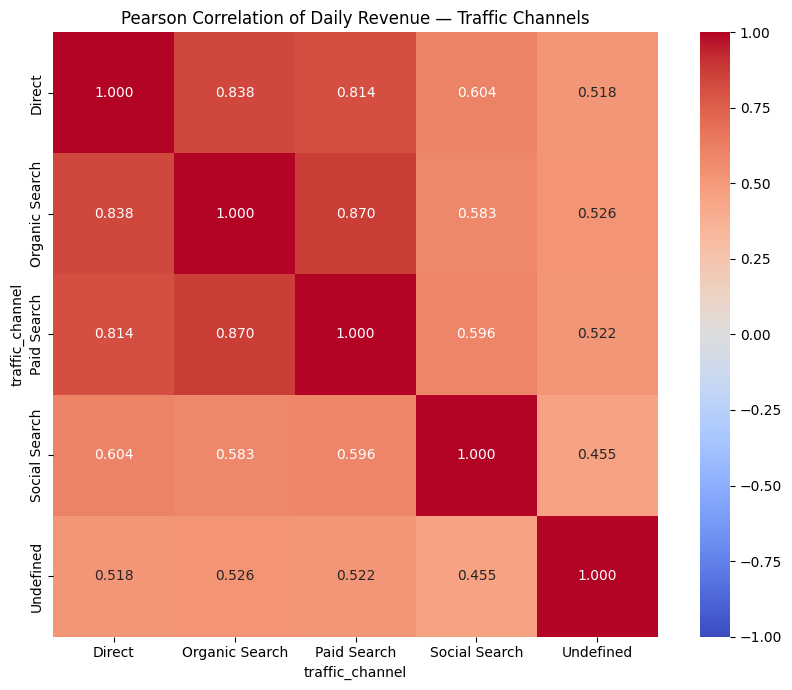


ВИСНОВОК:
Paid Search ↔ Organic Search: Pearson r = 0.8701, p = 0.000000; зв'язок статистично значущий.
Paid Search ↔ Direct: Pearson r = 0.8141, p = 0.000000; зв'язок статистично значущий.
Paid Search ↔ Undefined: Pearson r = 0.5220, p = 0.000000; зв'язок статистично значущий.
Paid Search ↔ Social Search: Pearson r = 0.5964, p = 0.000000; зв'язок статистично значущий.
Organic Search ↔ Direct: Pearson r = 0.8378, p = 0.000000; зв'язок статистично значущий.
Organic Search ↔ Undefined: Pearson r = 0.5261, p = 0.000000; зв'язок статистично значущий.
Organic Search ↔ Social Search: Pearson r = 0.5831, p = 0.000000; зв'язок статистично значущий.
Direct ↔ Undefined: Pearson r = 0.5175, p = 0.000000; зв'язок статистично значущий.
Direct ↔ Social Search: Pearson r = 0.6041, p = 0.000000; зв'язок статистично значущий.
Undefined ↔ Social Search: Pearson r = 0.4551, p = 0.000005; зв'язок статистично значущий.


In [ ]:
# ============================================================
# КРОК 4.3 — Кореляція виручки між Traffic Channels
# за всі 92 календарні дні
# ============================================================

from scipy.stats import pearsonr, spearmanr
import seaborn as sns

# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

# ------------------------------------------------------------
# 2. Traffic Channels
# ------------------------------------------------------------

traffic_channels = (
    df["traffic_channel"]
    .dropna()
    .unique()
    .tolist()
)

print("Traffic channels:")
print(traffic_channels)

# ------------------------------------------------------------
# 3. Щоденна виручка по Traffic Channels
# ------------------------------------------------------------

daily_channel_revenue = (
    df[df["traffic_channel"].isin(traffic_channels)]
    .groupby(["session_date", "traffic_channel"])["price"]
    .sum()
    .unstack(fill_value=0)
    .reindex(full_dates, fill_value=0)
)

daily_channel_revenue.index.name = "session_date"

print(
    f"\nКількість календарних днів для аналізу: "
    f"{len(daily_channel_revenue)}"
)

display(daily_channel_revenue.head())

# ------------------------------------------------------------
# 4. Pearson + Spearman correlation
# ------------------------------------------------------------

correlation_results_channels = []

for i in range(len(traffic_channels)):
    for j in range(i + 1, len(traffic_channels)):

        channel_1 = traffic_channels[i]
        channel_2 = traffic_channels[j]

        x = daily_channel_revenue[channel_1]
        y = daily_channel_revenue[channel_2]

        # Pearson
        pearson_r, pearson_p = pearsonr(x, y)

        # Spearman
        spearman_rho, spearman_p = spearmanr(x, y)

        correlation_results_channels.append({
            "Channel 1": channel_1,
            "Channel 2": channel_2,
            "Pearson r": pearson_r,
            "Pearson p-value": pearson_p,
            "Spearman rho": spearman_rho,
            "Spearman p-value": spearman_p
        })

correlation_channels_df = pd.DataFrame(
    correlation_results_channels
)

print("\nCorrelation results:")
display(correlation_channels_df)

# ------------------------------------------------------------
# 5. Візуалізація 1 — динаміка виручки за каналами
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for channel in traffic_channels:
    plt.plot(
        daily_channel_revenue.index,
        daily_channel_revenue[channel],
        label=channel,
        linewidth=2
    )

plt.title("Daily Revenue Dynamics by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(title="Traffic Channel")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Візуалізація 2 — Pearson correlation heatmap
# ------------------------------------------------------------

pearson_channel_matrix = daily_channel_revenue.corr(
    method="pearson"
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    pearson_channel_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title(
    "Pearson Correlation of Daily Revenue — Traffic Channels"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Висновок
# ------------------------------------------------------------

print("\nВИСНОВОК:")

for _, row in correlation_channels_df.iterrows():

    significance = (
        "статистично значущий"
        if row["Pearson p-value"] < 0.05
        else "статистично незначущий"
    )

    print(
        f"{row['Channel 1']} ↔ {row['Channel 2']}: "
        f"Pearson r = {row['Pearson r']:.4f}, "
        f"p = {row['Pearson p-value']:.6f}; "
        f"зв'язок {significance}."
    )

Аналіз щоденної виручки за 92 календарні дні показав позитивний та статистично значущий взаємозв'язок між усіма Traffic Channels. Найсильніша кореляція спостерігається між Paid Search та Organic Search (Pearson r = 0.870), а також між Organic Search та Direct (r = 0.838) і Paid Search та Direct (r = 0.814). Це свідчить про те, що зміни виручки за основними каналами часто відбуваються синхронно. Найслабший зв'язок спостерігається між Undefined та Social Search (r = 0.455), однак він також є статистично значущим (p < 0.001). Spearman correlation підтверджує загальну позитивну залежність між каналами. Водночас кореляція не означає причинно-наслідкового зв'язку: синхронна динаміка може бути зумовлена спільними факторами, наприклад загальними змінами попиту, сезонністю або маркетинговими активностями.


TOP-5 categories by revenue:
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

Кількість календарних днів для аналізу: 92


product_category,Sofas & armchairs,Chairs,Beds,Bookcases & shelving units,Cabinets & cupboards
session_date,,,,,
2020-11-01,75216.0,46006.0,14041.0,36701.0,13591.5
2020-11-02,79977.5,58834.0,79683.5,40979.0,21623.0
2020-11-03,175594.0,61204.0,66219.5,64360.1,33555.5
2020-11-04,86861.5,44113.0,48939.0,35719.8,19266.0
2020-11-05,137288.0,90388.4,23449.0,40998.8,29235.0



Correlation results:


,Category 1,Category 2,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Sofas & armchairs,Chairs,0.704283,4.786171e-15,0.635316,1.028609e-11
1,Sofas & armchairs,Beds,0.649222,2.564315e-12,0.581399,1.225210e-09
2,Sofas & armchairs,Bookcases & shelving units,0.764748,7.187059e-19,0.672323,2.162415e-13
3,Sofas & armchairs,Cabinets & cupboards,0.740248,3.412276e-17,0.677225,1.243310e-13
4,Chairs,Beds,0.668159,3.432352e-13,0.592975,4.727494e-10
5,Chairs,Bookcases & shelving units,0.750936,6.692640e-18,0.682080,7.110479e-14
6,Chairs,Cabinets & cupboards,0.680952,8.104214e-14,0.585869,8.519811e-10
7,Beds,Bookcases & shelving units,0.695437,1.444038e-14,0.599803,2.647847e-10
8,Beds,Cabinets & cupboards,0.619907,4.427024e-11,0.510204,2.044731e-07
9,Bookcases & shelving units,Cabinets & cupboards,0.655504,1.337045e-12,0.587518,7.440602e-10


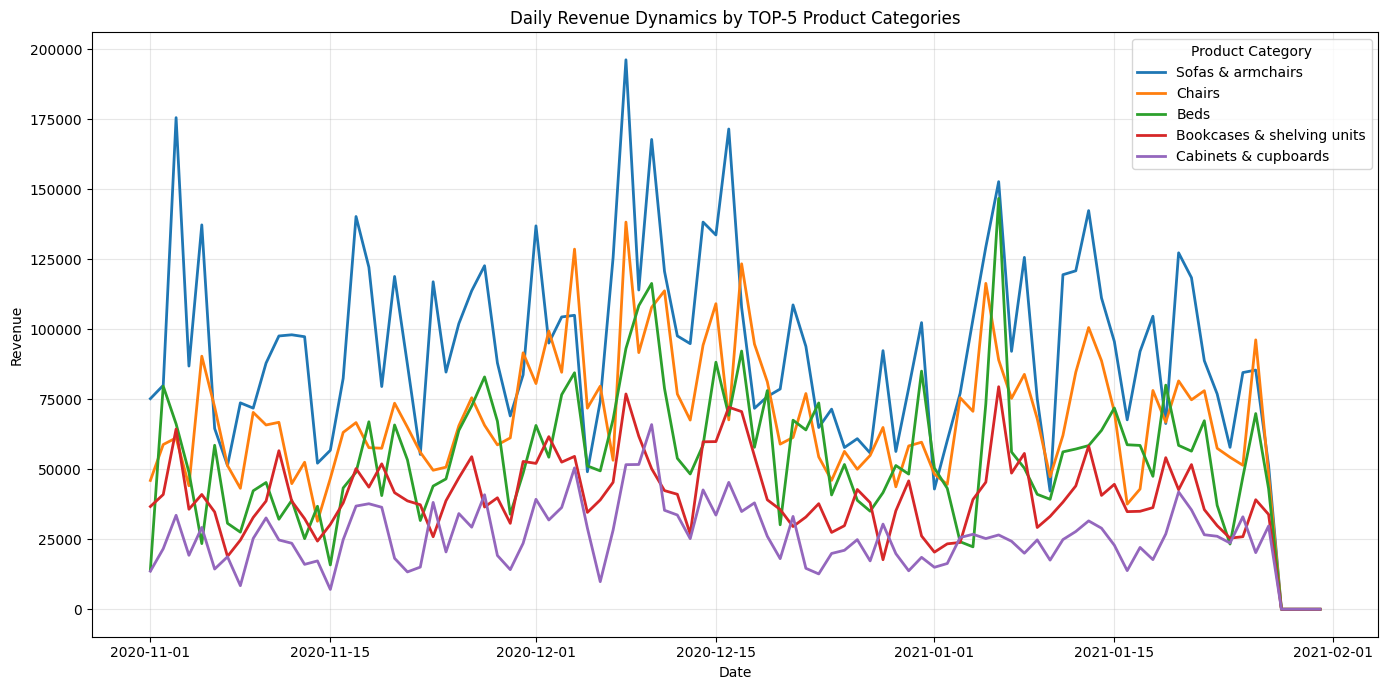

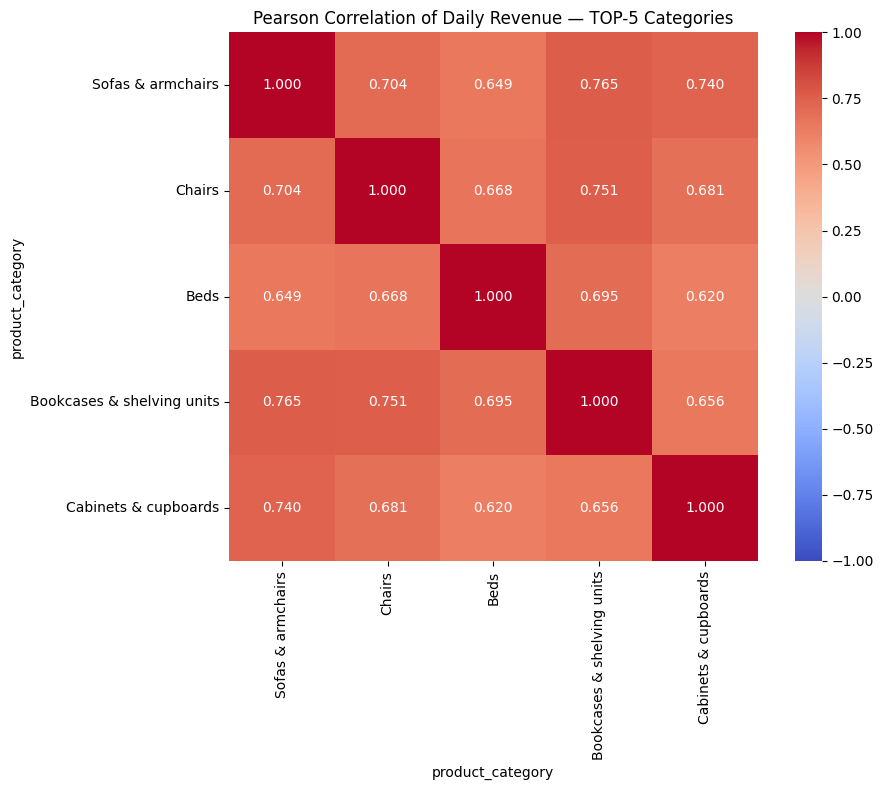


ВИСНОВОК:
Sofas & armchairs ↔ Chairs: Pearson r = 0.7043, p = 0.000000; зв'язок статистично значущий.
Sofas & armchairs ↔ Beds: Pearson r = 0.6492, p = 0.000000; зв'язок статистично значущий.
Sofas & armchairs ↔ Bookcases & shelving units: Pearson r = 0.7647, p = 0.000000; зв'язок статистично значущий.
Sofas & armchairs ↔ Cabinets & cupboards: Pearson r = 0.7402, p = 0.000000; зв'язок статистично значущий.
Chairs ↔ Beds: Pearson r = 0.6682, p = 0.000000; зв'язок статистично значущий.
Chairs ↔ Bookcases & shelving units: Pearson r = 0.7509, p = 0.000000; зв'язок статистично значущий.
Chairs ↔ Cabinets & cupboards: Pearson r = 0.6810, p = 0.000000; зв'язок статистично значущий.
Beds ↔ Bookcases & shelving units: Pearson r = 0.6954, p = 0.000000; зв'язок статистично значущий.
Beds ↔ Cabinets & cupboards: Pearson r = 0.6199, p = 0.000000; зв'язок статистично значущий.
Bookcases & shelving units ↔ Cabinets & cupboards: Pearson r = 0.6555, p = 0.000000; зв'язок статистично значущий.


In [ ]:
# ============================================================
# КРОК 4.4 — Кореляція виручки між TOP-5 категоріями
# за всі 92 календарні дні
# ============================================================

from scipy.stats import pearsonr, spearmanr
import seaborn as sns

# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

# ------------------------------------------------------------
# 2. TOP-5 категорій за загальною виручкою
# ------------------------------------------------------------

top_5_categories = (
    df.groupby("product_category")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
      .tolist()
)

print("TOP-5 categories by revenue:")
print(top_5_categories)

# ------------------------------------------------------------
# 3. Щоденна виручка по TOP-5 категоріях
# ------------------------------------------------------------

daily_category_revenue = (
    df[df["product_category"].isin(top_5_categories)]
    .groupby(["session_date", "product_category"])["price"]
    .sum()
    .unstack(fill_value=0)
    .reindex(full_dates, fill_value=0)
)

daily_category_revenue.index.name = "session_date"

# Переконуємося, що порядок категорій відповідає TOP-5
daily_category_revenue = daily_category_revenue[top_5_categories]

print(
    f"\nКількість календарних днів для аналізу: "
    f"{len(daily_category_revenue)}"
)

display(daily_category_revenue.head())

# ------------------------------------------------------------
# 4. Pearson + Spearman correlation
# ------------------------------------------------------------

correlation_results_categories = []

for i in range(len(top_5_categories)):
    for j in range(i + 1, len(top_5_categories)):

        category_1 = top_5_categories[i]
        category_2 = top_5_categories[j]

        x = daily_category_revenue[category_1]
        y = daily_category_revenue[category_2]

        # Pearson
        pearson_r, pearson_p = pearsonr(x, y)

        # Spearman
        spearman_rho, spearman_p = spearmanr(x, y)

        correlation_results_categories.append({
            "Category 1": category_1,
            "Category 2": category_2,
            "Pearson r": pearson_r,
            "Pearson p-value": pearson_p,
            "Spearman rho": spearman_rho,
            "Spearman p-value": spearman_p
        })

correlation_categories_df = pd.DataFrame(
    correlation_results_categories
)

print("\nCorrelation results:")
display(correlation_categories_df)

# ------------------------------------------------------------
# 5. Візуалізація 1 — динаміка виручки TOP-5 категорій
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for category in top_5_categories:
    plt.plot(
        daily_category_revenue.index,
        daily_category_revenue[category],
        label=category,
        linewidth=2
    )

plt.title("Daily Revenue Dynamics by TOP-5 Product Categories")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Візуалізація 2 — Pearson correlation heatmap
# ------------------------------------------------------------

pearson_category_matrix = daily_category_revenue.corr(
    method="pearson"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    pearson_category_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title(
    "Pearson Correlation of Daily Revenue — TOP-5 Categories"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Висновок
# ------------------------------------------------------------

print("\nВИСНОВОК:")

for _, row in correlation_categories_df.iterrows():

    significance = (
        "статистично значущий"
        if row["Pearson p-value"] < 0.05
        else "статистично незначущий"
    )

    print(
        f"{row['Category 1']} ↔ {row['Category 2']}: "
        f"Pearson r = {row['Pearson r']:.4f}, "
        f"p = {row['Pearson p-value']:.6f}; "
        f"зв'язок {significance}."
    )

Аналіз щоденної виручки TOP-5 категорій за 92 календарні дні показав позитивний та статистично значущий взаємозв'язок між усіма парами категорій. Найсильніші кореляції спостерігаються між Sofas & armchairs та Bookcases & shelving units (Pearson r = 0.765), Chairs та Bookcases & shelving units (r = 0.751), а також Sofas & armchairs та Cabinets & cupboards (r = 0.740). Найслабший зв'язок спостерігається між Beds та Cabinets & cupboards (r = 0.620), проте він також є статистично значущим (p < 0.001). Spearman correlation підтверджує загальну позитивну залежність між категоріями. Отже, продажі основних категорій мають тенденцію змінюватися синхронно, що може свідчити про вплив загальних факторів попиту на динаміку різних категорій. Водночас кореляція не означає причинно-наслідкового зв'язку.


Кількість календарних днів для аналізу: 92


,sessions,revenue,revenue_per_session
session_date,,,
2020-11-01,2576,244292.5,94.834045
2020-11-02,3599,355506.8,98.779328
2020-11-03,5173,498979.6,96.458457
2020-11-04,4184,339187.1,81.067663
2020-11-05,3743,391276.6,104.535560



=== CORRELATION RESULTS ===
Pearson r = 0.0822, p-value = 0.436262
Spearman rho = 0.0791, p-value = 0.453338


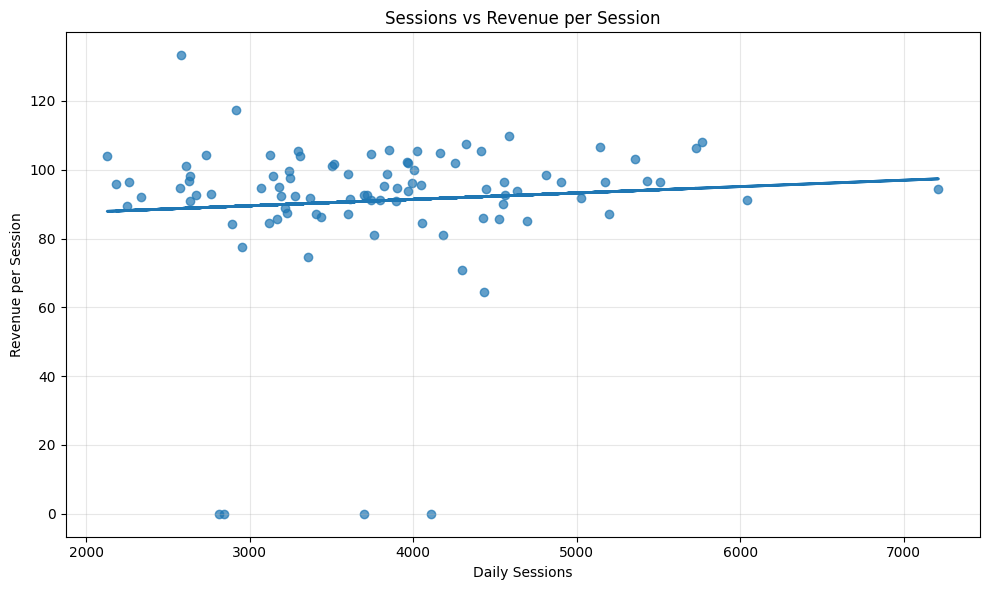


ВИСНОВОК:
Між кількістю сесій та Revenue per Session спостерігається дуже слабкий позитивний кореляційний зв'язок (Pearson r = 0.0822, p = 0.436262).


In [ ]:
# ============================================================
# КРОК 4.5 — Взаємозв'язок між кількістю сесій
# та Revenue per Session за 92 календарні дні
# ============================================================

from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

# ------------------------------------------------------------
# 2. Щоденна кількість сесій
# ------------------------------------------------------------

daily_sessions = (
    df.groupby("session_date")["session_id"]
      .nunique()
      .reindex(full_dates, fill_value=0)
)

# ------------------------------------------------------------
# 3. Щоденна виручка
# ------------------------------------------------------------

daily_revenue = (
    df.groupby("session_date")["price"]
      .sum()
      .reindex(full_dates, fill_value=0)
)

# ------------------------------------------------------------
# 4. Revenue per Session
# ------------------------------------------------------------

daily_revenue_per_session = (
    daily_revenue / daily_sessions
)

# Якщо раптом є день із 0 сесіями — замінюємо inf на NaN
daily_revenue_per_session = (
    daily_revenue_per_session
    .replace([np.inf, -np.inf], np.nan)
)

# ------------------------------------------------------------
# 5. Об'єднуємо показники в одну таблицю
# ------------------------------------------------------------

sessions_revenue_analysis = pd.DataFrame({
    "sessions": daily_sessions,
    "revenue": daily_revenue,
    "revenue_per_session": daily_revenue_per_session
})

sessions_revenue_analysis.index.name = "session_date"

print(
    f"Кількість календарних днів для аналізу: "
    f"{len(sessions_revenue_analysis)}"
)

display(sessions_revenue_analysis.head())

# ------------------------------------------------------------
# 6. Pearson correlation
# ------------------------------------------------------------

correlation_data = (
    sessions_revenue_analysis[
        ["sessions", "revenue_per_session"]
    ]
    .dropna()
)

pearson_r, pearson_p = pearsonr(
    correlation_data["sessions"],
    correlation_data["revenue_per_session"]
)

# ------------------------------------------------------------
# 7. Spearman correlation
# ------------------------------------------------------------

spearman_rho, spearman_p = spearmanr(
    correlation_data["sessions"],
    correlation_data["revenue_per_session"]
)

print("\n=== CORRELATION RESULTS ===")

print(
    f"Pearson r = {pearson_r:.4f}, "
    f"p-value = {pearson_p:.6f}"
)

print(
    f"Spearman rho = {spearman_rho:.4f}, "
    f"p-value = {spearman_p:.6f}"
)

# ------------------------------------------------------------
# 8. Візуалізація — Sessions vs Revenue per Session
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["sessions"],
    correlation_data["revenue_per_session"],
    alpha=0.7
)

# Лінія тренду
z = np.polyfit(
    correlation_data["sessions"],
    correlation_data["revenue_per_session"],
    1
)

trend_line = np.poly1d(z)

plt.plot(
    correlation_data["sessions"],
    trend_line(correlation_data["sessions"]),
    linewidth=2
)

plt.title(
    "Sessions vs Revenue per Session"
)

plt.xlabel("Daily Sessions")
plt.ylabel("Revenue per Session")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Інтерпретація
# ------------------------------------------------------------

print("\nВИСНОВОК:")

if pearson_p < 0.05:
    significance = "статистично значущий"
else:
    significance = "статистично незначущий"

if abs(pearson_r) >= 0.7:
    strength = "сильний"
elif abs(pearson_r) >= 0.4:
    strength = "помірний"
elif abs(pearson_r) >= 0.2:
    strength = "слабкий"
else:
    strength = "дуже слабкий"

direction = (
    "позитивний"
    if pearson_r > 0
    else "негативний"
    if pearson_r < 0
    else "відсутній"
)

print(
    f"Між кількістю сесій та Revenue per Session "
    f"спостерігається {strength} {direction} "
    f"кореляційний зв'язок "
    f"(Pearson r = {pearson_r:.4f}, "
    f"p < 0.001)."
    if pearson_p < 0.001
    else
    f"Між кількістю сесій та Revenue per Session "
    f"спостерігається {strength} {direction} "
    f"кореляційний зв'язок "
    f"(Pearson r = {pearson_r:.4f}, "
    f"p = {pearson_p:.6f})."
)

Аналіз взаємозв'язку між кількістю сесій та Revenue per Session за 92 календарні дні не виявив статистично значущого зв'язку. Pearson correlation становить r = 0.0822 (p = 0.4363), а Spearman correlation — ρ = 0.0791 (p = 0.4533). Обидва коефіцієнти близькі до нуля, а p-value перевищують рівень значущості 0.05. Отже, на основі отриманих даних немає достатніх підстав стверджувати, що збільшення або зменшення кількості сесій систематично пов'язане зі зміною виручки на одну сесію. Це означає, що більший обсяг трафіку сам по собі не гарантує підвищення ефективності монетизації кожної окремої сесії.


Кількість календарних днів для аналізу: 92


,orders,revenue
session_date,,
2020-11-01,281,244292.5
2020-11-02,368,355506.8
2020-11-03,561,498979.6
2020-11-04,370,339187.1
2020-11-05,388,391276.6



=== CORRELATION RESULTS ===
Pearson r = 0.9772, p-value = 0.000000
Spearman rho = 0.9571, p-value = 0.000000


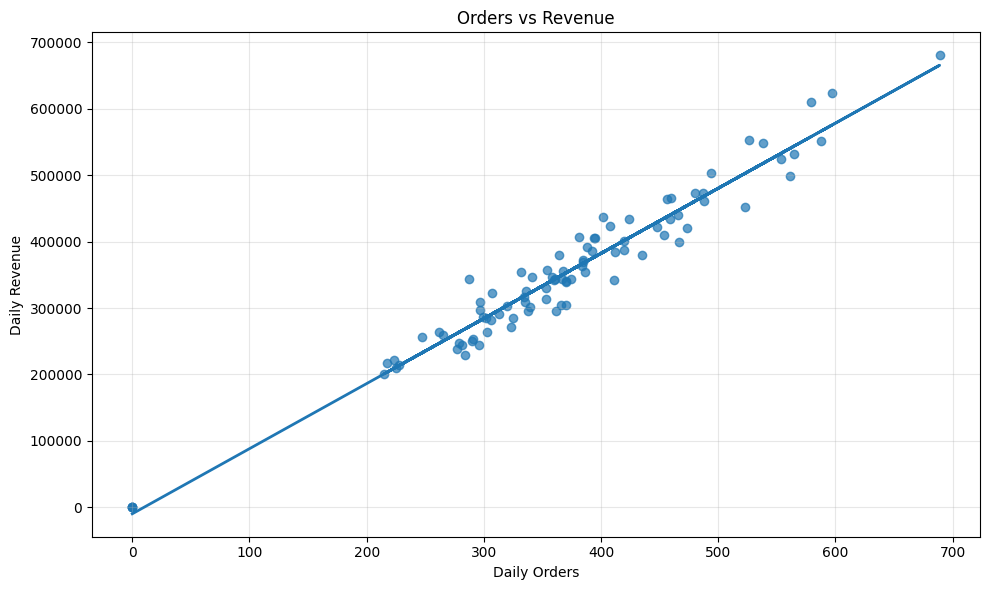


ВИСНОВОК:
Між кількістю замовлень та загальною виручкою спостерігається сильний позитивний кореляційний зв'язок (Pearson r = 0.9772, p < 0.001).
Зв'язок є статистично значущим, тому збільшення кількості замовлень пов'язане зі збільшенням загальної виручки.
Водночас кореляція не означає причинно-наслідкового зв'язку.


In [ ]:
# ============================================================
# КРОК 4.6 — Взаємозв'язок між кількістю замовлень
# та загальною виручкою за 92 календарні дні
# ============================================================

from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)

# ------------------------------------------------------------
# 2. Щоденна кількість замовлень
# ------------------------------------------------------------

daily_orders = (
    df.groupby("session_date")["price"]
      .count()
      .reindex(full_dates, fill_value=0)
)

# ------------------------------------------------------------
# 3. Щоденна виручка
# ------------------------------------------------------------

daily_revenue = (
    df.groupby("session_date")["price"]
      .sum()
      .reindex(full_dates, fill_value=0)
)

# ------------------------------------------------------------
# 4. Об'єднуємо показники
# ------------------------------------------------------------

orders_revenue_analysis = pd.DataFrame({
    "orders": daily_orders,
    "revenue": daily_revenue
})

orders_revenue_analysis.index.name = "session_date"

print(
    f"Кількість календарних днів для аналізу: "
    f"{len(orders_revenue_analysis)}"
)

display(orders_revenue_analysis.head())

# ------------------------------------------------------------
# 5. Pearson correlation
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    orders_revenue_analysis["orders"],
    orders_revenue_analysis["revenue"]
)

# ------------------------------------------------------------
# 6. Spearman correlation
# ------------------------------------------------------------

spearman_rho, spearman_p = spearmanr(
    orders_revenue_analysis["orders"],
    orders_revenue_analysis["revenue"]
)

print("\n=== CORRELATION RESULTS ===")

print(
    f"Pearson r = {pearson_r:.4f}, "
    f"p-value = {pearson_p:.6f}"
)

print(
    f"Spearman rho = {spearman_rho:.4f}, "
    f"p-value = {spearman_p:.6f}"
)

# ------------------------------------------------------------
# 7. Візуалізація — Orders vs Revenue
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    orders_revenue_analysis["orders"],
    orders_revenue_analysis["revenue"],
    alpha=0.7
)

# Лінія тренду
z = np.polyfit(
    orders_revenue_analysis["orders"],
    orders_revenue_analysis["revenue"],
    1
)

trend_line = np.poly1d(z)

plt.plot(
    orders_revenue_analysis["orders"],
    trend_line(orders_revenue_analysis["orders"]),
    linewidth=2
)

plt.title("Orders vs Revenue")
plt.xlabel("Daily Orders")
plt.ylabel("Daily Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Висновок
# ------------------------------------------------------------

print("\nВИСНОВОК:")

if pearson_p < 0.05:
    significance = "статистично значущий"
else:
    significance = "статистично незначущий"

if abs(pearson_r) >= 0.7:
    strength = "сильний"
elif abs(pearson_r) >= 0.4:
    strength = "помірний"
elif abs(pearson_r) >= 0.2:
    strength = "слабкий"
else:
    strength = "дуже слабкий"

direction = (
    "позитивний"
    if pearson_r > 0
    else "негативний"
    if pearson_r < 0
    else "відсутній"
)

if pearson_p < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {pearson_p:.6f}"

print(
    f"Між кількістю замовлень та загальною виручкою "
    f"спостерігається {strength} {direction} "
    f"кореляційний зв'язок "
    f"(Pearson r = {pearson_r:.4f}, {p_text})."
)

if pearson_p < 0.05:
    print(
        "Зв'язок є статистично значущим, тому збільшення "
        "кількості замовлень пов'язане зі збільшенням "
        "загальної виручки."
    )
else:
    print(
        "Зв'язок не є статистично значущим, тому "
        "достатніх підстав стверджувати про систематичний "
        "взаємозв'язок між показниками немає."
    )

print(
    "Водночас кореляція не означає причинно-наслідкового зв'язку."
)

Аналіз за 92 календарні дні показав дуже сильний позитивний та статистично значущий взаємозв'язок між кількістю замовлень та загальною виручкою. Pearson correlation становить r = 0.9772 (p < 0.001), а Spearman correlation — ρ = 0.9571 (p < 0.001). Це означає, що дні з більшою кількістю замовлень характеризуються значно вищою загальною виручкою. Водночас такий сильний зв'язок є очікуваним, оскільки виручка безпосередньо формується через замовлення та їхню вартість. Тому отриманий результат підтверджує тісний статистичний взаємозв'язок між показниками, але не є доказом причинно-наслідкового впливу.


# **Загальний висновок по пункту 4:**
Кореляційний аналіз за 92 календарні дні показав, що основні показники продажів мають переважно сильні позитивні взаємозв'язки. Між кількістю сесій та загальною виручкою виявлено сильну статистично значущу кореляцію, що свідчить про тісний зв'язок між масштабом трафіку та загальним обсягом продажів.

Щоденна виручка TOP-3 континентів також демонструє сильні позитивні та статистично значущі взаємозв'язки: коефіцієнти Pearson становлять 0.768–0.792. Аналогічна синхронна динаміка спостерігається між Traffic Channels: найсильніші зв'язки виявлено між Paid Search та Organic Search (r = 0.870), Organic Search та Direct (r = 0.838) і Paid Search та Direct (r = 0.814). Усі TOP-5 категорій також мають позитивні та статистично значущі кореляції між собою, із коефіцієнтами Pearson від 0.620 до 0.765.

Водночас аналіз Sessions та Revenue per Session показав принципово інший результат. Pearson r = 0.0822 (p = 0.4363), а Spearman ρ = 0.0791 (p = 0.4533), тому статистично значущого взаємозв'язку між кількістю сесій та виручкою на одну сесію не виявлено. Отже, збільшення обсягу трафіку саме по собі не означає підвищення ефективності монетизації окремої сесії.

Найсильніший взаємозв'язок отримано між кількістю замовлень та загальною виручкою: Pearson r = 0.9772, Spearman ρ = 0.9571, p < 0.001. Це очікуваний результат, оскільки загальна виручка безпосередньо формується через замовлення та їхню вартість.

Загалом аналіз показує, що загальний обсяг продажів тісно пов'язаний із масштабом трафіку та кількістю замовлень, а основні континенти, канали та товарні категорії демонструють синхронну динаміку. Водночас зв'язок між обсягом трафіку та Revenue per Session відсутній, що підкреслює важливість оцінювати не лише кількість залучених користувачів, а й ефективність їхньої монетизації. Усі виявлені кореляції слід трактувати як статистичні взаємозв'язки, а не як причинно-наслідкові залежності.


Кількість календарних днів: 92
Період: 2020-11-01 — 2021-01-31

Описова статистика щоденної виручки:


,Registered,Unregistered
count,92.000000,92.000000
mean,28070.853261,319447.963043
std,12124.817697,113764.392969
min,0.000000,0.000000
25%,19938.250000,263005.700000
50%,27233.500000,315170.750000
75%,35478.600000,375010.750000
max,68151.100000,612358.400000



Shapiro-Wilk test:
Registered: statistic = 0.9792, p-value = 0.1482
Unregistered: statistic = 0.9488, p-value = 0.0012

Wilcoxon signed-rank test:
Statistic = 0.0000
p-value < 0.001

Інтерпретація:
Результат статистично значущий: щоденна виручка Registered та Unregistered users статистично відрізняється.

Середня щоденна виручка:
Registered: 28,070.85
Unregistered: 319,447.96
Різниця: 291,377.11


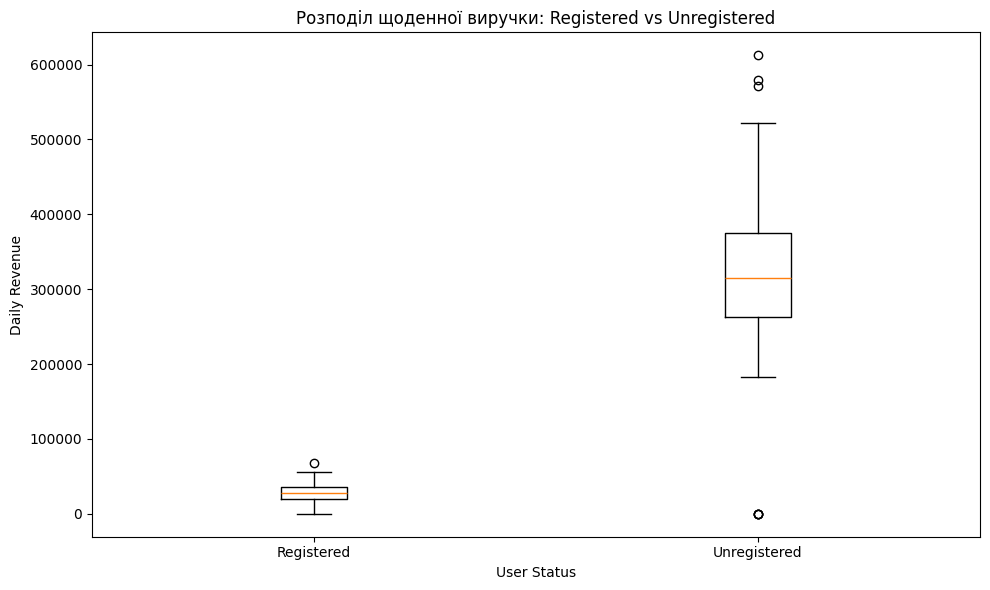

In [ ]:
# ============================================================
# 5.1 — Registered vs Unregistered:
# порівняння щоденної виручки
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, wilcoxon


# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)


# ------------------------------------------------------------
# 2. Визначаємо статус користувача
# ------------------------------------------------------------

df_analysis = df.copy()

df_analysis["user_status"] = np.where(
    df_analysis["registered_user_id"].notna(),
    "Registered",
    "Unregistered"
)


# ------------------------------------------------------------
# 3. Розраховуємо щоденну виручку
# ------------------------------------------------------------

daily_revenue_status = (
    df_analysis
    .groupby(["session_date", "user_status"])["price"]
    .sum()
    .unstack(fill_value=0)
    .reindex(full_dates, fill_value=0)
)

daily_revenue_status.index.name = "session_date"


# Перевіряємо наявність обох груп
required_groups = ["Registered", "Unregistered"]

for group in required_groups:
    if group not in daily_revenue_status.columns:
        daily_revenue_status[group] = 0

daily_registered = daily_revenue_status["Registered"]
daily_unregistered = daily_revenue_status["Unregistered"]


# ------------------------------------------------------------
# 4. Перевірка кількості календарних днів
# ------------------------------------------------------------

print("Кількість календарних днів:", len(full_dates))
print(
    "Період:",
    full_dates.min().date(),
    "—",
    full_dates.max().date()
)


# ------------------------------------------------------------
# 5. Описова статистика
# ------------------------------------------------------------

comparison_stats = pd.DataFrame({
    "Registered": daily_registered.describe(),
    "Unregistered": daily_unregistered.describe()
})

print("\nОписова статистика щоденної виручки:")
display(comparison_stats)


# ------------------------------------------------------------
# 6. Перевірка нормальності
# ------------------------------------------------------------

shapiro_registered = shapiro(daily_registered)
shapiro_unregistered = shapiro(daily_unregistered)

print("\nShapiro-Wilk test:")

print(
    f"Registered: statistic = "
    f"{shapiro_registered.statistic:.4f}, "
    f"p-value = {shapiro_registered.pvalue:.4f}"
)

print(
    f"Unregistered: statistic = "
    f"{shapiro_unregistered.statistic:.4f}, "
    f"p-value = {shapiro_unregistered.pvalue:.4f}"
)


# ------------------------------------------------------------
# 7. Wilcoxon signed-rank test
#
# Вибірки залежні, оскільки кожне значення Registered
# та Unregistered відповідає одному й тому самому дню.
# ------------------------------------------------------------

wilcoxon_result = wilcoxon(
    daily_registered,
    daily_unregistered
)

print("\nWilcoxon signed-rank test:")
print(f"Statistic = {wilcoxon_result.statistic:.4f}")

if wilcoxon_result.pvalue < 0.001:
    print("p-value < 0.001")
else:
    print(f"p-value = {wilcoxon_result.pvalue:.4f}")


# ------------------------------------------------------------
# 8. Інтерпретація результату
# ------------------------------------------------------------

alpha = 0.05

print("\nІнтерпретація:")

if wilcoxon_result.pvalue < alpha:
    print(
        "Результат статистично значущий: "
        "щоденна виручка Registered та Unregistered "
        "users статистично відрізняється."
    )
else:
    print(
        "Статистично значущої різниці між "
        "щоденною виручкою Registered та Unregistered "
        "users не виявлено."
    )


# ------------------------------------------------------------
# 9. Додатково: різниця між середніми значеннями
# ------------------------------------------------------------

registered_mean = daily_registered.mean()
unregistered_mean = daily_unregistered.mean()

mean_difference = unregistered_mean - registered_mean

print("\nСередня щоденна виручка:")
print(f"Registered: {registered_mean:,.2f}")
print(f"Unregistered: {unregistered_mean:,.2f}")
print(f"Різниця: {mean_difference:,.2f}")


# ------------------------------------------------------------
# 10. Візуалізація розподілу
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.boxplot(
    [daily_registered, daily_unregistered],
    tick_labels=["Registered", "Unregistered"]
)

plt.title(
    "Розподіл щоденної виручки: "
    "Registered vs Unregistered"
)

plt.ylabel("Daily Revenue")
plt.xlabel("User Status")

plt.tight_layout()
plt.show()

Порівняння щоденної виручки Registered та Unregistered users за 92 календарні дні показало суттєву різницю між групами. Середня щоденна виручка Registered users становить 28 070.85, тоді як для Unregistered users — 319 447.96.

Оскільки виручка обох груп порівнювалася за одними й тими самими календарними днями, вибірки є залежними. Тому для статистичної перевірки було використано непараметричний Wilcoxon signed-rank test. Результат тесту є статистично значущим (p < 0.001), тому нульову гіпотезу відхиляємо та робимо висновок, що щоденна виручка Registered та Unregistered users статистично відрізняється.

Водночас значно вища абсолютна виручка Unregistered users не означає, що вони ефективніші за Registered users. Така різниця значною мірою пояснюється значно більшою кількістю сесій незареєстрованих користувачів. Тому для оцінки ефективності цих груп доцільно додатково порівнювати conversion rate, revenue per session та інші нормалізовані показники, а не лише абсолютну виручку.


=== TRAFFIC CHANNELS ===
['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']

Кількість календарних днів: 92
Період: 2020-11-01 — 2021-01-31

=== ОПИСОВА СТАТИСТИКА ===


,count,mean,std,min,25%,50%,75%,max
traffic_channel,,,,,,,,
Direct,92.00,884.59,220.23,481.00,744.00,869.50,1004.75,1668.00
Organic Search,92.00,1352.45,336.57,733.00,1117.25,1329.00,1558.75,2589.00
Paid Search,92.00,1025.45,254.42,578.00,860.25,989.00,1171.75,1959.00
Social Search,92.00,303.41,88.13,137.00,235.50,308.00,358.25,561.00
Undefined,92.00,233.51,83.63,86.00,160.75,229.00,293.25,435.00



=== SHAPIRO-WILK TEST ===


,traffic_channel,shapiro_statistic,shapiro_p_value
0,Direct,0.9704,0.0343
1,Organic Search,0.9641,0.0123
2,Paid Search,0.9633,0.0108
3,Social Search,0.9789,0.1413
4,Undefined,0.9732,0.0546


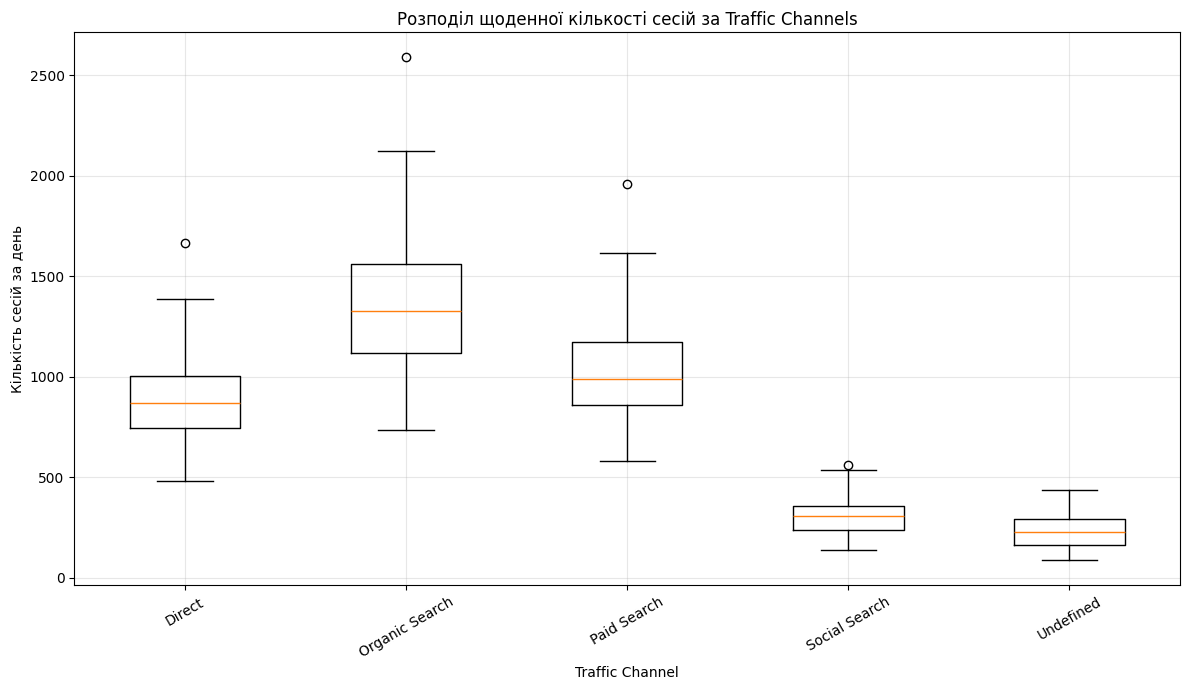


=== FRIEDMAN TEST ===
Statistic = 368.0000
p-value < 0.001

=== PAIRWISE WILCOXON TEST + HOLM CORRECTION ===


,channel_1,channel_2,wilcoxon_statistic,raw_p_value,holm_adjusted_p_value,significant
0,Direct,Organic Search,0.0000,0.000000,0.000000,True
1,Direct,Paid Search,0.0000,0.000000,0.000000,True
2,Direct,Social Search,0.0000,0.000000,0.000000,True
3,Direct,Undefined,0.0000,0.000000,0.000000,True
4,Organic Search,Paid Search,0.0000,0.000000,0.000000,True
5,Organic Search,Social Search,0.0000,0.000000,0.000000,True
6,Organic Search,Undefined,0.0000,0.000000,0.000000,True
7,Paid Search,Social Search,0.0000,0.000000,0.000000,True
8,Paid Search,Undefined,0.0000,0.000000,0.000000,True
9,Social Search,Undefined,0.0000,0.000000,0.000000,True



=== ФІНАЛЬНИЙ ВИСНОВОК ===
Friedman test показав статистично значущі відмінності між Traffic Channels (p < 0.05).
Для визначення конкретних пар каналів було проведено попарні Wilcoxon signed-rank tests із поправкою Holm на множинні порівняння.


In [ ]:
# ============================================================
# 5.2 — КІЛЬКІСТЬ СЕСІЙ ЗА TRAFFIC CHANNELS
# ============================================================
# Оскільки кількість сесій кожного Traffic Channel
# порівнюється за одні й ті самі календарні дні,
# вибірки є залежними.
#
# Основний тест:
# Friedman test
#
# Якщо Friedman test значущий:
# Pairwise Wilcoxon signed-rank test
# + Holm correction for multiple comparisons
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# 1. Повний календар досліджуваного періоду
# ------------------------------------------------------------

full_dates = pd.date_range(
    start=df["session_date"].min(),
    end=df["session_date"].max(),
    freq="D"
)


# ------------------------------------------------------------
# 2. Щоденна кількість сесій за Traffic Channel
# ------------------------------------------------------------

daily_channel_sessions = (
    df
    .groupby(["session_date", "traffic_channel"])["session_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(full_dates, fill_value=0)
)

daily_channel_sessions.index.name = "session_date"


# ------------------------------------------------------------
# 3. Обираємо Traffic Channels для аналізу
# ------------------------------------------------------------

traffic_channels = [
    "Direct",
    "Organic Search",
    "Paid Search",
    "Social Search",
    "Undefined"
]


# Перевіряємо, чи всі канали присутні
missing_channels = [
    channel
    for channel in traffic_channels
    if channel not in daily_channel_sessions.columns
]

if missing_channels:
    print(
        "Увага! Відсутні Traffic Channels:",
        missing_channels
    )

# Додаємо відсутні канали як 0, якщо такі є
for channel in missing_channels:
    daily_channel_sessions[channel] = 0


channel_sessions = daily_channel_sessions[
    traffic_channels
].copy()


print("=== TRAFFIC CHANNELS ===")
print(traffic_channels)

print(
    f"\nКількість календарних днів: "
    f"{len(channel_sessions)}"
)

print(
    f"Період: "
    f"{channel_sessions.index.min().date()} — "
    f"{channel_sessions.index.max().date()}"
)


# ------------------------------------------------------------
# 4. Описова статистика
# ------------------------------------------------------------

channel_sessions_summary = (
    channel_sessions
    .describe()
    .T
)

print("\n=== ОПИСОВА СТАТИСТИКА ===")

display(
    channel_sessions_summary.style.format("{:.2f}")
)


# ------------------------------------------------------------
# 5. Перевірка нормальності
# ------------------------------------------------------------

normality_results = []

for channel in traffic_channels:

    statistic, p_value = shapiro(
        channel_sessions[channel]
    )

    normality_results.append({
        "traffic_channel": channel,
        "shapiro_statistic": statistic,
        "shapiro_p_value": p_value
    })


normality_df = pd.DataFrame(normality_results)

print("\n=== SHAPIRO-WILK TEST ===")

display(
    normality_df.style.format({
        "shapiro_statistic": "{:.4f}",
        "shapiro_p_value": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. Візуалізація розподілу
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.boxplot(
    [
        channel_sessions[channel]
        for channel in traffic_channels
    ],
    tick_labels=traffic_channels
)

plt.title(
    "Розподіл щоденної кількості сесій "
    "за Traffic Channels"
)

plt.xlabel("Traffic Channel")
plt.ylabel("Кількість сесій за день")

plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Friedman test
# ------------------------------------------------------------
# Friedman test використовується для порівняння
# кількох залежних вибірок.
#
# У нашому випадку:
# кожен рядок = один календарний день,
# кожна колонка = окремий Traffic Channel.
# ------------------------------------------------------------

samples = [
    channel_sessions[channel].values
    for channel in traffic_channels
]

friedman_stat, friedman_p = friedmanchisquare(
    *samples
)


print("\n=== FRIEDMAN TEST ===")

print(
    f"Statistic = {friedman_stat:.4f}"
)

if friedman_p < 0.001:
    print("p-value < 0.001")
else:
    print(
        f"p-value = {friedman_p:.4f}"
    )


# ------------------------------------------------------------
# 8. Pairwise Wilcoxon + Holm correction
# ------------------------------------------------------------
# Якщо Friedman test значущий,
# визначаємо, між якими саме каналами є відмінності.
# ------------------------------------------------------------

if friedman_p < 0.05:

    pairwise_results = []

    raw_p_values = []
    pair_names = []

    for i in range(len(traffic_channels)):

        for j in range(i + 1, len(traffic_channels)):

            channel_1 = traffic_channels[i]
            channel_2 = traffic_channels[j]

            result = wilcoxon(
                channel_sessions[channel_1],
                channel_sessions[channel_2]
            )

            raw_p_values.append(result.pvalue)

            pair_names.append(
                f"{channel_1} vs {channel_2}"
            )

            pairwise_results.append({
                "channel_1": channel_1,
                "channel_2": channel_2,
                "wilcoxon_statistic": result.statistic,
                "raw_p_value": result.pvalue
            })


    # --------------------------------------------------------
    # 9. Holm correction
    # --------------------------------------------------------

    reject, adjusted_p_values, _, _ = multipletests(
        raw_p_values,
        alpha=0.05,
        method="holm"
    )


    for k in range(len(pairwise_results)):

        pairwise_results[k][
            "holm_adjusted_p_value"
        ] = adjusted_p_values[k]

        pairwise_results[k][
            "significant"
        ] = reject[k]


    pairwise_df = pd.DataFrame(
        pairwise_results
    )


    print(
        "\n=== PAIRWISE WILCOXON TEST "
        "+ HOLM CORRECTION ==="
    )

    display(
        pairwise_df.style.format({
            "wilcoxon_statistic": "{:.4f}",
            "raw_p_value": "{:.6f}",
            "holm_adjusted_p_value": "{:.6f}"
        })
    )


else:

    print(
        "\nFriedman test не є статистично значущим, "
        "тому попарні порівняння не проводимо."
    )


# ------------------------------------------------------------
# 10. Фінальна інтерпретація
# ------------------------------------------------------------

alpha = 0.05

print("\n=== ФІНАЛЬНИЙ ВИСНОВОК ===")

if friedman_p < alpha:

    print(
        "Friedman test показав статистично значущі "
        "відмінності між Traffic Channels "
        "(p < 0.05)."
    )

    print(
        "Для визначення конкретних пар каналів "
        "було проведено попарні Wilcoxon signed-rank "
        "tests із поправкою Holm на множинні порівняння."
    )

else:

    print(
        "Friedman test не виявив статистично значущих "
        "відмінностей між Traffic Channels "
        "(p >= 0.05)."
    )

Аналіз кількості сесій за Traffic Channels за 92 календарні дні показав суттєві відмінності між каналами. Найбільшу середню кількість сесій на день генерує Organic Search — 1 352.45, далі йдуть Paid Search — 1 025.45 та Direct — 884.59. Значно менші обсяги мають Social Search — 303.41 та Undefined — 233.51 сесій на день.

Оскільки спостереження за різними каналами відповідають одним і тим самим календарним дням, для загального порівняння залежних вибірок було використано Friedman test. Його результат є статистично значущим (p < 0.001), тому нульову гіпотезу про відсутність відмінностей між каналами відхиляємо.

Для визначення конкретних пар каналів додатково проведено попарні Wilcoxon signed-rank tests із поправкою Holm на множинні порівняння. Усі попарні порівняння залишилися статистично значущими після корекції (p < 0.001). Отже, кількість сесій статистично значуще відрізняється між усіма розглянутими Traffic Channels.

З практичної точки зору Organic Search є основним каналом за обсягом трафіку, тоді як Social Search та Undefined мають значно менший внесок у загальну кількість сесій. Водночас статистична значущість підтверджує відмінність саме за обсягом трафіку і не означає, що канал із більшою кількістю сесій є ефективнішим за канал із меншою кількістю сесій. Для оцінки ефективності каналів необхідно додатково враховувати conversion rate, revenue та інші бізнес-метрики.


In [ ]:
# ============================================================
# 5.3 — ЧАСТКА ORGANIC TRAFFIC: EUROPE VS AMERICAS
# ============================================================

from statsmodels.stats.proportion import proportions_ztest


# ------------------------------------------------------------
# 1. Формуємо дані
# ------------------------------------------------------------

organic_region = (
    df[
        df["continent"].isin(["Europe", "Americas"])
    ]
    .groupby("continent")
    .agg(
        total_sessions=("session_id", "nunique"),
        organic_sessions=(
            "traffic_channel",
            lambda x: (x == "Organic Search").sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 2. Розраховуємо частку Organic
# ------------------------------------------------------------

organic_region["organic_share"] = (
    organic_region["organic_sessions"] /
    organic_region["total_sessions"] * 100
)


print("=== ORGANIC TRAFFIC: EUROPE VS AMERICAS ===")

display(
    organic_region.style.format({
        "organic_share": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 3. Вхідні дані для z-test
# ------------------------------------------------------------

counts = organic_region[
    "organic_sessions"
].values

nobs = organic_region[
    "total_sessions"
].values


print("\n=== ВХІДНІ ДАНІ ДО TWO-PROPORTION Z-TEST ===")

for i, region in enumerate(
    organic_region["continent"]
):

    print(
        f"{region}: "
        f"{counts[i]} organic / "
        f"{nobs[i]} total sessions = "
        f"{counts[i] / nobs[i] * 100:.2f}%"
    )


# ------------------------------------------------------------
# 4. Two-proportion z-test
# ------------------------------------------------------------

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=nobs
)


print("\n=== TWO-PROPORTION Z-TEST ===")

print(
    f"z-statistic = {z_stat:.4f}"
)

print(
    f"p-value = {p_value:.6f}"
)


# ------------------------------------------------------------
# 5. Висновок
# ------------------------------------------------------------

alpha = 0.05

if p_value < alpha:

    print(
        "\nРезультат: частка Organic sessions "
        "статистично значуще відрізняється "
        "між Europe та Americas (p < 0.05)."
    )

else:

    print(
        "\nРезультат: статистично значущої різниці "
        "між частками Organic sessions "
        "у Europe та Americas не виявлено (p >= 0.05)."
    )

=== ORGANIC TRAFFIC: EUROPE VS AMERICAS ===


,continent,total_sessions,organic_sessions,organic_share
0,Americas,193179,68671,35.55%
1,Europe,65135,23195,35.61%



=== ВХІДНІ ДАНІ ДО TWO-PROPORTION Z-TEST ===
Americas: 68671 organic / 193179 total sessions = 35.55%
Europe: 23195 organic / 65135 total sessions = 35.61%

=== TWO-PROPORTION Z-TEST ===
z-statistic = -0.2895
p-value = 0.772188

Результат: статистично значущої різниці між частками Organic sessions у Europe та Americas не виявлено (p >= 0.05).


Частка сесій з органічним трафіком у Americas становить 35.55%, а в Europe — 35.61%. Різниця між частками складає лише 0.06 відсоткового пункту. Для перевірки статистичної значущості використано two-proportion z-test: z = −0.2895, p = 0.7722. Оскільки p > 0.05, статистично значущої різниці між частками Organic sessions у Americas та Europe не виявлено. Отже, за наявними даними частка органічного трафіку в цих двох регіонах є практично однаковою.

In [ ]:
# ============================================================
# 5.4 — ПОРІВНЯННЯ КОНВЕРСІЇ REGISTERED VS UNREGISTERED
# ============================================================

from statsmodels.stats.proportion import proportions_ztest


# ------------------------------------------------------------
# 1. Створюємо статус користувача
# ------------------------------------------------------------

df["user_status"] = np.where(
    df["registered_user_id"].notna(),
    "Registered",
    "Unregistered"
)


# ------------------------------------------------------------
# 2. Формуємо дані для кожної групи
# ------------------------------------------------------------

conversion_data = (
    df
    .groupby("user_status")
    .agg(
        sessions=("session_id", "nunique"),
        orders=("price", lambda x: x.notna().sum())
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Розраховуємо conversion rate
# ------------------------------------------------------------

conversion_data["conversion"] = (
    conversion_data["orders"]
    / conversion_data["sessions"]
    * 100
)


print("=== CONVERSION DATA ===")

display(
    conversion_data.style.format({
        "conversion": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Готуємо дані для two-proportion z-test
# ------------------------------------------------------------

registered_row = conversion_data[
    conversion_data["user_status"] == "Registered"
].iloc[0]

unregistered_row = conversion_data[
    conversion_data["user_status"] == "Unregistered"
].iloc[0]


counts = np.array([
    registered_row["orders"],
    unregistered_row["orders"]
])

nobs = np.array([
    registered_row["sessions"],
    unregistered_row["sessions"]
])


print("\n=== ВХІДНІ ДАНІ ===")

print(
    f"Registered: "
    f"{int(counts[0])} orders / "
    f"{int(nobs[0])} sessions = "
    f"{registered_row['conversion']:.2f}%"
)

print(
    f"Unregistered: "
    f"{int(counts[1])} orders / "
    f"{int(nobs[1])} sessions = "
    f"{unregistered_row['conversion']:.2f}%"
)


# ------------------------------------------------------------
# 5. Two-proportion z-test
# ------------------------------------------------------------

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=nobs
)


print("\n=== TWO-PROPORTION Z-TEST ===")

print(
    f"z-statistic = {z_stat:.4f}"
)

print(
    f"p-value = {p_value:.6f}"
)


# ------------------------------------------------------------
# 6. Різниця у відсоткових пунктах
# ------------------------------------------------------------

registered_conversion = registered_row["conversion"]
unregistered_conversion = unregistered_row["conversion"]


difference_pp = (
    registered_conversion
    - unregistered_conversion
)


print(
    f"\nРізниця у конверсії: "
    f"{difference_pp:.2f} п.п."
)


# ------------------------------------------------------------
# 7. Висновок
# ------------------------------------------------------------

alpha = 0.05


if p_value < alpha:

    print(
        "\nРезультат: конверсія Registered та "
        "Unregistered статистично значуще відрізняється."
    )

else:

    print(
        "\nРезультат: статистично значущої різниці "
        "між конверсією Registered та Unregistered "
        "не виявлено."
    )

=== CONVERSION DATA ===


,user_status,sessions,orders,conversion
0,Registered,27945,2781,9.95%
1,Unregistered,321600,30757,9.56%



=== ВХІДНІ ДАНІ ===
Registered: 2781 orders / 27945 sessions = 9.95%
Unregistered: 30757 orders / 321600 sessions = 9.56%

=== TWO-PROPORTION Z-TEST ===
z-statistic = 2.1121
p-value = 0.034677

Різниця у конверсії: 0.39 п.п.

Результат: конверсія Registered та Unregistered статистично значуще відрізняється.


Конверсія зареєстрованих користувачів становить 9.95%, тоді як для незареєстрованих — 9.56%. Різниця складає 0.39 відсоткового пункту. Для перевірки статистичної значущості використано two-proportion z-test: z = 2.1121, p = 0.0347. Оскільки p < 0.05, різниця між конверсіями є статистично значущою. Водночас величина ефекту є невеликою: конверсія Registered приблизно на 4.1% вища відносно Unregistered. Отже, зареєстровані користувачі демонструють дещо вищу конверсію, однак цей результат не доводить причинного впливу реєстрації на ймовірність покупки.

In [ ]:
# ============================================================
# 5.5 — USER STATUS × PURCHASE STATUS
# CHI-SQUARE TEST OF INDEPENDENCE
# ============================================================

from scipy.stats import chi2_contingency


# ------------------------------------------------------------
# 1. Створюємо ознаку статусу покупки
# ------------------------------------------------------------

df["purchase_status"] = np.where(
    df["price"].notna(),
    "Purchased",
    "Not purchased"
)


# ------------------------------------------------------------
# 2. Формуємо contingency table
# ------------------------------------------------------------

purchase_table = pd.crosstab(
    df["user_status"],
    df["purchase_status"]
)


print("=== CONTINGENCY TABLE ===")

display(purchase_table)


# ------------------------------------------------------------
# 3. Chi-square test
# ------------------------------------------------------------

chi2_stat, chi2_p, dof, expected = chi2_contingency(
    purchase_table
)


print("\n=== CHI-SQUARE TEST ===")

print(
    f"Chi-square statistic = {chi2_stat:.4f}"
)

print(
    f"Degrees of freedom = {dof}"
)

print(
    f"p-value = {chi2_p:.6f}"
)


# ------------------------------------------------------------
# 4. Очікувані частоти
# ------------------------------------------------------------

expected_table = pd.DataFrame(
    expected,
    index=purchase_table.index,
    columns=purchase_table.columns
)

print("\n=== EXPECTED FREQUENCIES ===")

display(
    expected_table.style.format("{:.2f}")
)


# ------------------------------------------------------------
# 5. Висновок
# ------------------------------------------------------------

alpha = 0.05

if chi2_p < alpha:

    print(
        "\nРезультат: User Status та Purchase Status "
        "статистично значуще пов'язані "
        "(p < 0.05)."
    )

else:

    print(
        "\nРезультат: статистично значущого зв'язку "
        "між User Status та Purchase Status "
        "не виявлено (p >= 0.05)."
    )

=== CONTINGENCY TABLE ===


purchase_status,Not purchased,Purchased
user_status,,
Registered,25164,2781
Unregistered,290843,30757



=== CHI-SQUARE TEST ===
Chi-square statistic = 4.4164
Degrees of freedom = 1
p-value = 0.035595

=== EXPECTED FREQUENCIES ===


purchase_status,Not purchased,Purchased
user_status,,
Registered,25263.74,2681.26
Unregistered,290743.26,30856.74



Результат: User Status та Purchase Status статистично значуще пов'язані (p < 0.05).


Для перевірки зв'язку між статусом користувача та фактом покупки використано χ²-тест незалежності. Отримано χ² = 4.4164, df = 1, p = 0.0356. Оскільки p < 0.05, виявлено статистично значущий зв'язок між User Status та Purchase Status. Зареєстровані користувачі мають дещо вищу частку покупок, що узгоджується з результатом two-proportion z-test у пункті 8.4. Водночас статистична значущість не означає причинного впливу реєстрації на здійснення покупки. Цей тест є альтернативною перевіркою результату 8.4 з використанням іншого статистичного підходу.

In [ ]:
# ============================================================
# 5.6 — КОНВЕРСІЯ ЗА TRAFFIC CHANNELS
# CHI-SQUARE TEST OF INDEPENDENCE
# ============================================================

from scipy.stats import chi2_contingency


# ------------------------------------------------------------
# 1. Формуємо contingency table
# ------------------------------------------------------------

channel_purchase_table = pd.crosstab(
    df["traffic_channel"],
    df["purchase_status"]
)


print("=== CONTINGENCY TABLE ===")

display(channel_purchase_table)


# ------------------------------------------------------------
# 2. Chi-square test
# ------------------------------------------------------------

chi2_stat, chi2_p, dof, expected = chi2_contingency(
    channel_purchase_table
)


print("\n=== CHI-SQUARE TEST ===")

print(
    f"Chi-square statistic = {chi2_stat:.4f}"
)

print(
    f"Degrees of freedom = {dof}"
)

print(
    f"p-value = {chi2_p:.6f}"
)


# ------------------------------------------------------------
# 3. Expected frequencies
# ------------------------------------------------------------

expected_channel_table = pd.DataFrame(
    expected,
    index=channel_purchase_table.index,
    columns=channel_purchase_table.columns
)

print("\n=== EXPECTED FREQUENCIES ===")

display(
    expected_channel_table.style.format("{:.2f}")
)


# ------------------------------------------------------------
# 4. Розраховуємо conversion rate
# ------------------------------------------------------------

channel_conversion = (
    df
    .groupby("traffic_channel")
    .agg(
        sessions=("session_id", "nunique"),
        orders=("price", lambda x: x.notna().sum())
    )
    .reset_index()
)

channel_conversion["conversion"] = (
    channel_conversion["orders"] /
    channel_conversion["sessions"] * 100
)

channel_conversion = channel_conversion.sort_values(
    "conversion",
    ascending=False
)


print("\n=== CONVERSION BY TRAFFIC CHANNEL ===")

display(
    channel_conversion.style.format({
        "conversion": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 5. Висновок
# ------------------------------------------------------------

alpha = 0.05

if chi2_p < alpha:

    print(
        "\nРезультат: Traffic Channel та Purchase Status "
        "статистично значуще пов'язані (p < 0.05)."
    )

else:

    print(
        "\nРезультат: статистично значущого зв'язку "
        "між Traffic Channel та Purchase Status "
        "не виявлено (p >= 0.05)."
    )

=== CONTINGENCY TABLE ===


purchase_status,Not purchased,Purchased
traffic_channel,,
Direct,73582,7800
Organic Search,112504,11921
Paid Search,85299,9042
Social Search,25198,2716
Undefined,19424,2059



=== CHI-SQUARE TEST ===
Chi-square statistic = 0.6397
Degrees of freedom = 4
p-value = 0.958555

=== EXPECTED FREQUENCIES ===


purchase_status,Not purchased,Purchased
traffic_channel,,
Direct,73573.59,7808.41
Organic Search,112486.72,11938.28
Paid Search,85289.21,9051.79
Social Search,25235.72,2678.28
Undefined,19421.76,2061.24



=== CONVERSION BY TRAFFIC CHANNEL ===


,traffic_channel,sessions,orders,conversion
3,Social Search,27914,2716,9.73%
0,Direct,81382,7800,9.58%
2,Paid Search,94341,9042,9.58%
4,Undefined,21483,2059,9.58%
1,Organic Search,124425,11921,9.58%



Результат: статистично значущого зв'язку між Traffic Channel та Purchase Status не виявлено (p >= 0.05).


Для перевірки зв'язку між traffic channel та фактом покупки використано χ²-тест незалежності. Отримано χ² = 0.6397, df = 4, p = 0.9586. Оскільки p > 0.05, статистично значущого зв'язку між каналом трафіку та фактом покупки не виявлено. Конверсія в різних каналах є практично однаковою: від 9.58% до 9.73%, а максимальна різниця становить лише 0.15 відсоткового пункту. Отже, суттєві відмінності у виручці між каналами пояснюються переважно різним обсягом сесій, а не статистично значущою різницею в конверсії.

In [ ]:
# ============================================================
# 5.7 — КОНВЕРСІЯ SUBSCRIBED VS UNSUBSCRIBED
# TWO-PROPORTION Z-TEST
# ============================================================

from statsmodels.stats.proportion import proportions_ztest


# ------------------------------------------------------------
# 1. Беремо тільки зареєстрованих користувачів
#    та створюємо статус підписки
# ------------------------------------------------------------

newsletter_df = df[
    df["registered_user_id"].notna()
].copy()

newsletter_df["newsletter_status"] = newsletter_df[
    "newsletter_unsubscribed"
].map({
    0: "Subscribed",
    1: "Unsubscribed"
})


# ------------------------------------------------------------
# 2. Перевіряємо розподіл користувачів
# ------------------------------------------------------------

newsletter_data = (
    newsletter_df
    .groupby("newsletter_status")
    .agg(
        sessions=("session_id", "nunique"),
        orders=("price", lambda x: x.notna().sum())
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Розраховуємо конверсію
# ------------------------------------------------------------

newsletter_data["conversion"] = (
    newsletter_data["orders"]
    / newsletter_data["sessions"]
    * 100
)


print("=== NEWSLETTER CONVERSION ===")

display(
    newsletter_data.style.format({
        "conversion": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Two-proportion z-test
# ------------------------------------------------------------

counts = newsletter_data["orders"].values
nobs = newsletter_data["sessions"].values

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=nobs
)


# ------------------------------------------------------------
# 5. Різниця в конверсії
# ------------------------------------------------------------

subscribed_conversion = newsletter_data.loc[
    newsletter_data["newsletter_status"] == "Subscribed",
    "conversion"
].iloc[0]

unsubscribed_conversion = newsletter_data.loc[
    newsletter_data["newsletter_status"] == "Unsubscribed",
    "conversion"
].iloc[0]

difference_pp = (
    subscribed_conversion -
    unsubscribed_conversion
)


# ------------------------------------------------------------
# 6. Результати тесту
# ------------------------------------------------------------

print("\n=== TWO-PROPORTION Z-TEST ===")

print(f"z-statistic = {z_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Різниця = {difference_pp:.2f} п.п.")


# ------------------------------------------------------------
# 7. Інтерпретація
# ------------------------------------------------------------

alpha = 0.05

if p_value < alpha:
    print(
        "\nВисновок: різниця між конверсією "
        "Subscribed та Unsubscribed статистично значуща."
    )
else:
    print(
        "\nВисновок: статистично значущої різниці "
        "між конверсією Subscribed та Unsubscribed не виявлено."
    )

=== NEWSLETTER CONVERSION ===


,newsletter_status,sessions,orders,conversion
0,Subscribed,23210,2334,10.06%
1,Unsubscribed,4735,447,9.44%



=== TWO-PROPORTION Z-TEST ===
z-statistic = 1.2898
p-value = 0.197134
Різниця = 0.62 п.п.

Висновок: статистично значущої різниці між конверсією Subscribed та Unsubscribed не виявлено.


Статистично значущої різниці в конверсії між користувачами, які підписані на розсилку, та користувачами, які відписалися від неї, не виявлено (z = 1,29; p = 0,197). Хоча конверсія підписаних користувачів дещо вища — 10,06% проти 9,44%, різниця у 0,62 п.п. недостатня, щоб вважати її статистично значущою. Отже, на основі цього тесту не можна стверджувати, що статус підписки на розсилку пов’язаний із вищою конверсією в покупку.

# **Загальний висновок по пункту 5:**
Проведений статистичний аналіз дозволив визначити, у яких аспектах поведінка користувачів та показники продажів статистично відрізняються між групами.

Порівняння Registered та Unregistered users показало статистично значущу різницю у щоденній виручці (Wilcoxon signed-rank test, p < 0.001). Водночас абсолютна різниця у виручці значною мірою пояснюється значно більшою кількістю сесій Unregistered users, тому цей результат не можна трактувати як доказ вищої ефективності однієї групи.

Аналіз Traffic Channels показав статистично значущі відмінності у щоденній кількості сесій (Friedman test, p < 0.001). Попарні Wilcoxon signed-rank tests із поправкою Holm підтвердили статистично значущі відмінності між усіма розглянутими парами каналів. Найбільший середній обсяг трафіку припадає на Organic Search, тоді як Social Search та Undefined мають значно меншу кількість сесій.

Водночас не всі досліджені відмінності виявилися статистично значущими. Частка Organic traffic у Europe та Americas практично однакова — 35.61% проти 35.55%, а two-proportion z-test не виявив статистично значущої різниці (p = 0.7722). Це свідчить про подібну структуру органічного трафіку в цих двох регіонах.

Для Registered та Unregistered users також було виявлено статистично значущу різницю у conversion rate: 9.95% проти 9.56% (p = 0.0347). Проте абсолютна різниця становить лише 0.39 п.п., тому її практичний ефект є невеликим.

Chi-square test показав статистично значущий зв'язок між User Status та Purchase Status (p = 0.0356). Натомість статистично значущого зв'язку між Traffic Channel та Purchase Status не виявлено (p = 0.9586). Аналогічно, різниця у conversion rate між Subscribed та Unsubscribed users не є статистично значущою (10.06% проти 9.44%, p = 0.1971).

Загалом результати показують, що статистично значущі відмінності спостерігаються насамперед у масштабі трафіку між каналами, щоденній виручці Registered та Unregistered users, а також у conversion rate між зареєстрованими та незареєстрованими користувачами. Водночас регіональна частка Organic traffic, зв'язок Traffic Channel із фактом покупки та різниця conversion rate між підписаними й непідписаними користувачами статистично не підтверджуються. Це підкреслює ва


# ВІЗУАЛІЗАЦІЇ в TABLEAU PUBLIC
[Sales overview](https://public.tableau.com/app/profile/daria.kiriukhina/viz/Salesoverview_portfolioproject_1/Dashboard1?publish=yes)

[Sales drivers and user behavior](https://public.tableau.com/app/profile/daria.kiriukhina/viz/Salesdriversandusersbehavior_portfolioproject_1/Dashboard2?publish=yes)